# Setup

In [1]:
# main
import pandas as pd
import numpy as np
import operator
import re
from scipy import stats

# models
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor
from sklearn.linear_model import LinearRegression

# unsupervised models
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# diagnositcs and metrics
import shap
from statsmodels.iolib.summary2 import summary_col
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score

# preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector as selector, ColumnTransformer
from sklearn.pipeline import Pipeline
from feature_engine.timeseries.forecasting import LagFeatures
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from statsmodels.tsa.tsatools import add_trend
from scipy.signal import savgol_filter
from scipy.stats import norm

# feature selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit

# tests
from statsmodels.tsa.stattools import adfuller, coint

# charts
import matplotlib.pyplot as plt
import matplotlib.colors as matcolors
from matplotlib import cm
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# models (import)
from GAR.growth import calc_growth_rate
from GAR.quantfit import run_quantfit
from GAR.tsfit import dist_fit, gen_PDF_and_CDF
from GAR.historical import get_model_quantiles

# util
from tqdm.notebook import tqdm
from dateutil import parser
from IPython.display import display

In [2]:
class StandardScalerDF:

    def __init__(self, mean=None, std=None):
        self.mean_ = mean
        self.std_ = std

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        scaled_X = (X - self.mean_) / self.std_
        return scaled_X

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_scaled):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        X = X_scaled * self.std_ + self.mean_
        return X

In [3]:
# Custom transformer to scale and return DataFrame
class MinMaxScalerDF(BaseEstimator, TransformerMixin):

    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        min_new, max_new = self.feature_range
        X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
        scaled_data = X_std * (max_new - min_new) + min_new
        return scaled_data

In [4]:
# Kalman filter: Kalman_companion method below
def kalman_companion(data, S0, P0, L, R, T, Q):
    # scalar setup
    t, nvars = data.shape
    nstates_all = S0.shape[0]
    nstates = L.shape[0]

    # matrix setup
    S_pred = S0
    P_pred = P0
    S = np.zeros((data.shape[0], nstates_all))
    P = np.zeros((nstates_all**2, t))

    # Kalman filter step, extracting states
    for index, (date, y_i) in enumerate(data.iterrows()):
        nu = np.array(y_i) - L.T @ S_pred[:nstates]  # conditional forecast error
        f = L.T @ P_pred[:nstates, :nstates] @ L + R  # variance of the conditional forecast error
        finv = L @ np.linalg.inv(f)
        Stt = S_pred + (P_pred[:, :nstates] @ finv @ nu)
        Ptt = P_pred - P_pred[:, :nstates] @ finv @ (L.T @ P_pred[:nstates, :])
        if date < data.index[-1]:
            S_pred = T @ Stt
            P_pred = T @ Ptt @ T.T + Q
        S[index, :] = Stt
        P[:, index] = Ptt.reshape(-1)

    # Now we can draw Sdraw(T|T) ~ N(S(T|T), P(T|T))
    S_draw = np.zeros((t, nstates_all))
    S_draw[t-1, :] = S[t-1, :]

    # iterate 'down', drawing at each step, use modification for singular Q
    T_star = T[:nstates, :]
    Q_star = Q[:nstates, :nstates]

    # Kalman Smoothing step
    for i in range(1, t)[::-1]:
        Sf = S_draw[i, :nstates]
        Stt = S[i-1, :]
        Ptt = P[:, i-1].reshape(nstates_all, -1)
        f = T_star @ Ptt @ T_star.T + Q_star
        finv = T_star.T @ np.linalg.inv(f)
        nu = Sf - T_star @ Stt
        Smean = Stt + Ptt @ finv @ nu
        # Svar = Ptt - Ptt @ finv @ (T_star @ Ptt)
        S_draw[i-1, :] = Smean
    S_draw = S_draw[:, :nstates]
    return S_draw

In [5]:
def Minn_prior_KOOP(gamma, nstates, nlags, nvars):
    # This is the version of the Minnesota prior with no dependence on the
    # standard deviations of the univariate regressions. This prior allows
    # online estimation and forecasting of the large TVP-VAR.

    # 1. Minnesota Mean on VAR regression coefficients
    A_prior = np.concatenate((0.9*np.eye(nstates),
                              np.zeros(((nlags-1)*nstates, nstates))), axis=0).T
    a_prior = A_prior.T.reshape(-1)

    # 2. Minnesota Variance on VAR regression coefficients
    # Create an array of dimensions nvars x nstates, which will contain the nvars diagonal
    # elements of the covariance matrix, in each of the nstates equations.
    V_i = np.zeros((int(nvars/nstates), nstates))

    for i in range(nstates):
        for j in range(int(nvars/nstates)):
            V_i[j, i] = gamma / (np.ceil((j+1)/nstates))**2

    # 3. Now V (MINNESOTA VARIANCE) is a diagonal matrix with diagonal elements of V_i
    V_prior = np.diag(V_i.reshape(-1))  # this is the prior variance of the vector alpha
    return a_prior, V_prior

In [6]:
def create_RHS_NI(YY, nstates, nlags, t):
    K = nlags*(nstates**2)  # K is the number of elements in the state vector
    # Create x_t matrix
    # first find the zeros in matrix x_t
    x_t = np.zeros(((t-nlags)*nstates, K))
    for i in range(t-nlags):
        ztemp = np.array([]).reshape(nstates, -1)
        for j in range(nlags):
            xtemp = YY[i, j*nstates:(j+1)*nstates]
            xtemp = np.kron(np.eye(nstates), xtemp)
            ztemp = np.concatenate((ztemp, xtemp), axis=1)
        x_t[i*nstates:(i+1)*nstates, :] = ztemp
    return x_t, K

In [7]:
class TVP_FAVAR():
    # Function to estimate time-varying loadings, coefficients, and covariances
    # from a TVP-FAVAR, conditional on feeding in an estimate of the factors
    # (Principal Components). This function runs the Kalman filter and smoother
    # for all time-varying parameters using an adaptive algorithm (EWMA filter
    # for the covariances).
    # Written by Dimitris Korobilis, 2012, edited by YV
    def __init__(self, endog, exog, nlags=4, nfactors=1):
        nstates = exog.shape[1]
        t, nvars = endog.shape
        self.nlags = nlags
        self.nmacro = nstates - nfactors
        nstates_all = nstates*self.nlags
        nVAR = self.nlags*(nstates**2)

        # setup: lambda
        self.lambda_pred = np.zeros((nvars, nstates, t))
        self.lambda_update = np.zeros((nvars, nstates, t))

        for i in range(t):
            self.lambda_pred[:nstates, :nstates, i] = np.eye(nstates)
            self.lambda_update[:nstates, :nstates, i] = np.eye(nstates)

        # setup: beta
        self.beta_pred = np.zeros((nVAR, t))
        self.beta_update = np.zeros((nVAR, t))

        # setup: states
        self.Rl_t = np.zeros((nstates, nstates, nvars, t))
        self.Sl_t = np.zeros((nstates, nstates, nvars, t))
        self.Rb_t = np.zeros((nVAR, nVAR, t))
        self.Sb_t = np.zeros((nVAR, nVAR, t))

        # setup: expectations
        self.x_t_pred = np.zeros((t, nvars))
        self.e_t = np.zeros((nvars, t))
        self.lambda_t = np.zeros((nvars, nstates, t))
        self.beta_t = np.zeros((nstates_all, nstates_all, t))

        # setup: covariance
        self.Q_t = np.zeros((nstates, nstates, t))
        self.V_t = np.zeros((nvars, nvars, t))

        # define lags of the factors to be used in the state (VAR) equation
        lf = LagFeatures(periods=list(range(1, self.nlags+1)), drop_original=True)
        xx = lf.fit_transform(exog).dropna()
        yy = exog.loc[xx.index].copy()
        self.xx = np.array(xx)
        self.yy = np.array(yy)
        self.exog = np.array(exog)
        self.endog = np.array(endog)
        Flagtemp, m = create_RHS_NI(self.xx.copy(), nstates, self.nlags, t)
        self.Flag = np.concatenate((np.zeros((nstates_all, nVAR)), Flagtemp), axis=0)

    def kalman_setup(self, priors):
        # init
        t, nvars = self.endog.shape
        self.Q_t[:, :, 0] = priors['Q_0']
        self.V_t[:, :, 0] = np.diag(np.diag(priors['V_0']))
        self.lambda_pred[:, :, 0] = priors['lambda_0_mean']
        self.beta_pred[:, 0] = priors['beta_0_mean']
        self.beta_update[:, 0] = self.beta_pred[:, 0]
        self.Rb_t[:, :, 0] = priors['beta_0_var']
        for i in range(self.nmacro, nvars):
            self.Rl_t[:, :, i, 0] = priors['lambda_0_var']

    def kalman_update_coeffs(self, t):
        nstates = self.exog.shape[1]
        # Update VAR coefficients conditional on Principal Componets estimates
        Rx = self.Rb_t[:, :, t] @ self.Flag[t*nstates:(t+1)*nstates, :].T
        KV_b = self.Q_t[:, :, t] + self.Flag[t*nstates:(t+1)*nstates, :]  @ Rx
        KG = Rx @ np.linalg.inv(KV_b)
        beta_adj = KG @ (self.exog[t, :].T - self.Flag[t*nstates:(t+1)*nstates, :] @ self.beta_pred[:, t])
        self.beta_update[:, t] = self.beta_pred[:, t] + beta_adj
        Sb_adj = KG @ (self.Flag[t*nstates:(t+1)*nstates, :] @ self.Rb_t[:, :, t])
        self.Sb_t[:, :, t] = self.Rb_t[:, :, t] - Sb_adj

    def kalman_filter_early(self, t, decays, priors):
        nstates = self.exog.shape[1]
        exog_i = self.exog[t, :]

        # priors
        self.beta_pred[:, t] = priors['beta_0_mean']
        self.beta_update[:, t] = self.beta_pred[:, t]
        self.Rb_t[:, :, t] = priors['beta_0_var']

        # expectations
        Gf_t = 0.1*(exog_i.reshape(-1, 1) @ exog_i.reshape(1, -1))
        if t > 0:
            self.Q_t[:, :, t] = decays[1]*self.Q_t[:, :, t-1] + (1-decays[1])*Gf_t[:nstates, :nstates]

    def kalman_filter(self, t, decays):
        nstates = self.exog.shape[1]
        nstates_all = nstates*self.nlags
        yy_i = self.yy[t-self.nlags]
        xx_i = self.xx[t-self.nlags]

        # expectations
        ee_i = (yy_i - xx_i @ self.B[:nstates, :nstates_all].T)
        Gf_t = ee_i.reshape(-1, 1) @ ee_i.reshape(1, -1)
        self.Q_t[:, :, t] = decays[1]*self.Q_t[:, :, t-1] + (1-decays[1])*Gf_t[:nstates, :nstates]

        # update beta
        self.beta_pred[:, t] = self.beta_update[:, t-1]
        self.Rb_t[:, :, t] = (1 / decays[3]) * self.Sb_t[:, :, t-1]

    def kalman_predict(self, t, decays):
        nstates = self.exog.shape[1]
        nvars = self.endog.shape[1]
        n_undefined_rows = nstates*(self.nlags-1)
        p = self.nmacro

        # Kalman predict steps
        if t > 0:
            self.lambda_pred[:, :, t] = self.lambda_update[:, :, t-1]
            self.Rl_t[:, :, :, t] = (1/decays[2])*self.Sl_t[:, :, :, t-1]

        # One step ahead prediction based on PC factor
        self.x_t_pred[t, :] = self.lambda_pred[:, :, t] @ self.exog[t, :].T

        # Prediction error
        self.e_t[:, t] = self.endog[t, :] - self.x_t_pred[t, :]

        # Get the measurement error variance
        self.A_t = self.e_t[self.nmacro:, t].reshape(-1, 1) @ self.e_t[self.nmacro:, t].reshape(1, -1)
        if t > 0:
            self.V_t[p:, p:, t] = decays[0]*self.V_t[p:, p:, t-1] + (1-decays[0])*np.diag(np.diag(self.A_t))

        # Update loadings conditional on Principal Components estimates
        for i in range(self.nmacro, nvars):
            Rx = self.Rl_t[:nstates, :nstates, i, t] @ self.exog[t, :nstates].T
            KV_l = self.V_t[i, i, t] + self.exog[t, :nstates] @ Rx
            KG = Rx / KV_l
            lambda_adj = KG * (self.endog[t, i].T - self.lambda_pred[i, :nstates, t] @ self.exog[t, :nstates].T)
            self.lambda_update[i, :nstates, t] = self.lambda_pred[i, :nstates, t] + lambda_adj
            Sl_adj = KG.reshape(-1, 1) @ (self.exog[t, :nstates] @ self.Rl_t[:nstates, :nstates, i, t]).reshape(1, -1)
            self.Sl_t[:nstates, :nstates, i, t] = self.Rl_t[:nstates, :nstates, i, t] - Sl_adj

        # update coeffs
        if t >= self.nlags:
            self.kalman_update_coeffs(t)

        # Assign coefficients
        biga = self.beta_update[:, t].reshape(nstates, self.nlags, nstates).transpose(1, 0, 2).reshape(nstates, -1)
        b_other = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
        self.B = np.concatenate((biga, b_other), axis=0)
        self.lambda_t[:, :, t] = self.lambda_update[:, :, t]
        if np.max(np.abs(np.linalg.eig(self.B)[0])) < 0.9999:
            self.beta_t[:, :, t] = self.B
        else:
            self.beta_t[:, :, t] = self.beta_t[:, :, t-1]
            self.beta_update[:, t] = 0.95*self.beta_update[:, t-1]

    def smoother_setup(self, t):
        self.lambda_new = 0*self.lambda_update
        self.lambda_new[:, :, t] = self.lambda_update[:, :, t]
        self.beta_new = 0*self.beta_update
        self.beta_new[:, t] = self.beta_update[:, t]
        self.Q_t_new = 0*self.Q_t
        self.Q_t_new[:, :, t] = self.Q_t[:, :, t]
        self.V_t_new = 0*self.V_t
        self.V_t_new[:, :, t] = self.V_t[:, :, t]

    def kalman_smoother(self, t):
        # init
        nstates = self.exog.shape[1]
        nvars = self.endog.shape[1]
        p = self.nmacro

        # smooth lambda
        self.lambda_new[:nstates, :, t] = self.lambda_update[:nstates, :, t]
        for i in range(nstates, nvars):
            Ul_t = self.Sl_t[:nstates, :nstates, i, t] @ np.linalg.inv(self.Rl_t[:nstates, :nstates, i, t+1])
            lambda_adj = (self.lambda_new[i, :nstates, t+1] - self.lambda_pred[i, :nstates, t+1]) @ Ul_t.T
            self.lambda_new[i, :nstates, t] = self.lambda_update[i, :nstates, t] + lambda_adj

        # smooth beta
        if np.sum(self.Rb_t[:, :, t+1]) == 0:
            self.beta_new[:, t] = self.beta_update[:, t]
        else:
            Ub_t = self.Sb_t[:, :, t] @ np.linalg.inv(self.Rb_t[:, :, t+1])
            self.beta_new[:, t] = self.beta_update[:, t] + Ub_t @ (self.beta_new[:, t+1] - self.beta_pred[:, t+1])

        # smooth Q_t
        self.Q_t_new[:, :, t] = 0.9*self.Q_t[:, :, t] + 0.1*self.Q_t_new[:, :, t+1]

        # smooth V_t
        self.V_t_new[p:, p:, t] = 0.9*self.V_t[p:, p:, t] + 0.1*self.V_t_new[p:, p:, t+1]

    def kalman_reassign_coefficients(self, t):
        nstates = self.exog.shape[1]
        n_undefined_rows = nstates*(self.nlags-1)
        biga = self.beta_new[:, t].reshape(nstates, self.nlags, nstates).transpose(1, 0, 2).reshape(nstates, -1)
        b_other = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
        B = np.concatenate((biga, b_other), axis=0)
        self.lambda_t[:, :, t] = self.lambda_new[:, :, t]
        self.beta_t[:, :, t] = B

    def fit(self, decays, priors):
        # initialize matrices for filtering
        t = self.endog.shape[0]
        self.kalman_setup(priors)

        # perform predictions at time t=0
        self.kalman_predict(0, decays)

        # 1. Kalman filter
        for irep in range(1, t):
            # Update the state covariances,
            # get the variance of the factor and update Q[t]
            if irep <= self.nlags:
                self.kalman_filter_early(irep, decays, priors)
            else:
                self.kalman_filter(irep, decays)
            self.kalman_predict(irep, decays)

        # 2. Kalman smoother
        self.smoother_setup(t-1)
        for irep in range(t-2, -1, -1):
            self.kalman_smoother(irep)

        # using smoothed values for beta and lambda
        for irep in range(t):
            self.kalman_reassign_coefficients(irep)
        return self.beta_t, self.beta_new, self.lambda_t, self.V_t, self.Q_t

    def kalman_factor_update(self, t):
        # setup
        nstates = self.exog.shape[1]

        # One step ahead prediction based on Kalman factor
        self.x_t_predf[t, :] = self.lambda_t[:, :, t] @ self.factor_pred[:nstates, t]

        # Prediction error
        self.ef_t[:, t] = self.endog[t, :] - self.x_t_predf[t, :]

        # Update the factors conditional on the estimate of lambda_t and beta_t
        KV_f = self.V_t[:, :, t] + self.lambda_t[:, :, t] @ self.Rf_t[:nstates, :nstates, t] @ self.lambda_t[:, :, t].T
        KG = (self.Rf_t[:nstates, :nstates, t] @ self.lambda_t[:, :, t].T) @ np.linalg.inv(KV_f)
        self.factor_update[:nstates, t] = self.factor_pred[:nstates, t] + KG @ self.ef_t[:, t]
        self.Sf_t[:nstates, :nstates, t] = self.Rf_t[:nstates, :nstates, t] - KG @ (self.lambda_t[:, :, t] @ self.Rf_t[:nstates, :nstates, t])

    def factor_filter(self, priors):
        # setup
        t, nvars = self.endog.shape
        nstates = self.exog.shape[1]
        nstates_all = nstates*self.nlags

        # init
        self.factor_pred = np.zeros((nstates_all, t))
        self.factor_update = np.zeros((nstates_all, t))
        self.Rf_t = np.zeros((nstates_all, nstates_all, t))
        self.Sf_t = np.zeros((nstates_all, nstates_all, t))
        self.x_t_predf = np.zeros((t, nvars))
        self.ef_t = np.zeros((nvars, t))

        # priors
        self.factor_pred[:, 0] = priors['factor_0_mean']
        self.Rf_t[:, :, 0] = priors['factor_0_var']
        self.kalman_factor_update(0)

        # filtering step
        for irep in range(1, t):
            self.factor_pred[:, irep] = self.beta_t[:, :, irep-1] @ self.factor_update[:, irep-1]
            Sfb_t = self.beta_t[:, :, irep-1] @ self.Sf_t[:, :, irep-1] @ self.beta_t[:, :, irep-1].T
            Q_t_sparse = np.concatenate((self.Q_t[:, :, irep], np.zeros((nstates, nstates*(self.nlags-1)))), axis=1)
            Q_t_sparse = np.concatenate((Q_t_sparse, np.zeros((nstates*(self.nlags-1), nstates*nlags))), axis=0)
            self.Rf_t[:, :, irep] = Sfb_t + Q_t_sparse
            self.kalman_factor_update(irep)

    def factor_smoother(self):
        # setup
        t, nvars = self.endog.shape
        nstates = self.exog.shape[1]

        # fixed-interval smoother for the factors
        self.factor_new = 0*self.factor_update
        self.factor_new[:, t-1] = self.factor_update[:, t-1]
        self.Sf_t_new = 0*self.Sf_t
        self.Sf_t_new[:, :, t-1] = self.Sf_t[:, :, t-1]

        # smoothing
        for irep in range(t-2, -1, -1):
            self.Z_t = self.Sf_t[:, :, irep] @ self.beta_t[:, :, irep].T
            U_t = np.squeeze(self.Z_t[:nstates, :nstates] @ np.linalg.inv(self.Rf_t[:nstates, :nstates, irep+1]))
            factor_adj = U_t @ (self.factor_new[:nstates, irep+1] - self.factor_pred[:nstates, irep+1])
            self.factor_new[:nstates, irep] = self.factor_update[:nstates, irep] + factor_adj
            Sf_adj = U_t @ (self.Sf_t[:nstates, :nstates, irep+1] - self.Rf_t[:nstates, :nstates, irep+1]) @ U_t.T
            self.Sf_t_new[:nstates, :nstates, irep] = self.Sf_t[:nstates, :nstates, irep] + Sf_adj
        self.factor_new = self.factor_new[:nstates].T

    def gen_factors(self, priors):
        self.factor_filter(priors)
        self.factor_smoother()
        return self.factor_new, self.Sf_t_new

In [8]:
def get_silhouette_scores(corr, n_init='auto'):
    ss = {k: silhouette_score(corr, KMeans(n_clusters=k, n_init=n_init).fit_predict(corr)) for k in range(2, corr.shape[0])}
    return ss

In [9]:
# assign colours to edges depending on positive or negative correlation
def assign_colour(correlation):
    if correlation <= 0:
        return "#ffa09b"  # red
    else:
        return "#9eccb7"  # green


# assign edge thickness depending on magnitude of correlation
def assign_thickness(correlation, benchmark_thickness=2, scaling_factor=3):
    return benchmark_thickness * abs(correlation)**scaling_factor


def assign_node_size(degree, scaling_factor=50):
    return degree * scaling_factor


# define a function that "rounds" a number to 0 if it is lower than threshold, and to 1 if it is higher (or equal).
def truncate(f, threshold=0.92): 
    if (abs(f) < threshold):
        return 0
    else:
        return 1.0

In [10]:
# 'winner takes all' method - set minium correlation threshold to remove some edges from the diagram
def plot_minimum_spanning_tree(corr, threshold=0.4, node_size=200, width=1.2,
                               node_color="#e1575c", color_legend=None,
                               title=None, title_text_size=18,
                               node_colors=None):
    font_dict = {'fontsize': title_text_size}

    # convert matrix to list of edges and rename the columns
    edges = corr.stack().reset_index()
    edges.columns = ['asset_1', 'asset_2', 'correlation']

    # remove self correlations
    edges = edges.loc[edges['asset_1'] != edges['asset_2']].copy()

    # create a new graph from edge list
    Gx = nx.from_pandas_edgelist(edges, 'asset_1', 'asset_2', edge_attr=['correlation'])

    # list to store edges to remove
    remove = []

    # loop through edges in Gx and find correlations which are below the threshold
    for asset_1, asset_2 in Gx.edges():
        corr_i = Gx[asset_1][asset_2]['correlation']
        if abs(corr_i) < threshold:
            remove.append((asset_1, asset_2))

    # remove edges contained in the remove list
    Gx.remove_edges_from(remove)

    edge_colours = []
    edge_width = []
    for key, value in nx.get_edge_attributes(Gx, 'correlation').items():
        edge_colours.append(assign_colour(value))
        edge_width.append(assign_thickness(value))

    # assign node size depending on number of connections (degree)
    node_size = []
    for key, value in dict(Gx.degree).items():
        node_size.append(assign_node_size(value))

    # create minimum spanning tree layout from Gx (after small correlations have been removed)
    mst = nx.minimum_spanning_tree(Gx)

    edge_colours = []

    # assign edge colours
    for key, value in nx.get_edge_attributes(mst, 'correlation').items():
        edge_colours.append(assign_colour(value))

    #  Using a figure to setup the legend
    has_legend = isinstance(color_legend, type(None))
    if has_legend:
        f = plt.figure(1)
        ax = f.add_subplot(1, 1, 1)
        for label, color in color_legend.items():
            ax.plot([0], [0],
                    color=color,
                    label=label)

    # draw minimum spanning tree. Set node size and width to constant
    custom_color = [node_colors[node] for node in Gx] if type(node_color) != str else node_color
    nx.draw(mst, with_labels=True, pos=nx.fruchterman_reingold_layout(mst),
            node_size=node_size, node_color=custom_color,
            edge_color=edge_colours, width=width)

    # set title
    plt.title(title, fontdict=font_dict)
    if has_legend:
        plt.legend(loc='upper right')
        f.tight_layout()

In [11]:
def NegLog(x_i, min, min_pos):
    return np.log(((x_i - min) / (min_pos - min)) * min_pos)


def ApproxLogFunc(x_i, min, min_pos):
    if x_i >= min_pos:
        return np.log(x_i)
    else:
        return NegLog(x_i, min, min_pos)


def ApproxLog(x):
    if (x.isna().all()) or (x.sum() == 0):
        return x
    offset = x.std()
    min = x.min()
    if min > 0:
        return np.log(x)
    min = min - offset
    min_pos = np.where(x > 0, x, np.inf)
    min_pos = np.where(x >= 0, x, np.inf) if (min_pos == np.inf).all() else min_pos
    min_pos = np.NaN if (min_pos == np.inf).all() else x.iloc[min_pos.argmin()]
    min_pos = offset if min_pos == 0 else min_pos
    if (min_pos < 0) or np.isnan(min_pos):
        return -np.log(-x)
    return x.apply(lambda x_i: ApproxLogFunc(x_i, min, min_pos))

In [12]:
def cyclicalSin(x):
    if x.min() == x.max():
        return x
    elif x.max() == 0:
        x = x + 1
    return np.sin(x * (2 * np.pi / x.max()))


def cyclicalCos(x):
    if x.min() == x.max():
        return x
    elif x.max() == 0:
        x = x + 1
    return np.cos(x * (2 * np.pi / x.max()))


def cyclicalTransformer(X):
    X_sin = X.agg(cyclicalSin).add_suffix('_sin')
    X_cos = X.agg(cyclicalCos).add_suffix('_cos')
    return pd.concat([X_sin, X_cos], axis=1)

In [13]:
apply_op = lambda df, col, op, op_name: df.apply(lambda x: op(x, df[
    col])).add_suffix(f"_{op_name}_{col}")


def gen_relations(df, operations):
    X_rel = [
        apply_op(df, col, op, op_name)
        for col in df.columns
        for op_name, op in operations.items()
    ]
    X_rel = pd.concat(X_rel, axis=1)
    X_rel = X_rel.loc[:, ~X_rel.apply(lambda x: x.duplicated(), axis=1).all(
    )].copy()
    X_rel = pd.concat([df, X_rel], axis=1)
    return X_rel

In [14]:
# Transformation pipeline
num_cols = selector(dtype_include=["float64", 'int64'])
generic_transformations_1 = ColumnTransformer(transformers=[
    ('Identity', FunctionTransformer(lambda X: X), num_cols),
    ('log_transform', FunctionTransformer(lambda X: X.agg(ApproxLog).add_suffix('_log')), num_cols),
    ('standardScaler', FunctionTransformer(lambda X: StandardScalerDF().fit_transform(X).add_suffix('_normalized')), num_cols),
    # ('cyclical_features', FunctionTransformer(cyclicalTransformer), num_cols)
], verbose_feature_names_out=False)
generic_transformations_1.set_output(transform='pandas')

generic_transformations_2 = ColumnTransformer(transformers=[
    ('Identity', FunctionTransformer(lambda X: X), num_cols),
    ('change_1y', FunctionTransformer(lambda X: X.diff(periods=4).add_suffix('_C_1y')), num_cols),
    ('change_2y', FunctionTransformer(lambda X: X.diff(periods=8).add_suffix('_C_2y')), num_cols),
    ('change_3y', FunctionTransformer(lambda X: X.diff(periods=12).add_suffix('_C_3y')), num_cols),
    ('pct_change_1y', FunctionTransformer(lambda X: X.pct_change(periods=4, fill_method=None).add_suffix('_PctC_1y')), num_cols),
    ('pct_change_2y', FunctionTransformer(lambda X: X.pct_change(periods=8, fill_method=None).add_suffix('_PctC_2y')), num_cols),
    ('pct_change_3y', FunctionTransformer(lambda X: X.pct_change(periods=12, fill_method=None).add_suffix('_PctC_3y')), num_cols),
], verbose_feature_names_out=False)

generic_transformations_2.set_output(transform='pandas')
operations = {'add': operator.add, 'sub': operator.sub, 'mul': operator.mul, 'div': operator.truediv}
relative_transformations = FunctionTransformer(gen_relations, kw_args={'operations': operations})

# Create the final feature engineering pipeline
feature_engineering_pipeline = Pipeline([
    # Step 1: create lags
    ('lag_features', LagFeatures(periods=list(range(1, 5)), missing_values='ignore')),
    # Step 2: Perform generic transformations 1
    ('generic_transformations_1', generic_transformations_1),
    # Step 3: Perform generic transformations 2
    ('generic_transformations_2', generic_transformations_2)
    # # Step 4: Perform relative transformations
    # ('relative_transformations', relative_transformations),
])

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:343: UserWarning: With transform="pandas", `func` should return a DataFrame to follow the set_output API.
  warnings.warn(


In [15]:
def normProbObs(x, m, s):
    if x >= m:
        return norm.sf(x, loc=m, scale=s) * 2
    else:
        return norm.cdf(x, loc=m, scale=s) * 2


In [16]:
class InverseTransformer():
    def __init__(self):
        pass

    @staticmethod
    def filter_series(x, window=4):
        filtered_data = savgol_filter(x, window_length=window, polyorder=1, mode='mirror')
        return pd.Series(filtered_data, index=x.index)

    @staticmethod
    def wdist(x):
        avg = np.average(x['mean'], weights=x['weights'])
        std = np.sqrt(np.average((x['mean']-avg)**2, weights=x['weights']))
        return pd.Series({'mean': avg, 'std': std})

    def oscillation_probability(self, series_filled, actual, window=4):
        af_missing = pd.merge(series_filled, actual.isna().rename('missing'), 'left', on=['country', 'date'])
        af_missing = af_missing['missing'].fillna(True)
        afn = series_filled.groupby('country').apply(
            MinMaxScalerDF().fit_transform).reset_index(level=0, drop=True)
        afnf = afn.groupby('country').apply(self.filter_series,
                                            window=window).reset_index(level=0, drop=True)
        oscillation_score = ((afn - afnf)**2).groupby(['country', af_missing])
        counts = oscillation_score.count().groupby('missing', group_keys=False)
        weights = counts.apply(lambda x: x/np.sum(x)).rename('weights')
        oscillation_score = pd.concat([oscillation_score.mean().rename('mean'), weights], axis=1)
        osd = oscillation_score.groupby('missing').apply(self.wdist)
        osc_prob = normProbObs(osd.loc[True, 'mean'], osd.loc[False, 'mean'], osd.loc[False, 'std'])
        return 1 - osc_prob

    @staticmethod
    def inv_scale(change_rates, actual):
        ssfits = actual.groupby('country').apply(lambda x: StandardScalerDF().fit(pd.DataFrame(x)))
        ms = ssfits.apply(lambda x: pd.Series({'mean': np.squeeze(x.mean_), 'sigma': np.squeeze(x.std_)}))
        # fill the fully missing ones using this
        gs = StandardScalerDF(*ms.median())
        ssfits.loc[ms[ms.isna().any(axis=1)].index] = gs
        level = change_rates.groupby('country', group_keys=False)
        level = level.apply(lambda x: ssfits[x.name].inverse_transform(pd.DataFrame(x)).squeeze())
        level.name = actual.name
        return level

    @staticmethod
    def inv_change(change_rates, actual, method='ptc', freq_years=1):
        # define the growth rates relative to the first valid index for freq
        is_ptc = method == 'ptc'
        agg_method = 'prod' if is_ptc else 'sum'
        adj_method = 'div' if is_ptc else 'sub'
        base_value = 1 if is_ptc else 0
        window = int(freq_years*4)
        change_rates = change_rates + 1 if is_ptc else change_rates
        months = change_rates.index.get_level_values('date').month
        x = change_rates.groupby(['country', months]).expanding()
        x = x.apply(lambda x: getattr(x.iloc[::-freq_years], agg_method)()).reset_index(
            level=[0, 1], drop=True).sort_index()

        # define initial x values for reference growth dates
        xs = x.groupby('country').apply(lambda x: x[x.first_valid_index(
        ):].iloc[:window]).reset_index(level=0, drop=True)
        xs.index = xs.index.set_levels((xs.index.get_level_values('date') -
                                        pd.DateOffset(years=freq_years)).unique(),
                                       level=1)
        xs = pd.Series(base_value, index=xs.index).sort_index()
        x = pd.concat([x, xs]).sort_index()
        xs.index.names = ['country', 'ref_date']
        x.name = method
        x = x.reset_index()

        # construct and add reference growth dates to x
        ref_date = pd.Series(xs.index.get_level_values('ref_date').unique())
        ref_dates = [ref_date]
        actual_dates = xs.index.get_level_values('ref_date').unique()
        end_date = x['date'].max()
        while actual_dates.max() < end_date:
            actual_dates = actual_dates.union(actual_dates +
                                              pd.DateOffset(years=freq_years))
            ref_dates.append(ref_date)
        ref_dates = pd.concat(ref_dates)
        ref_dates = ref_dates.iloc[:x['country'].value_counts().iloc[0]]

        # adding the reference dates
        x['ref_date'] = pd.concat([ref_dates] * x['country'].nunique()).values
        x = x.set_index(['country', 'date'])

        # extract vaild actual values
        a = actual.groupby('country').apply(lambda x: x[x.first_valid_index(
        ):].iloc[:window]).reset_index(0, drop=True)

        # define monthly dataframe for the actual and vaild values
        am = pd.merge(a, x, 'left', ['country', 'date'])
        am['ref_level'] = getattr(am[a.name], adj_method)(am[method])
        am = am.drop(columns=[method, a.name])

        # fill in the fully missing values with the mode values for each date
        date_means = am.groupby('ref_date')['ref_level'].mean()
        am['ref_level'] = am['ref_level'].fillna(am['ref_date'].replace(date_means))

        # use the initial actual values and the cumulative growth rates to derive the entire series
        af = pd.merge(x, am, 'left', ['country', 'ref_date']).set_index('ref_date')
        af = pd.Series(getattr(af, agg_method)(axis=1).values, index=x.index)
        af.name = a.name
        return af

    def transform(self, filled_series, actual, method='ptc', freq_years=1, filter_threshold=0.95):
        if isinstance(method, type(None)):
            return filled_series
        elif method == 'norm':
            return self.inv_scale(filled_series, actual)
        window = int(freq_years*4)
        af = self.inv_change(filled_series, actual, method=method, freq_years=freq_years)

        # filter the filled series in case of high oscillation
        to_filter = self.oscillation_probability(af, actual, window=window) > filter_threshold
        if to_filter:
            af_missing = pd.merge(af, actual.isna().rename('missing'), 'left', on=['country', 'date'])
            af_missing = af_missing['missing'].fillna(True)
            aff = af.groupby('country').apply(self.filter_series,
                                              window=window).reset_index(level=0, drop=True)
            af.loc[af_missing] = np.NaN
            af = af.fillna(aff)
        return af

In [17]:
def plot_qr_coeff(qcoef_table, variable, horizon=4, ax=None):
    variable_coeffs = qcoef_table.loc[horizon].loc[variable].copy()
    variable_coeffs = variable_coeffs.rename(columns={'coeff_scale': variable, 'coeff': variable})
    mean = variable_coeffs.loc['mean']
    variable_coeffs = variable_coeffs.drop('mean')
    variable_coeffs.index = variable_coeffs.index.astype(float)
    ax = variable_coeffs.plot(y=variable, title=f"{variable} horizon={horizon}", ax=ax)
    ax.fill_between('quantile', 'lower', 'upper', data=variable_coeffs.reset_index(), 
                    color='k', alpha=.1)
    ax.hlines(mean[variable], variable_coeffs.index.min(), variable_coeffs.index.max(), linestyle='--')
    ax.axhline(0, alpha=0.5)
    return ax

In [18]:
def plot_qr_coeff_horizons(qcoef_table, variable, quantile=0.05, ax=None):
    variable_coeffs = qcoef_table.xs(variable, level='variable').xs(quantile, level='quantile').copy()
    variable_coeffs = variable_coeffs.rename(columns={'coeff_scale': variable, 'coeff': variable})
    ax = variable_coeffs.plot(y=variable, title=f"{variable}, quantile={quantile}", ax=ax)
    ax.fill_between('horizon', 'lower', 'upper', data=variable_coeffs.reset_index(),
                    color='k', alpha=.1)
    ax.axhline(0, alpha=0.5)
    return ax

In [19]:
def ridgeline_custom(X, Y, overlap=0.7, fill_color='y', fill=True, outline=True, line_color='k',
                     y_fontsize=10, y_interval=1, dist_density=None, inline=True):
    dates = X.index.unique()[::-1]
    if (dist_density) and (dist_density != 1):
        dates = pd.DatetimeIndex([x for i, x in enumerate(dates) if (i + 1) % dist_density != 0])
    ys = []
    for index, date in enumerate(dates):
        # Setting up inputs: PDF x and y
        xx = X.loc[date]
        yy = Y.loc[date]
        y = index*(1.0-overlap)
        zorder = len(dates)-index+1
        ys.append(y)

        # plotting each curve
        if inline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
        if fill:
            plt.fill_between(xx, np.ones(len(xx))*y, yy+y, zorder=zorder, color=fill_color)
        if outline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
    if isinstance(dates[0], pd.Timestamp):
        plt.yticks(ys[::y_interval], dates.strftime('%Y-%b')[::y_interval])
    else:
        plt.yticks(ys[::y_interval], dates[::y_interval], fontsize=y_fontsize)

# Dataset cleanup

Consistency based transformations

In [20]:
# loading datasets
arm_data = pd.read_excel('../data/arm_data/armenia_data.xlsx', index_col=0)
panel_data = pd.read_csv('../data/panel_data/panel_dataset.csv', parse_dates=['date'])
panel_data['date'] = panel_data['date'].dt.to_period('Q').dt.to_timestamp('Q')
panel_data.set_index(['country', 'date'], inplace=True)
panel_data.sort_index(inplace=True)

# adding MP to the dataset
mp_data = panel_data.loc['Armenia']['MP'].loc[arm_data.index.min():]
arm_data = pd.concat([arm_data, mp_data], axis=1)

In [21]:
# applying custom transformations
horizons = list(range(4, 12+1, 4))
yearfreq = 4
autoregressive = 'GDP_real_growth'

# adding GDP growth rate to the transformations set
Y = []
Ar = []
x = arm_data['Real GDP'].copy()
for horizon in horizons:
    annual_ar = ((x/x.shift(horizon))**(yearfreq/horizon)-1)*100
    annual_hz_gr = calc_growth_rate(x, horizon=horizon, yearfreq=yearfreq, method_growth='cpd')
    nyears = horizon/yearfreq
    Ar.append(annual_ar.rename(f'{autoregressive}_{nyears}y'))
    Y.append(annual_hz_gr.rename(f'{autoregressive}_hz_{nyears}y'))
Ar = pd.concat(Ar, axis=1)
Arr = Ar.copy()
for h, c in zip(horizons, Ar.columns):
    Arr[c] = Ar[c].shift(h)
Y = pd.concat(Y, axis=1)

In [22]:
# adding GDP growth rate to the transformations set
Y_avg = []
Ar_avg = []
x_avg = arm_data['Real GDP'].rolling(4).sum().copy()
for horizon in horizons:
    annual_ar = ((x_avg/x_avg.shift(horizon))**(yearfreq/horizon)-1)*100
    annual_hz_gr = calc_growth_rate(x_avg, horizon=horizon, yearfreq=yearfreq, method_growth='cpd')
    nyears = horizon/yearfreq
    Ar_avg.append(annual_ar.rename(f'{autoregressive}_avg_{nyears}y'))
    Y_avg.append(annual_hz_gr.rename(f'{autoregressive}_avg_hz_{nyears}y'))
Ar_avg = pd.concat(Ar_avg, axis=1)
Arr_avg = Ar_avg.copy()
for h, c in zip(horizons, Ar_avg.columns):
    Arr_avg[c] = Ar_avg[c].shift(h)
Y_avg = pd.concat(Y_avg, axis=1)

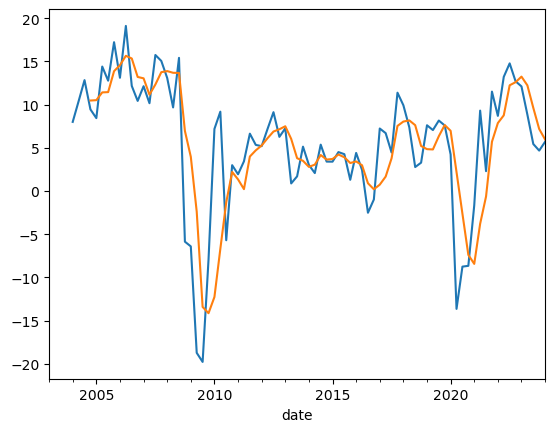

In [23]:
Ar['GDP_real_growth_1.0y'].plot()
Ar_avg['GDP_real_growth_avg_1.0y'].plot()
plt.show()

In [24]:
# generating inferred column
# updating MP
mp_update_values = {
    '2022Q1': 2,
    '2022Q2': 1,
    '2022Q3': 0,
    '2022Q4': 0,
    '2023Q1': 2,
    '2023Q2': 0,
    '2023Q3': 1,
    '2023Q4': 0,
    '2024Q1': 0,
}
mp_update = pd.Series(mp_update_values)
mp_update.index = pd.PeriodIndex(mp_update.index, freq='Q').to_timestamp('Q')
arm_data.loc[mp_update.index, 'MP'] = mp_update.values

# calculate MPI
arm_data['MPI'] = arm_data['MP'].rolling(window=4, min_periods=1).sum()

In [25]:
X_raw = arm_data.iloc[:, 1:].copy()

# grouping columns based on origin
original_columns = list(X_raw.columns)
generated_sample = feature_engineering_pipeline.fit_transform(X_raw[[original_columns[0]]]).columns
col_lookup = re.compile(f"{original_columns[0]}", re.IGNORECASE)
generated_suffixes = [col_lookup.sub('', s) for s in generated_sample]
column_group_mapping = {c+s: c for s in generated_suffixes for c in original_columns}
column_groups = {c: [c+s for s in generated_suffixes] for c in original_columns}

# performing transformations
X_T = feature_engineering_pipeline.fit_transform(X_raw)

In [26]:
print(X_raw.columns)

Index(['Financial Cycle Index', 'Short-term GB rate', 'Mid-term GB rate',
       'Long-term GB rate', 'Level', 'Steepness', 'Curvature', 'CPI',
       'Policy rate', 'Bank RoE', 'Liquidity ratio (HLA/Assets)', 'CAR',
       'Mortgage stock', 'Mortgage flow', 'Mortgage interest rate',
       'Construction loans', 'Real estate prices', 'Exchange rate',
       'Trade balance', 'Copper prices', 'Credit GDP ratio', 'Credit GDP gap',
       'DSTI', 'MP', 'MPI'],
      dtype='object')


,GDP_real_growth_1.0y,GDP_real_growth_hz_1.0y,GDP_real_growth_hz_2.0y,GDP_real_growth_hz_3.0y
MPI_log_PctC_1y,0.055275,0.601378,0.406892,0.346076
MPI_lag_1_log_PctC_1y,0.215436,0.517051,0.343716,0.264535
MPI_lag_1_PctC_3y,0.487590,0.018496,0.232776,0.467159
MPI_PctC_2y,0.167254,0.460147,0.351118,0.144963
MPI_lag_4_log_PctC_2y,0.485448,0.097384,0.176422,0.322698
MPI_lag_3_PctC_3y,0.395195,0.092855,0.368740,0.220546
MPI_lag_1_PctC_2y,0.245560,0.362603,0.273844,0.162612
MPI_lag_2_log_PctC_1y,0.306213,0.359607,0.255808,0.118614
MPI_lag_4_log_PctC_1y,0.601564,0.049674,0.062011,0.313763
MPI_lag_2_PctC_2y,0.348035,0.309140,0.198758,0.170249


GDP_real_growth_1.0y       0.096024
GDP_real_growth_hz_1.0y    0.170740
GDP_real_growth_hz_2.0y    0.086647
GDP_real_growth_hz_3.0y    0.225735
Name: MPI, dtype: float64

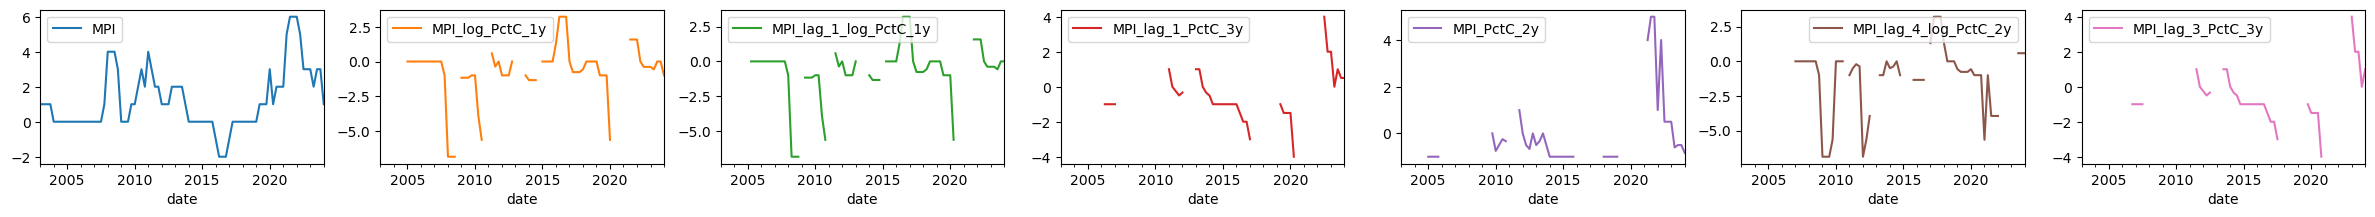

In [27]:
index = 24
v_name = list(column_groups.keys())[index]
corr = pd.concat([Ar.iloc[:, 0], Y, X_T[list(column_groups.values())[index]]], axis=1)
corr = corr.corr().abs().iloc[4:, :4]
corr_best = corr.reindex(corr.mean(axis=1).sort_values(ascending=False).index).head(50)
display(corr_best)
display(corr.loc[v_name])
X_T[[v_name] + list(corr_best.index[:6])].plot(subplots=True, layout=(1, 7), figsize=(30, 2))
plt.show()

In [28]:
consistent_columns = [
    'Financial Cycle Index', 'Short-term GB rate_lag_2_log_C_1y',
    'Mid-term GB rate_C_1y', 'Long-term GB rate_C_2y',
    'Level_lag_1_C_2y', 'Steepness_PctC_2y', 'Curvature_C_1y',
    'CPI', 'Policy rate', 'Bank RoE', 'Liquidity ratio (HLA/Assets)',
    'CAR_C_2y', 'Mortgage stock_PctC_2y', 'Mortgage flow_PctC_2y',
    'Mortgage interest rate_lag_1', 'Construction loans_PctC_2y',
    'Real estate prices_lag_1_log', 'Exchange rate_lag_4',
    'Trade balance', 'Copper prices_lag_4_log', 'Credit GDP ratio_PctC_3y',
    'Credit GDP gap', 'DSTI_PctC_3y', 'MPI'
]
X_selected = X_T[consistent_columns].copy()

# using base names for selected columns
X_selected = X_selected.rename(columns=column_group_mapping)

# Financial Conditions Index (FCI)

In [29]:
# exog
exog_cols_fci_a = [
    'Steepness',
    'Curvature',
    'Bank RoE',
    # 'Short-term GB rate',
    # 'Mid-term GB rate',
    # 'Long-term GB rate',
    # 'Mortgage interest rate',
    # 'Level',
]
exog_cols_fci_b = [
    'Bank RoE',
    'Steepness',
    'Level',
    # 'Short-term GB rate',
    # 'Mid-term GB rate',
    # 'Long-term GB rate',
    # 'Mortgage interest rate',
    # 'Curvature',
]
X_fci = X_selected[exog_cols_fci_a].copy()

# endog
endog_cols = ['CPI', 'Policy rate']
Y_fci = pd.concat([Ar.loc[:, 'GDP_real_growth_1.0y'], X_selected[endog_cols]], axis=1).copy()

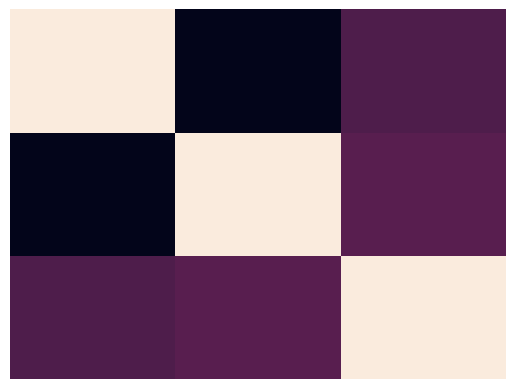

In [30]:
# clustering the X_fci columns
sil_scores = get_silhouette_scores(X_fci.corr().abs(), n_init=10)
best_k = max(sil_scores, key=sil_scores.get)
best_k = 3
kmeans = KMeans(n_clusters=best_k, n_init=10)
labels = kmeans.fit_predict(X_fci.corr().abs())
X_fci_col_order = np.argsort(labels)
X_fci_cm = {label: [X_fci.columns[i] for i, l in enumerate(labels) if l == label] for label in set(labels)}
sns.heatmap(X_fci.corr().abs().iloc[X_fci_col_order, X_fci_col_order], cbar=False, yticklabels=False, xticklabels=False)
plt.show()

In [31]:
display(X_fci_cm)

{0: ['Bank RoE'], 1: ['Curvature'], 2: ['Steepness']}

In [32]:
# standardize data
ss = StandardScalerDF()
X_fci_st = ss.fit_transform(X_fci)
Y_fci_st = ss.fit_transform(Y_fci)

# fillna with 0
X_fci_st = X_fci_st.fillna(0)
Y_fci_st = Y_fci_st.fillna(0)

# standardize again for some reason
X_fci_st = ss.fit_transform(X_fci_st)
Y_fci_st = ss.fit_transform(Y_fci_st)

FCI using PCA

In [33]:
pca_model = PCA(n_components=1, svd_solver='full', tol=0,
                iterated_power='auto', n_oversamples=10,
                power_iteration_normalizer='auto',
                random_state=42)
pca_model.fit(X_fci_st)
n = X_fci_st.shape[1]
pca_loadings = - pca_model.components_.T * np.sqrt(n)
fci_pca = (X_fci_st @ (pca_loadings / n)).squeeze().rename('fci_pca')
print('Explained Variance:', pca_model.explained_variance_ratio_[0].round(4))
print('Singular values:', pca_model.singular_values_[0].round(4))

Explained Variance: 0.4821
Singular values: 11.0225


FCI using the method by Doz, Giannone and Reichlin (2011)

In [34]:
t = Y_fci_st.shape[0]
YF = pd.concat([Y_fci_st, fci_pca], axis=1)
YX = pd.concat([Y_fci_st, X_fci_st], axis=1)
t, nvars = YX.shape
nlags = 4
nstates = YF.shape[1]
n_undefined_rows = nstates*(nlags-1)
nstates_doz = nstates*nlags

In [35]:
# measurement model
measurement_model = sm.OLS(YX, YF).fit()
L = np.array(measurement_model.params)
e = measurement_model.resid
measurement_sigma = np.diag(np.diag((e.T @ e) / t))
R = measurement_sigma + 1e-10*np.eye(nvars)
# sigma2 = np.diag((e**2).sum() / t)

# state model
lf = LagFeatures(periods=list(range(1, nlags+1)), drop_original=True)
yf_lags = lf.fit_transform(YF).dropna()
yf_lags_cov_inv = np.linalg.inv(yf_lags.T @ yf_lags)
yf = YF.loc[yf_lags.index].copy()
t = yf.shape[0]
state_model = sm.OLS(yf, yf_lags).fit()
T = np.array(state_model.params)
e = state_model.resid
sigmaf = (e.T @ e) / (t-1)
state_beta_var = np.kron(sigmaf, yf_lags_cov_inv)
bb = T.reshape(nstates, nlags, nstates).transpose(0, 2, 1).reshape(-1)

# state model as VAR
ar_identity = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
T_doz = np.concatenate((T.T, ar_identity), axis=0)
Q_doz = np.concatenate((sigmaf, np.zeros((nstates, n_undefined_rows))), axis=1)
Q_doz = np.concatenate((Q_doz, np.zeros((n_undefined_rows, nstates_doz))), axis=0)

# drawing states from Kalman filter (smoothing)
S0 = np.zeros(nstates_doz)
P0 = 10*np.eye(nstates_doz)
S_draws = kalman_companion(YX, S0, P0, L, R, T_doz, Q_doz)
S_draws = pd.DataFrame(S_draws, index=YF.index, columns=YF.columns).rename(columns={'fci_pca': 'fci_doz'})
fci_doz = S_draws['fci_doz']

FCI using the method by Koop and Korobilis (2013)

In [36]:
# step 1: Update Parameters Conditional on PC
# the  decays include:
# 1) decay factor for measurement error variance
# 2) decay factor for factor error variance
# 3) decay factor for loadings error variance
# 4) decay factor for VAR coefficients error variance
decays = np.array([0.96, 0.96, 0.99, 0.99])
nfactors = 1
nlags = 4
nstates = YF.shape[1]
nmacro = nstates - nfactors
t, nvars = YX.shape
nstates_all = nstates*nlags
nVAR = nlags*(nstates**2)  # number of VAR parameters

# Priors
priors = {}

# initial condition on the factors
priors['factor_0_mean'] = np.zeros(nstates_all)
priors['factor_0_var'] = 10*np.eye(nstates_all)

# initial condition on lambda_t
priors['lambda_0_mean'] = np.zeros((nvars, nstates))
priors['lambda_0_var'] = 1*np.eye(nstates)

# initial condition on beta_t
gamma = 0.1
b_prior, Vb_prior = Minn_prior_KOOP(gamma, nstates, nlags, nVAR)  # Obtain a Minnesota-type prior
priors['beta_0_mean'] = b_prior
priors['beta_0_var'] = Vb_prior

# initial condition on the covariance matrices
priors['V_0'] = 0.1*np.eye(nvars)
priors['V_0'][:nmacro, :nmacro] = 0
priors['Q_0'] = 0.1*np.eye(nstates)

In [37]:
tvp_favar_korobilis = TVP_FAVAR(YX, YF, nlags, nfactors)
beta_t, beta_new, lambda_t, V_t, Q_t = tvp_favar_korobilis.fit(decays, priors)
factor_new, Sf_t_new = tvp_favar_korobilis.gen_factors(priors)
S_knk = pd.DataFrame(factor_new, index=YF.index, columns=YF.columns).rename(columns={'fci_pca': 'fci_knk'})
fci_knk = S_knk['fci_knk'].copy()

In [38]:
exog_cols_fci_a

['Steepness', 'Curvature', 'Bank RoE']

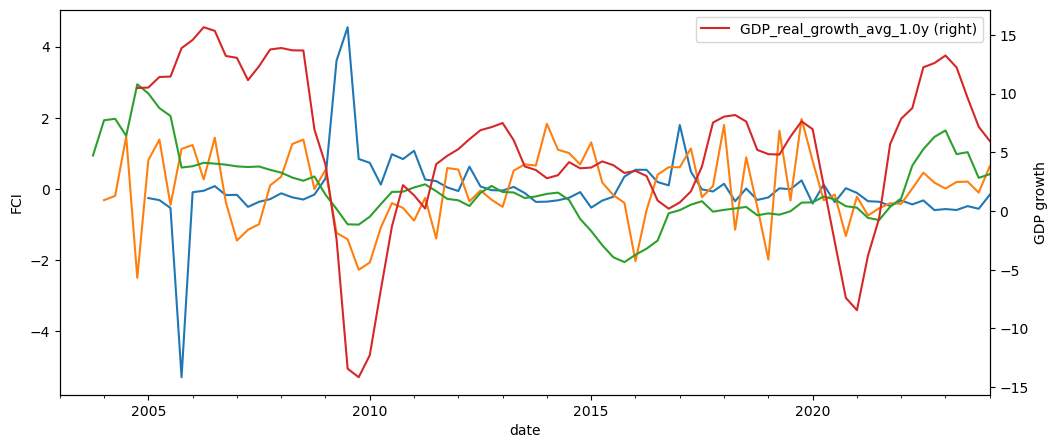

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
ss.fit_transform(X_selected['Steepness']).plot(ax=ax)
ss.fit_transform(X_selected['Curvature']).plot(ax=ax)
ss.fit_transform(X_selected['Bank RoE']).plot(ax=ax)
plt.ylabel("FCI")
Ar_avg['GDP_real_growth_avg_1.0y'].plot(secondary_y=True, ax=ax)
plt.ylabel("GDP growth")
plt.legend()
plt.show()

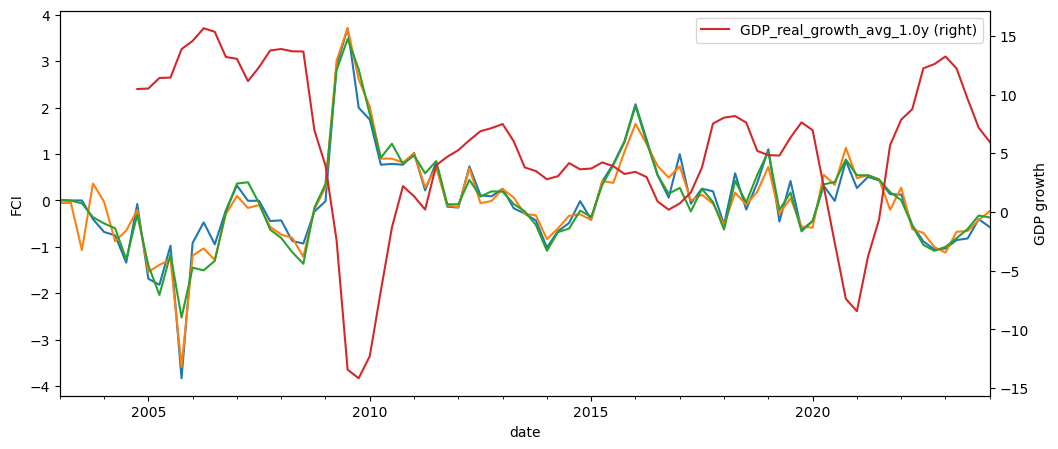

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
ss.fit_transform(fci_pca).plot(ax=ax)
ss.fit_transform(fci_doz).plot(ax=ax)
ss.fit_transform(fci_knk).plot(ax=ax)
plt.ylabel("FCI")
Ar_avg['GDP_real_growth_avg_1.0y'].plot(secondary_y=True, ax=ax)
plt.ylabel("GDP growth")
plt.legend()
plt.savefig('../results/FCI-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

In [41]:
endog_fci_test = Ar['GDP_real_growth_1.0y']
ar = endog_fci_test.shift(4)
exog_fci_test = sm.add_constant(pd.concat([ar, fci_knk], axis=1).dropna())
endog_fci_test = endog_fci_test.loc[exog_fci_test.index]
qr_tail = sm.QuantReg(endog_fci_test, exog_fci_test).fit(q=0.1, max_iter=1000)
print('Psudo-rsquared:', qr_tail.prsquared)

Psudo-rsquared: 0.39511623925737205


In [42]:
X_raw['Financial Conditions Index'] = fci_knk
X_selected['Financial Conditions Index'] = fci_knk

# make sure to add FCI to the search space
column_group_mapping['Financial Conditions Index'] = 'Financial Conditions Index'
column_groups['Financial Conditions Index'] = ['Financial Conditions Index']

# Dataset overview

In [43]:
col_order = [
    'Financial Cycle Index', 'Financial Conditions Index',
    'Policy rate', 'MPI', 'CAR', 'Bank RoE',
    'Liquidity ratio (HLA/Assets)', 'Level', 'Steepness', 'Curvature',
    'CPI', 'Exchange rate',
    'Trade balance', 'Copper prices',
    'Mortgage stock', 'Mortgage flow', 'Mortgage interest rate',
    'Construction loans', 'Real estate prices',
]
# reorder and drop columns from FCI
arm_dataset = X_selected[col_order].copy()
arm_dataset = arm_dataset.drop(columns=exog_cols_fci_a)
arm_dataset = pd.concat([Ar.loc[:, 'GDP_real_growth_1.0y'], arm_dataset], axis=1)

In [44]:
display(arm_dataset.describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
GDP_real_growth_1.0y,81.0,5.5,7.4,-19.8,3.0,6.7,10.2,19.1
Financial Cycle Index,85.0,0.1,0.1,0.0,0.1,0.1,0.2,0.3
Financial Conditions Index,85.0,-0.0,0.6,-1.5,-0.4,-0.1,0.2,2.0
Policy rate,85.0,0.1,0.0,0.0,0.1,0.1,0.1,0.1
MPI,85.0,1.2,1.7,-2.0,0.0,1.0,2.0,6.0
CAR,77.0,-0.0,0.1,-0.1,-0.0,-0.0,0.0,0.2
Liquidity ratio (HLA/Assets),85.0,0.3,0.1,0.2,0.3,0.3,0.4,0.5
Level,76.0,0.0,0.0,-0.1,-0.0,0.0,0.0,0.1
CPI,85.0,111.4,25.4,68.9,88.8,116.7,127.8,158.7
Exchange rate,81.0,440.3,69.2,302.3,384.4,452.3,483.4,586.6


In [45]:
corr = arm_dataset.corr()
corr_target = corr.iloc[0]
corr_target = corr_target.loc[corr_target.abs().sort_values(ascending=False).index]
display(corr_target)

GDP_real_growth_1.0y            1.000000
Financial Conditions Index     -0.688985
Mortgage flow                   0.500424
Trade balance                   0.436035
Liquidity ratio (HLA/Assets)    0.409836
Exchange rate                   0.368335
Level                          -0.305151
Mortgage interest rate         -0.289934
Real estate prices             -0.268372
CAR                             0.244021
Copper prices                  -0.222385
Mortgage stock                  0.212019
CPI                            -0.137253
Construction loans             -0.115326
MPI                             0.096024
Policy rate                    -0.085318
Financial Cycle Index           0.060596
Name: GDP_real_growth_1.0y, dtype: float64

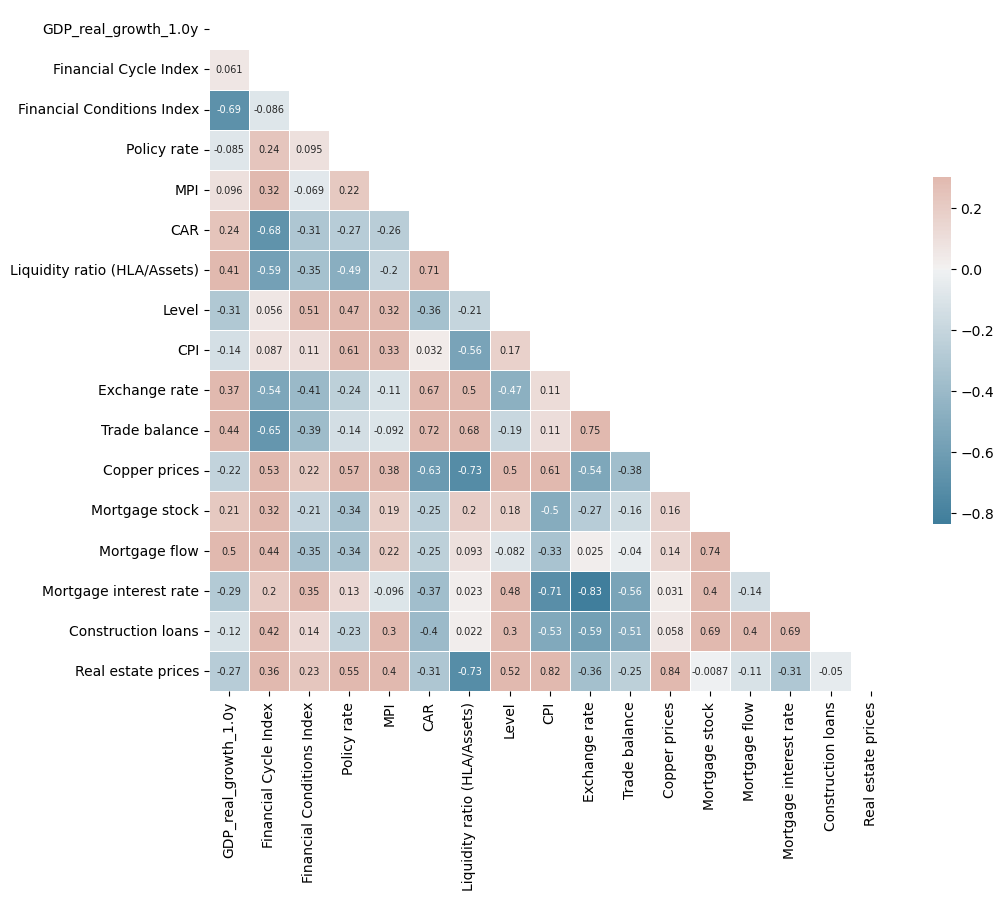

In [46]:
# Compute the correlation matrix
corr = arm_dataset.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot_kws={"fontsize": 7})
plt.show()

In [47]:
arm_overview_today = pd.concat([Ar, arm_dataset.iloc[:, 1:]], axis=1)
corr = arm_overview_today.corr()
corr_target = corr.loc['GDP_real_growth_1.0y']
corr_target = corr_target.loc[corr_target.abs().sort_values(ascending=False).index]
display(corr_target)

GDP_real_growth_1.0y            1.000000
GDP_real_growth_2.0y            0.748520
Financial Conditions Index     -0.688985
GDP_real_growth_3.0y            0.545873
Mortgage flow                   0.500424
Trade balance                   0.436035
Liquidity ratio (HLA/Assets)    0.409836
Exchange rate                   0.368335
Level                          -0.305151
Mortgage interest rate         -0.289934
Real estate prices             -0.268372
CAR                             0.244021
Copper prices                  -0.222385
Mortgage stock                  0.212019
CPI                            -0.137253
Construction loans             -0.115326
MPI                             0.096024
Policy rate                    -0.085318
Financial Cycle Index           0.060596
Name: GDP_real_growth_1.0y, dtype: float64

In [48]:
arm_overview_tomorrow = pd.concat([Y, arm_dataset.iloc[:, 1:]], axis=1)
corr = arm_overview_tomorrow.corr()
corr_target = corr.loc['GDP_real_growth_hz_1.0y']
corr_target = corr_target.loc[corr_target.abs().sort_values(ascending=False).index]
display(corr_target)

GDP_real_growth_hz_1.0y         1.000000
GDP_real_growth_hz_2.0y         0.737088
Financial Cycle Index          -0.574826
GDP_real_growth_hz_3.0y         0.549693
Trade balance                   0.544856
Liquidity ratio (HLA/Assets)    0.540150
Exchange rate                   0.474464
CAR                             0.447789
Copper prices                  -0.408310
Real estate prices             -0.405993
Mortgage interest rate         -0.398050
Construction loans             -0.372436
Mortgage stock                 -0.282768
Policy rate                    -0.270011
Level                          -0.252373
Mortgage flow                  -0.247511
MPI                            -0.170740
CPI                            -0.159530
Financial Conditions Index     -0.073764
Name: GDP_real_growth_hz_1.0y, dtype: float64

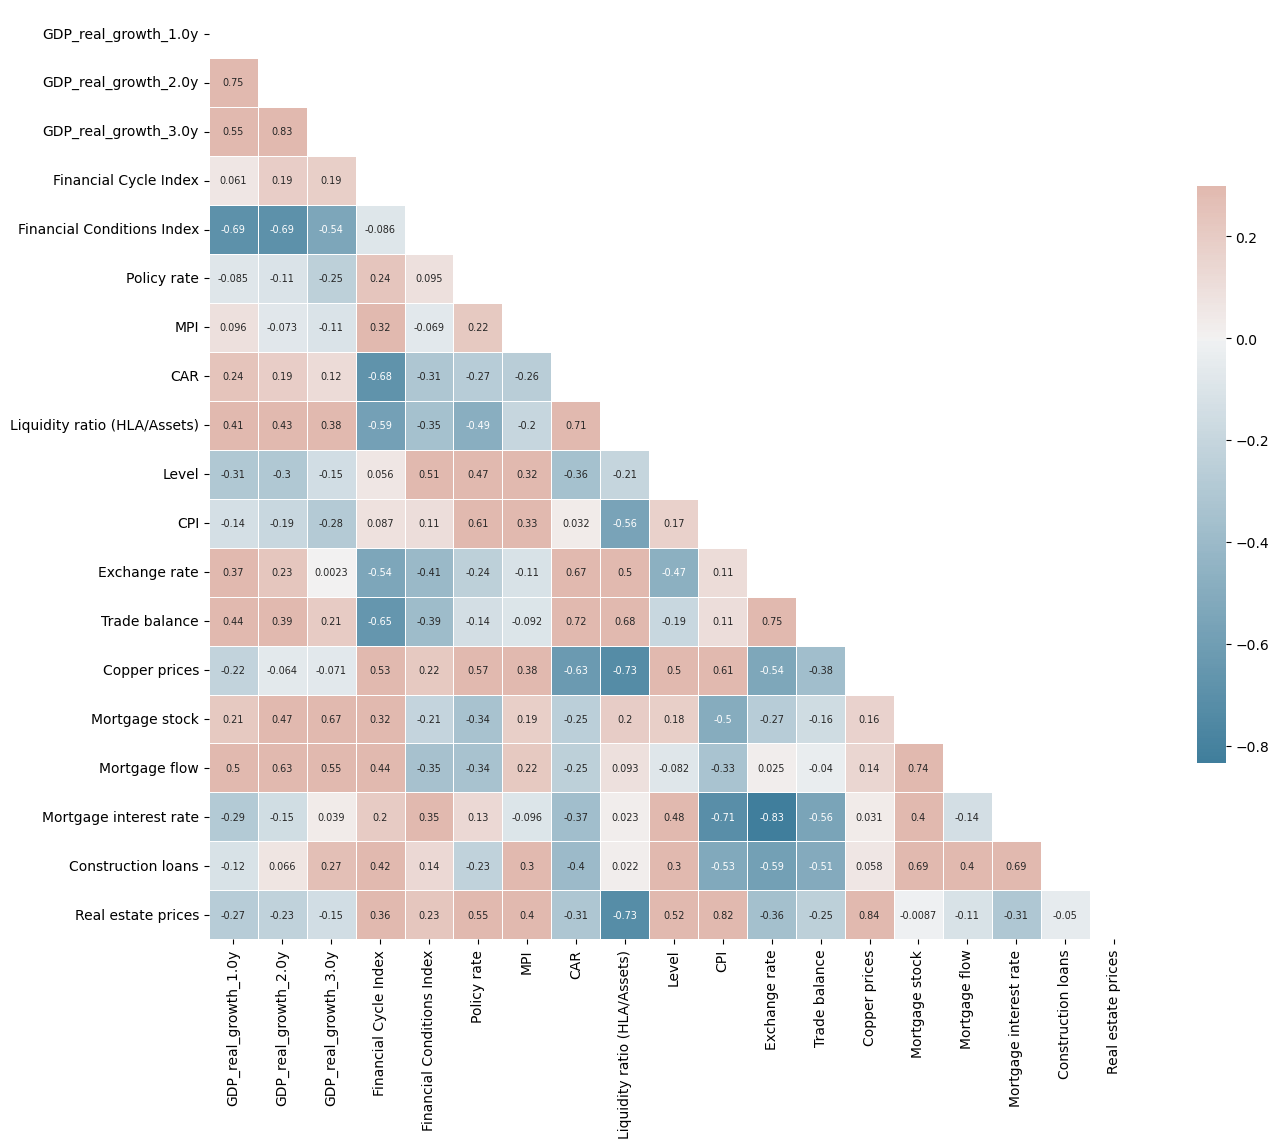

In [49]:
# Compute the correlation matrix
corr = arm_overview_today.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot_kws={"fontsize": 7})
plt.show()

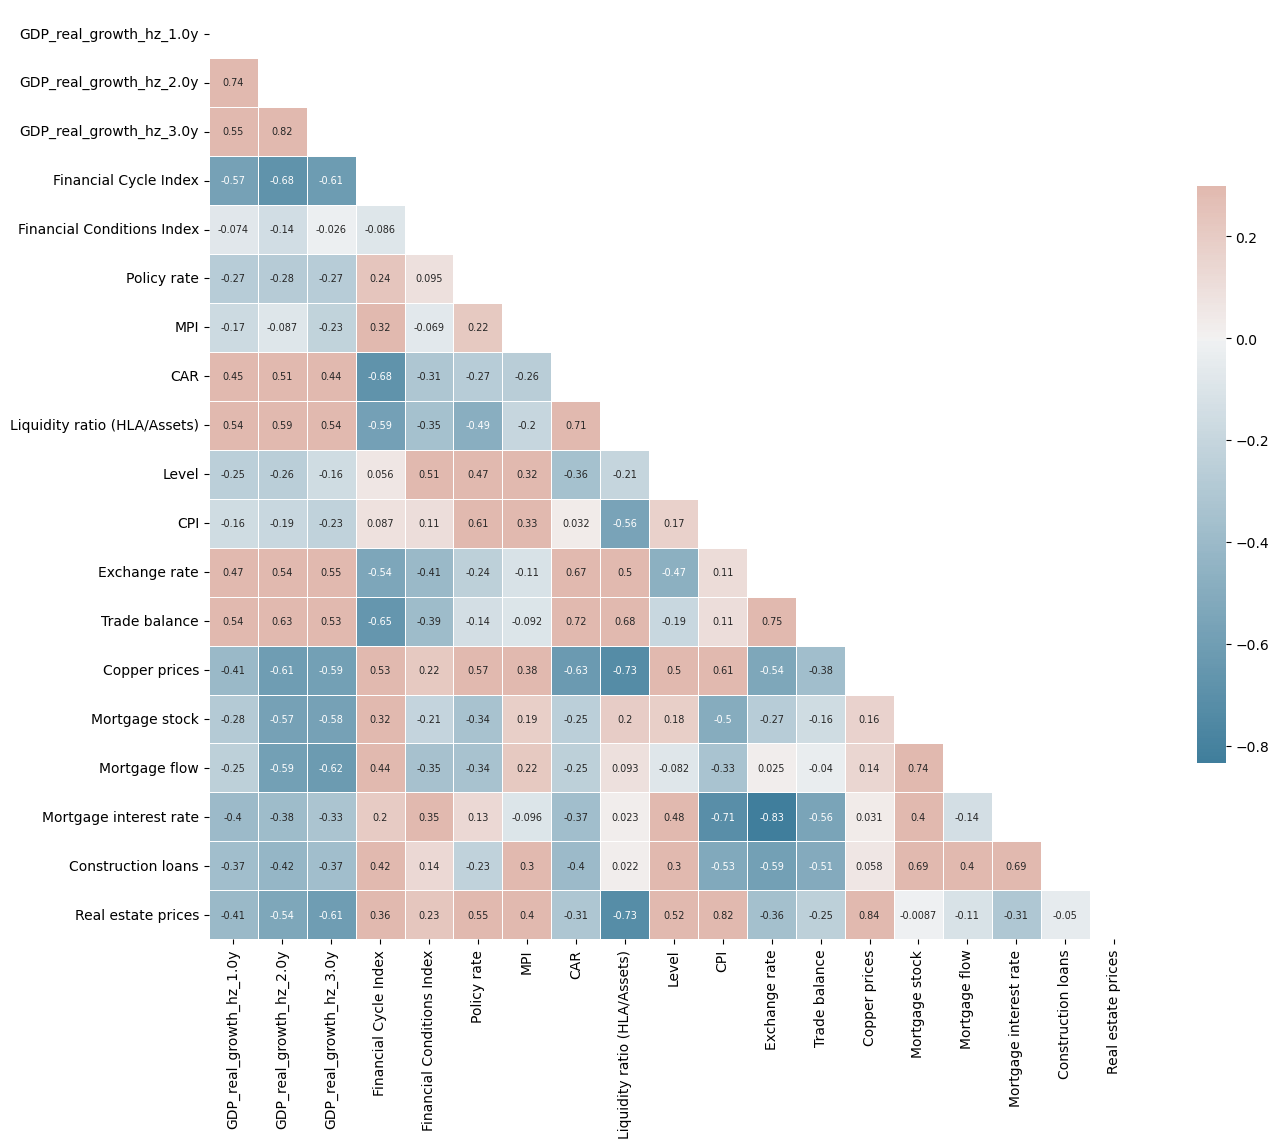

In [50]:
# Compute the correlation matrix
corr = arm_overview_tomorrow.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot_kws={"fontsize": 7})
plt.show()

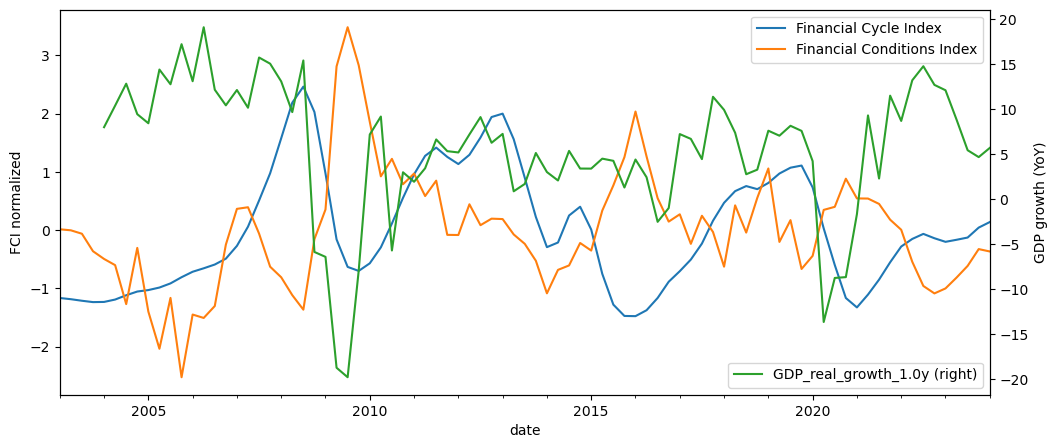

In [51]:
fcyi_s = ss.fit_transform(arm_dataset['Financial Cycle Index'])
fci_s = ss.fit_transform(arm_dataset['Financial Conditions Index'])
growth = arm_dataset['GDP_real_growth_1.0y']

fig, ax = plt.subplots(figsize=(12, 5))
ax = fcyi_s.plot(ax=ax)
ax = fci_s.plot(ax=ax)
plt.ylabel('FCI normalized')
plt.legend()
ax = growth.plot(ax=ax, secondary_y=True)
plt.legend(loc='lower right')
plt.ylabel('GDP growth (YoY)')
plt.savefig('../results/FCyI-FCI-GDP-YoY-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

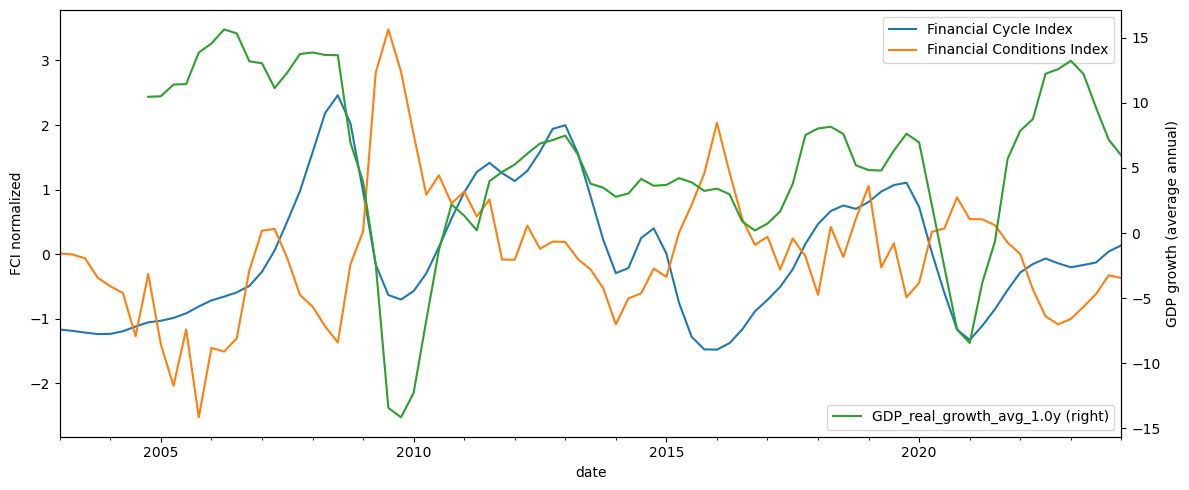

In [52]:
growth = Ar_avg['GDP_real_growth_avg_1.0y']

fig, ax = plt.subplots(figsize=(12, 5))
ax = fcyi_s.plot(ax=ax)
ax = fci_s.plot(ax=ax)
plt.ylabel('FCI normalized')
ax.legend()
ax = growth.plot(ax=ax, secondary_y=True)
plt.legend(loc='lower right')
plt.ylabel('GDP growth (average annual)')
plt.tight_layout()
plt.savefig('../results/FCyI-FCI-GDP-AA-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

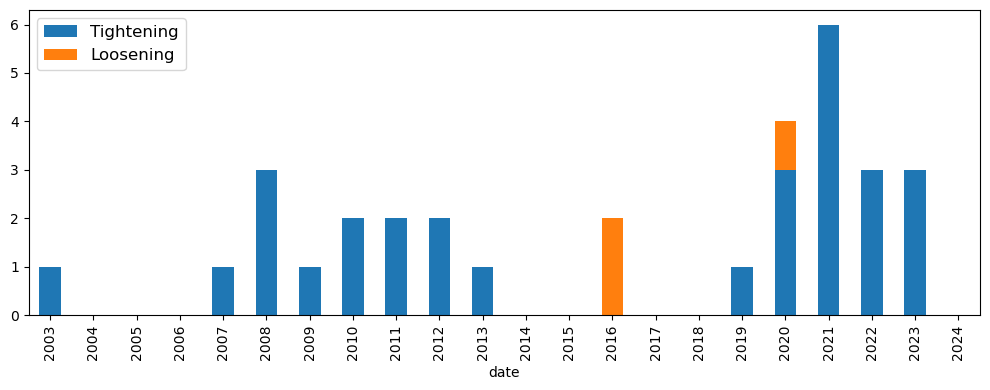

In [53]:
# arm_dataset['MPI'].plot()
# growth.plot(secondary_y=True)
# plt.show()

mp_tightening = X_raw['MP'].apply(lambda x: max(x, 0)).groupby('date').sum()
mp_loosening = X_raw['MP'].apply(lambda x: min(x, 0)).groupby('date').sum().abs()
mp_actions = pd.DataFrame({'Tightening': mp_tightening, 'Loosening': mp_loosening})
mp_actions = mp_actions.groupby(mp_actions.index.year).sum()
# mp_actions.columns.name = 'Action'
# mp_actions = mp_actions.stack().reset_index(name='count').set_index('date')
ax = mp_actions.plot(kind='bar', stacked=True, figsize=(10, 4))
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../results/MPI-actions-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

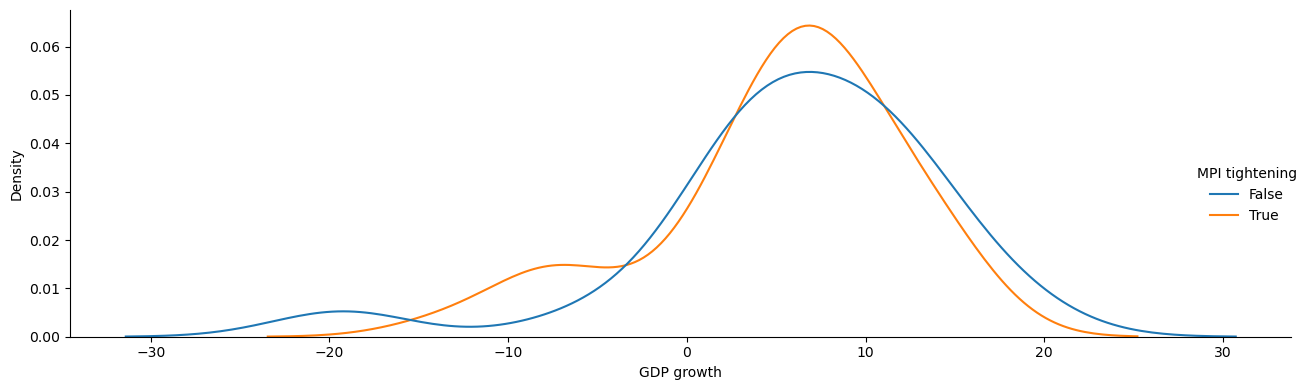

In [54]:
arm_overview = arm_dataset.copy()
mpi_tightening = arm_overview['MPI'].clip(lower=0)
mpi_loosening = arm_overview['MPI'].clip(upper=0)
fci_growth = (arm_overview['Financial Cycle Index']*(arm_overview['Financial Cycle Index'].diff().clip(lower=0) != 0))
fci_recession = (arm_overview['Financial Cycle Index']*(arm_overview['Financial Cycle Index'].diff().clip(upper=0) != 0))

arm_overview['MPI tightening'] = mpi_tightening > 0
arm_overview['MPI loosening'] = mpi_loosening < 0

ax = sns.displot(arm_overview,
                 x="GDP_real_growth_1.0y",
                 # col="period",
                 hue="MPI tightening",
                 kind="kde",
                 height=4,
                 aspect=3,
                 common_norm=False,
                 facet_kws={'sharey': False})
ax.set(xlabel='GDP growth')
plt.tight_layout()
plt.savefig('../results/MPI-tightening-GDP-dist-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

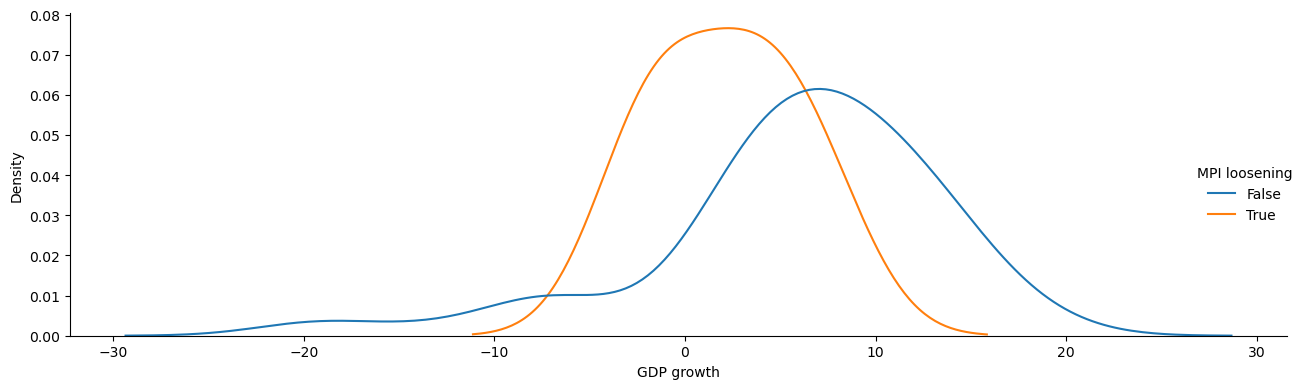

In [55]:
ax = sns.displot(arm_overview,
                 x="GDP_real_growth_1.0y",
                 # col="period",
                 hue="MPI loosening",
                 kind="kde",
                 height=4,
                 aspect=3,
                 common_norm=False,
                 facet_kws={'sharey': False})
ax.set(xlabel='GDP growth')
plt.tight_layout()
plt.savefig('../results/MPI-loosening-GDP-dist-Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

In [56]:
# saving results
X_selected.to_pickle('../data/working_data/arm_X_selected.pkl')
Y.to_pickle('../data/working_data/arm_Y.pkl')
Ar.to_pickle('../data/working_data/arm_Ar.pkl')
Arr.to_pickle('../data/working_data/arm_Arr.pkl')

# Modeling

In [20]:
# loading data
X_selected = pd.read_pickle('../data/working_data/arm_X_selected.pkl')
Y = pd.read_pickle('../data/working_data/arm_Y.pkl')
Ar = pd.read_pickle('../data/working_data/arm_Ar.pkl')
Arr = pd.read_pickle('../data/working_data/arm_Arr.pkl')

In [28]:
# setup
sns.reset_defaults()
ss = StandardScalerDF()
horizons = list(range(4, 12+1, 4))
quantlist = np.arange(0.05, 0.95, 0.05).round(2)

model_select_cols = [
    'const',
    'Financial Cycle Index', 'Financial Conditions Index',
    'MPI',
    # 'CAR',
    'FCI x FCyI', 'MPI x FCyI', 'MPI x FCI',
    # 'DSTI',
    # 'Mortgage flow'
    # 'Mortgage stock',
    # 'Mortgage interest rate',
    # 'Construction loans',
    # 'Real estate prices',
    # 'Real house price',
    # 'Bank RoE',
    # 'Level',
    # 'Steepness',
    # 'Curvature',
    # 'Credit GDP ratio', 'Credit GDP gap',
    # 'Short-term GB rate',
    # 'Mid-term GB rate',
    # 'Long-term GB rate',
    # 'Liquidity ratio (HLA/Assets)',
    'CPI',
    # 'Policy rate',
    'Exchange rate',
    'Trade balance',
    'Copper prices',
]
# actual column names
# 'Financial Cycle Index'
# 'CAR_C_2y'

# 'Financial Conditions Index':
# 'Steepness_PctC_2y'
# 'Curvature_C_1y'
# 'Bank RoE'

# 'Mortgage stock_PctC_2y'
# 'Mortgage flow_PctC_2y'
# 'DSTI_PctC_3y'
# 'Mortgage interest rate_lag_1'
# 'Construction loans_PctC_2y'

# 'MPI'
# 'CPI'
# 'Policy rate'
# 'Exchange rate_lag_4'
# 'Trade balance'
# 'Copper prices_lag_4_log'
# 'Real estate prices_lag_1_log'
# 'Liquidity ratio (HLA/Assets)'

# usable:
# Short-term GB rate
# DSTI
# Mortgage flow

In [22]:
# exog setup
exog = X_selected.copy()
exog = add_trend(exog, trend='c')

# adding interaction effects
exog_mpi = exog['MPI'].copy()
exog_fci = ss.fit_transform(exog['Financial Conditions Index'])
exog_fcyi = ss.fit_transform(exog['Financial Cycle Index'])
exog['FCI x FCyI'] = exog_fci * exog_fcyi
exog['MPI x FCyI'] = exog_mpi * exog_fcyi
exog['MPI x FCI'] = exog_mpi * exog_fci

# adding real house prices using CPI
exog['Real house price'] = exog['Real estate prices'] - np.log(exog['CPI'])
exog = exog[model_select_cols]

In [23]:
# setup dataset
macro_dataset = []
horizon_namer = re.compile(r'_([\d\.]+)y')

# for forward expectations
for index, y_name in enumerate(Y):
    horizon_years = horizon_namer.search(y_name).group(1)
    horizon = float(horizon_years) * 4
    endog = Y[y_name].copy()
    ar = Ar.iloc[:, index].copy()
    endog_new_name = horizon_namer.sub('', ar.name)
    macro_data = pd.concat([ar.rename('autoregressive'), exog], axis=1)
    macro_data = pd.concat([endog.rename(endog_new_name), macro_data], axis=1)
    macro_data['horizon'] = horizon
    macro_data['expectation'] = 'forward'

    # remove extra rows
    cutoff_date = macro_data.isna().groupby('date').sum().sum(axis=1).idxmin()
    macro_data = macro_data[macro_data.index.get_level_values('date') >= cutoff_date].copy()

    # add to the dataset
    macro_dataset.append(macro_data)

# for backward expectations
for index, y_name in enumerate(Y):
    horizon_years = horizon_namer.search(y_name).group(1)
    horizon = float(horizon_years) * 4
    endog = Ar.iloc[:, index].copy()
    ar = Arr.iloc[:, index].copy()
    endog_new_name = horizon_namer.sub('', ar.name)
    macro_data = pd.concat([ar.rename('autoregressive'), exog], axis=1)
    macro_data = pd.concat([endog.rename(endog_new_name), macro_data], axis=1)
    macro_data['horizon'] = horizon
    macro_data['expectation'] = 'backward'

    # remove extra rows
    cutoff_date = macro_data.isna().groupby('date').sum().sum(axis=1).idxmin()
    macro_data = macro_data[macro_data.index.get_level_values('date') >= cutoff_date].copy()

    # add to the dataset
    macro_dataset.append(macro_data)
macro_dataset = pd.concat(macro_dataset).reset_index().set_index(['expectation', 'horizon', 'date']).sort_index()

In [24]:
# fitting QR the model
arm_qcoef = []
arm_qcoef_norm = []
arm_qr_pred = []

dims = ['expectation', 'horizon']
for (exp, horizon), macro_data in macro_dataset.groupby(dims):
    target = macro_data.columns[0]
    macro_data = macro_data.reset_index(dims, drop=True).reset_index()
    quantfit_out = run_quantfit(macro_data, target=target, horizon=horizon,
                                model_fit_args={'max_iter': 100_000, 'p_tol': 1e-06},
                                model=sm.QuantReg, quantlist=quantlist)
    quantfit_out['localprj']['expectation'] = exp
    quantfit_out['qcoef']['expectation'] = exp
    quantfit_out['cond_quant']['expectation'] = exp
    arm_qcoef.append(quantfit_out['localprj'])
    arm_qcoef_norm.append(quantfit_out['qcoef'])
    arm_qr_pred.append(quantfit_out['cond_quant'])
arm_qcoef = pd.concat(arm_qcoef).set_index(['expectation', 'horizon', 'variable', 'quantile'])
arm_qcoef_norm = pd.concat(arm_qcoef_norm).set_index(['expectation', 'horizon', 'variable', 'quantile'])
arm_qr_pred = pd.concat(arm_qr_pred).reset_index().set_index(['expectation', 'horizon', 'tau', 'date'])

In [25]:
warns = arm_qcoef[arm_qcoef['warning'].notna()]
warns = warns['warning'].groupby(['expectation', 'horizon', 'quantile']).first()
print('warning count:', warns.shape[0])
display(warns.reset_index())

warning count: 1


,expectation,horizon,quantile,warning
0,backward,4.0,0.05,{message : IterationLimitWarning('Maximum numb...


In [26]:
# model comparison
benchmark_model_btail = arm_qcoef.loc[('backward', 4.0, 'MPI', 0.1), 'Model']
benchmark_model_ftail = arm_qcoef.loc[('forward', 4.0, 'MPI', 0.1), 'Model']
benchmark_model_bmedian = arm_qcoef.loc[('backward', 4.0, 'MPI', 0.5), 'Model']
benchmark_model_fmedian = arm_qcoef.loc[('forward', 4.0, 'MPI', 0.5), 'Model']
main_models = {
    'GDP growth, h=4, q=0.1, e=b': benchmark_model_btail,
    'GDP growth, h=4, q=0.1, e=f': benchmark_model_ftail,
    'GDP growth, h=4, q=0.5, e=b': benchmark_model_bmedian,
    'GDP growth, h=4, q=0.5, e=f': benchmark_model_fmedian
}
info_dict = {"N": lambda x: x.nobs, 'Pseudo-R2': lambda x: x.prsquared}

model_res = summary_col(list(main_models.values()),
                        model_names=list(main_models.keys()),
                        stars=True,
                        info_dict=info_dict,
                        include_r2=False)
display(model_res)

,"GDP growth, h=4, q=0.1, e=b","GDP growth, h=4, q=0.1, e=f","GDP growth, h=4, q=0.5, e=b","GDP growth, h=4, q=0.5, e=f"
autoregressive,-0.3604*,0.0787,-0.4502***,-0.0135
,(0.1855),(0.2428),(0.0991),(0.1148)
const,26.4445**,6.9471,20.4807**,8.7444
,(11.8196),(19.7645),(8.0409),(10.4935)
Financial Cycle Index,82.1152***,-34.4992,56.0408***,-1.2532
,(18.8063),(36.3506),(15.6975),(16.8060)
Financial Conditions Index,-6.8776**,4.2589,-5.0864***,2.9263*
,(2.6319),(2.8803),(1.5893),(1.6792)
MPI,-0.7121,1.7059**,-0.2551,-0.0966
,(0.6104),(0.6808),(0.3761),(0.3653)


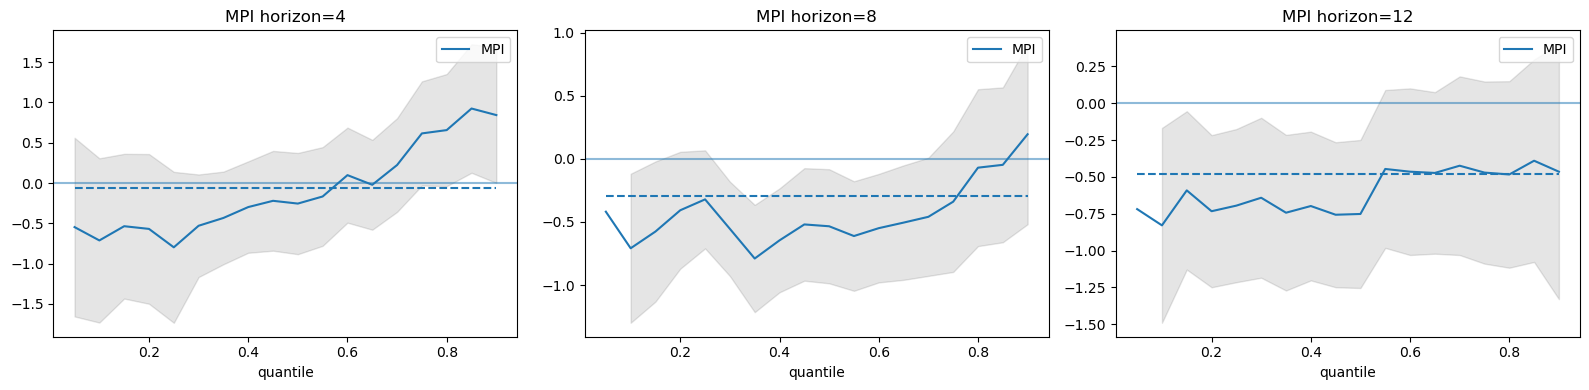

In [29]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['backward'], 'MPI', h, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_b_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

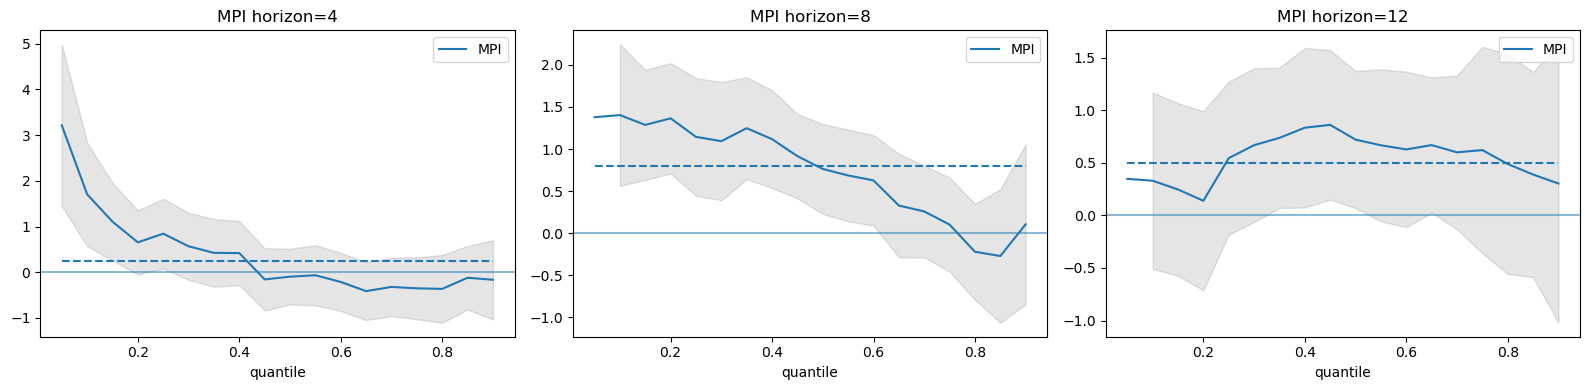

In [31]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'MPI', h, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

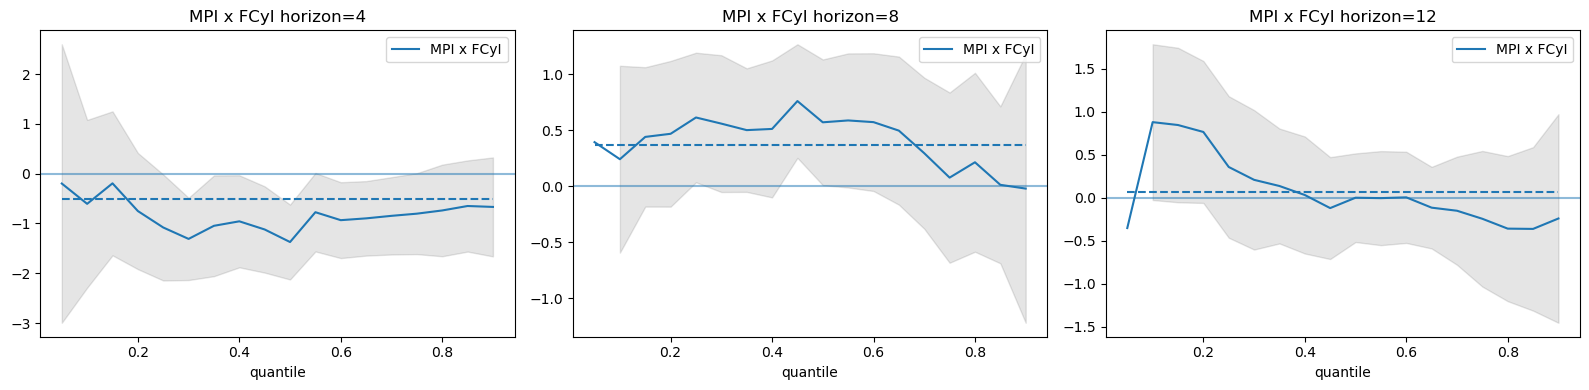

In [64]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'MPI x FCyI', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_MPIxFCyI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

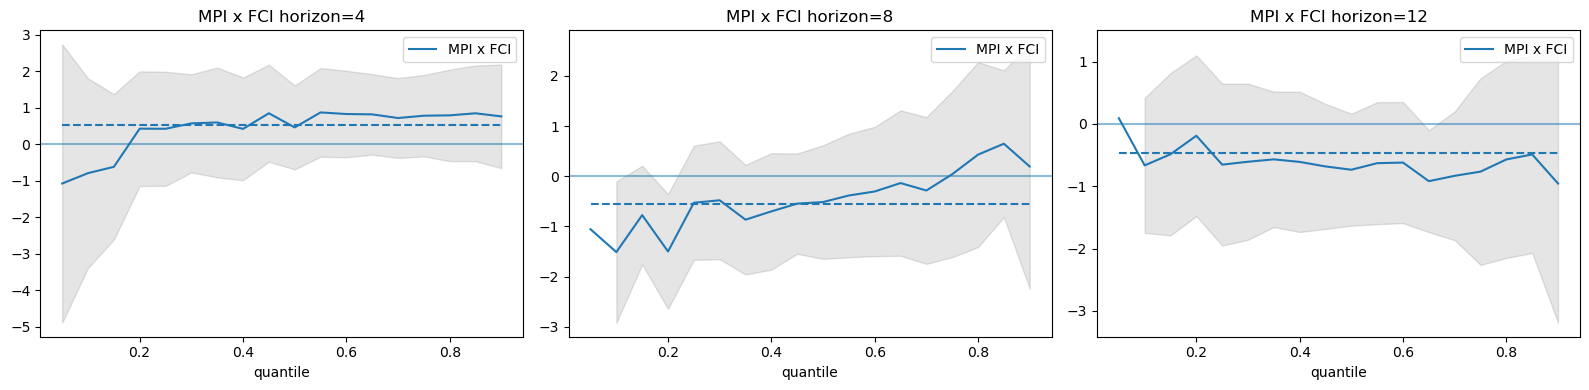

In [65]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'MPI x FCI', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_MPIxFCI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

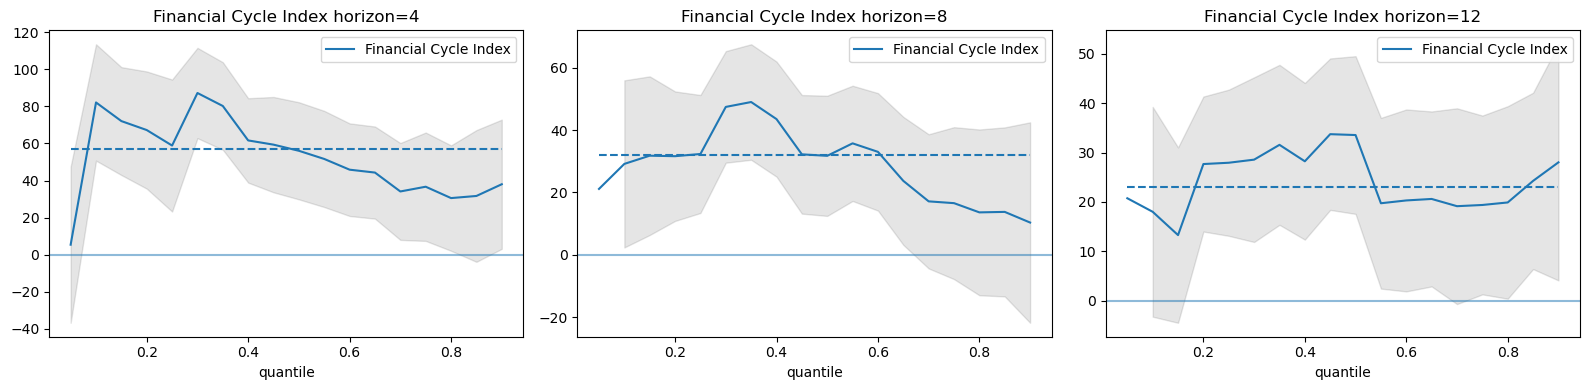

In [66]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['backward'], 'Financial Cycle Index', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCyI_b_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

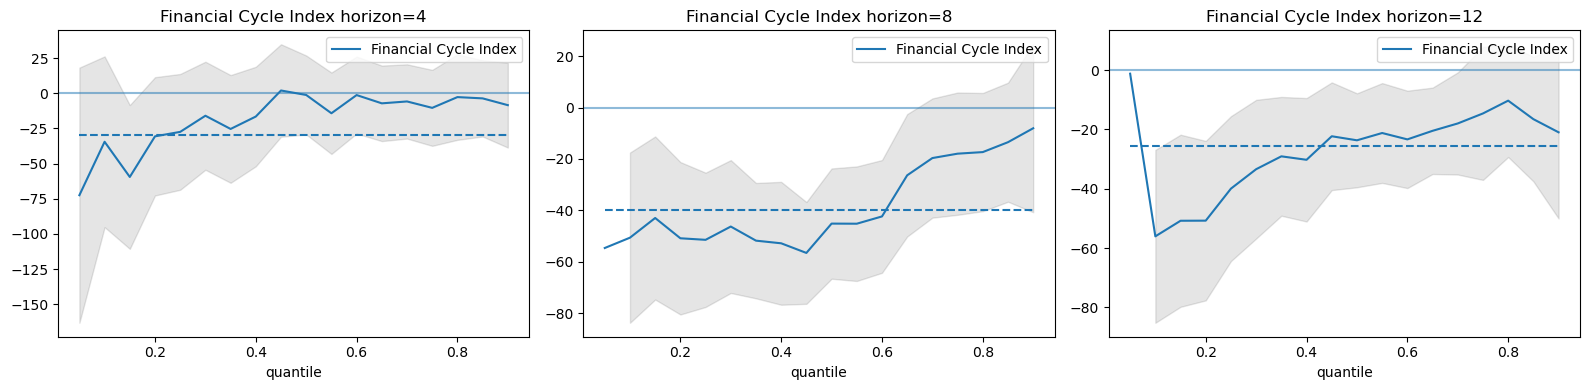

In [67]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'Financial Cycle Index', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCyI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

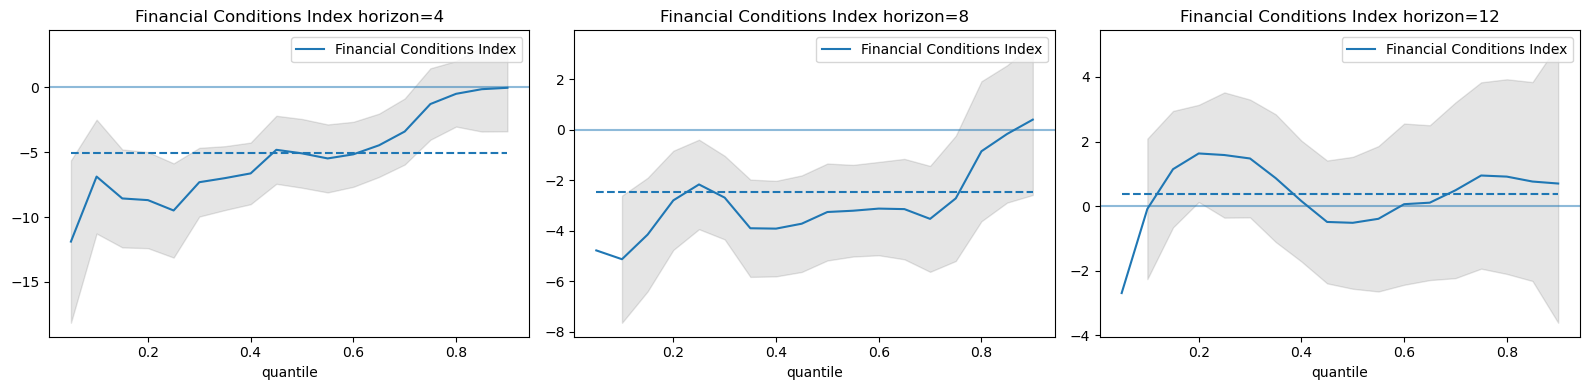

In [68]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['backward'], 'Financial Conditions Index', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCI_b_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

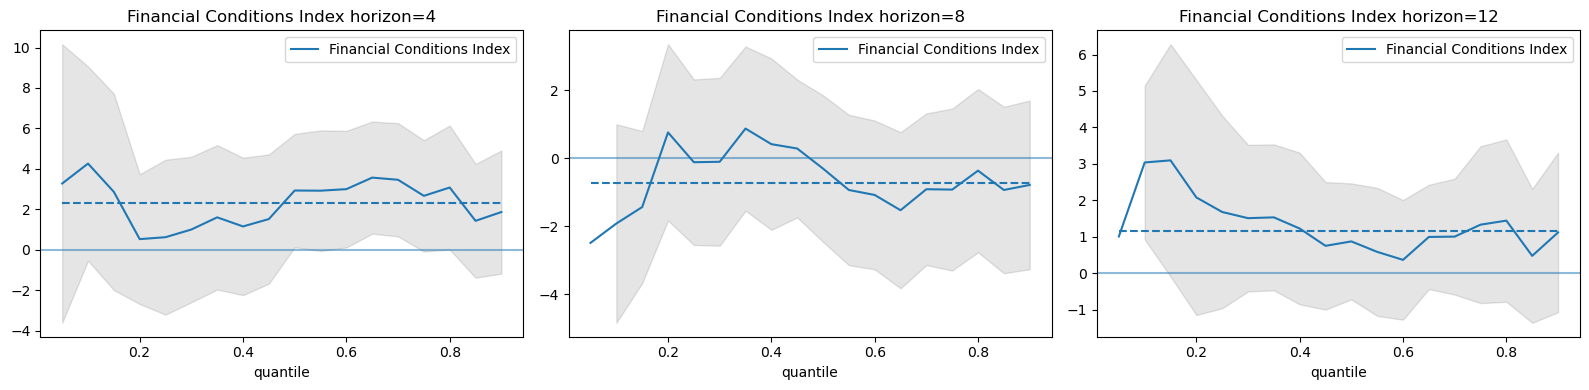

In [69]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'Financial Conditions Index', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

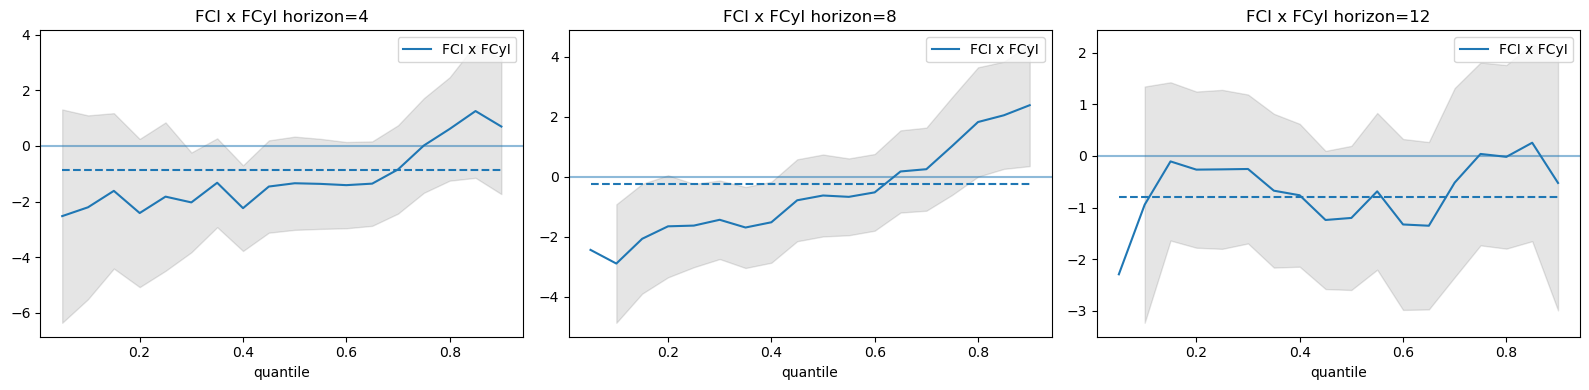

In [70]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['backward'], 'FCI x FCyI', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCIxFCyI_b_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

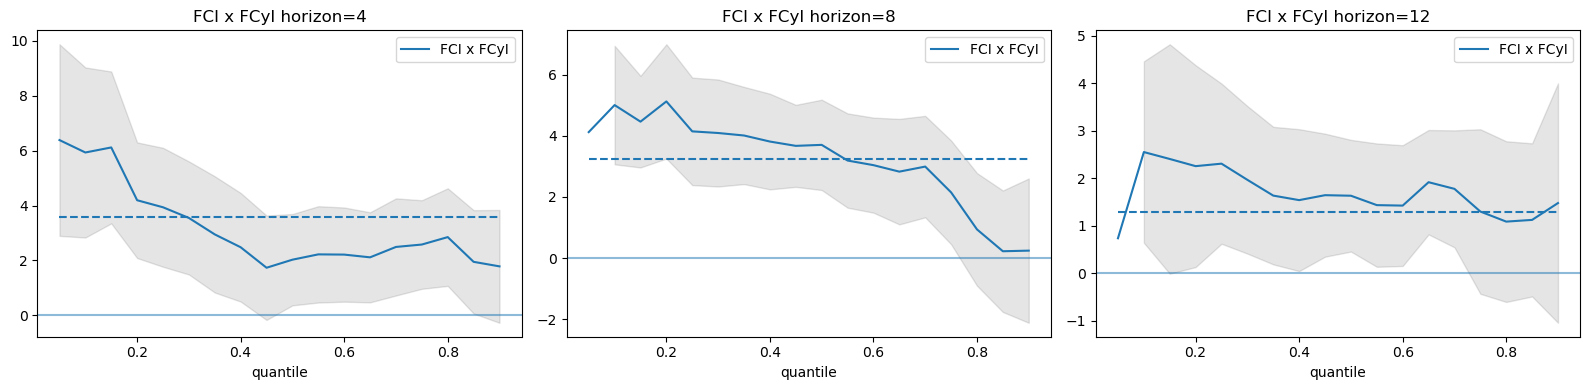

In [71]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], 'FCI x FCyI', h, axes[h_index])
plt.tight_layout()
plt.savefig('../results/arm_FCIxFCyI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

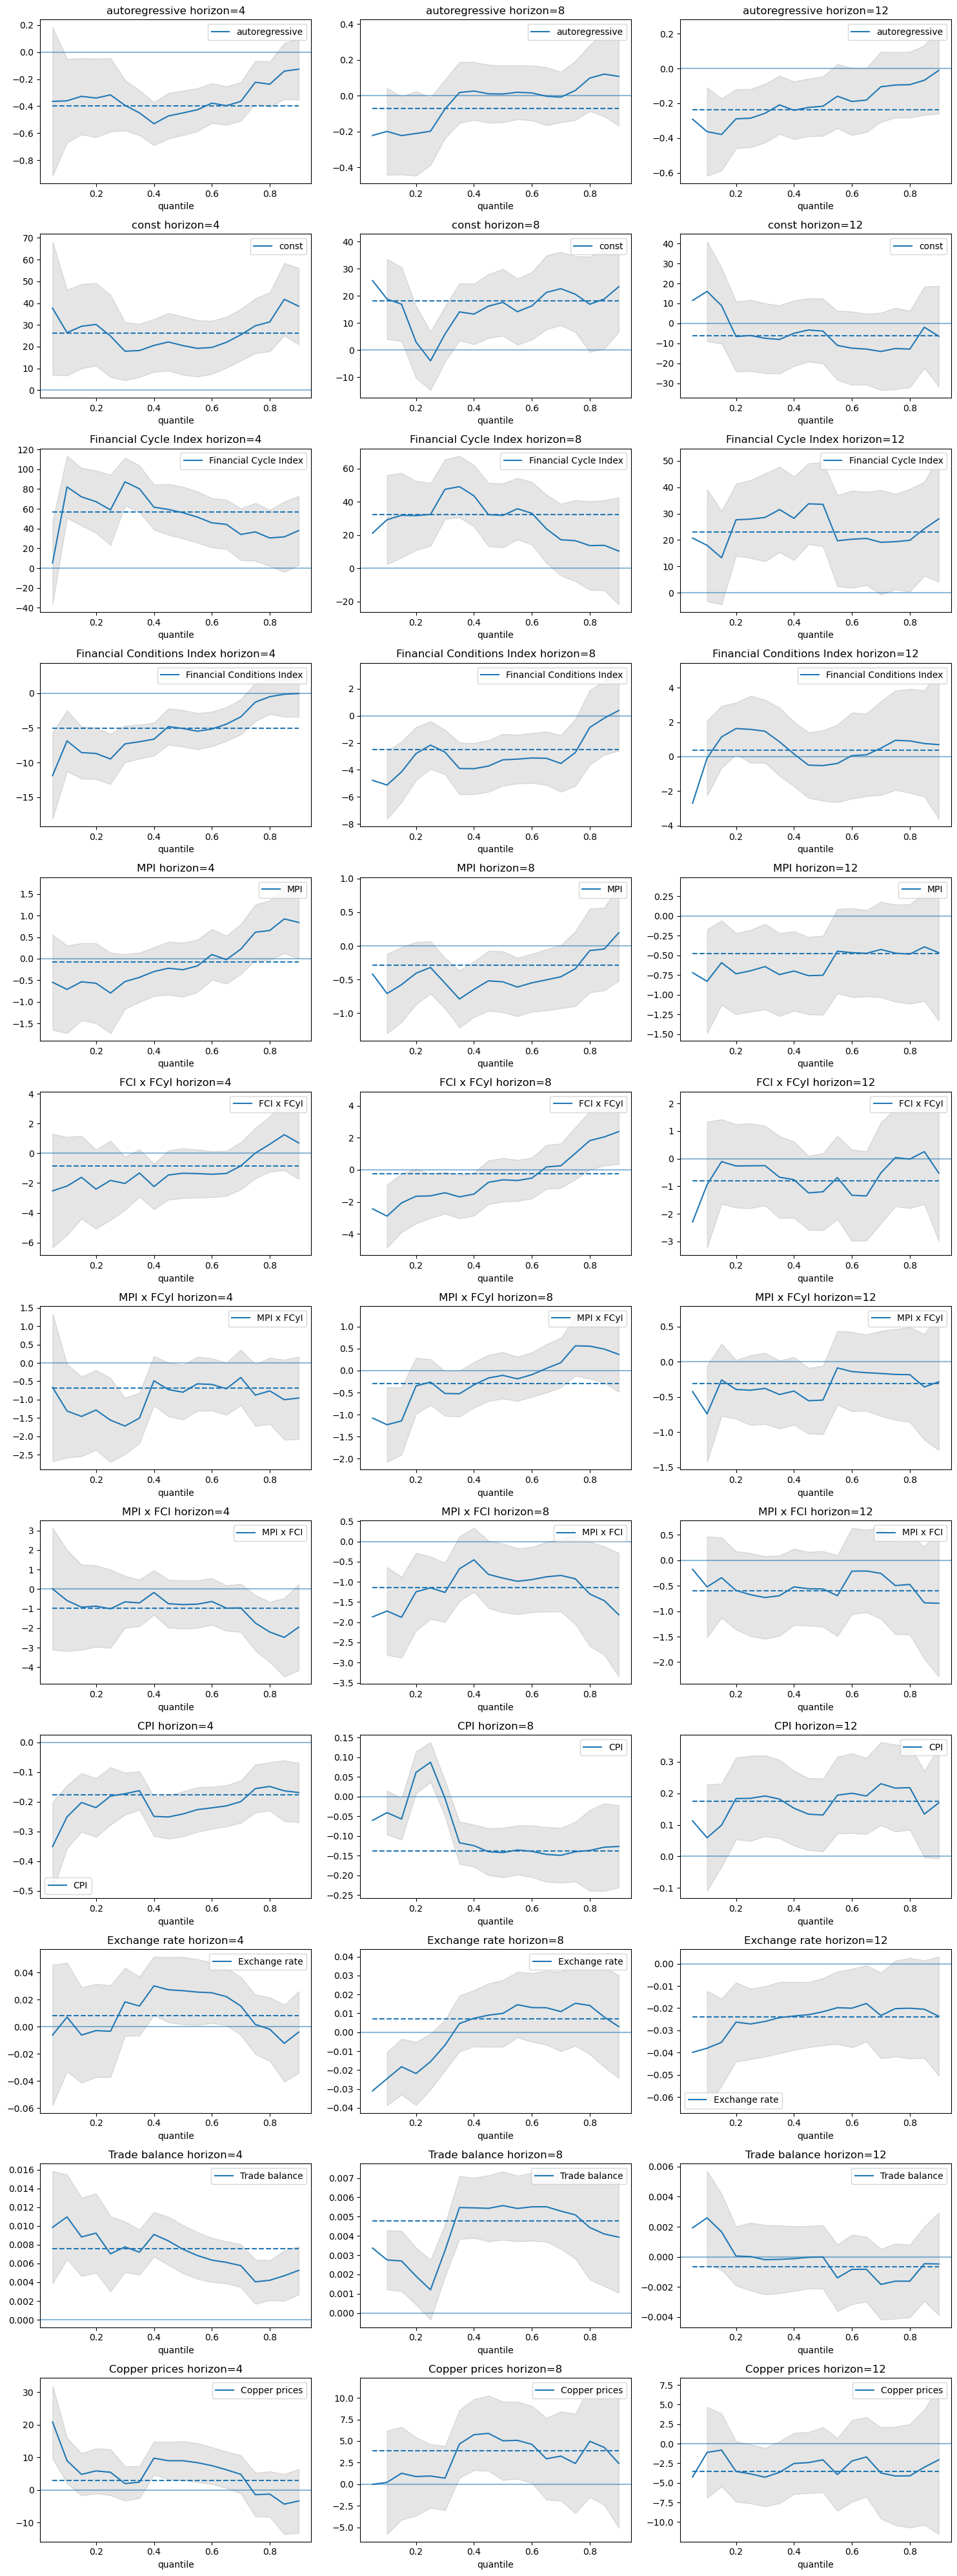

In [72]:
variables = arm_qcoef.index.get_level_values('variable').unique()
variables = [v for v in variables if 'country_' not in v]
fig, axes = plt.subplots(len(variables), len(horizons), figsize=(15, 40))

for v_index, v in enumerate(variables):
    for h_index, h in enumerate(horizons):
        axes[v_index, h_index] = plot_qr_coeff(arm_qcoef.loc['backward'], v, h, axes[v_index, h_index])
plt.tight_layout()
plt.savefig('../results/arm_qr_b_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

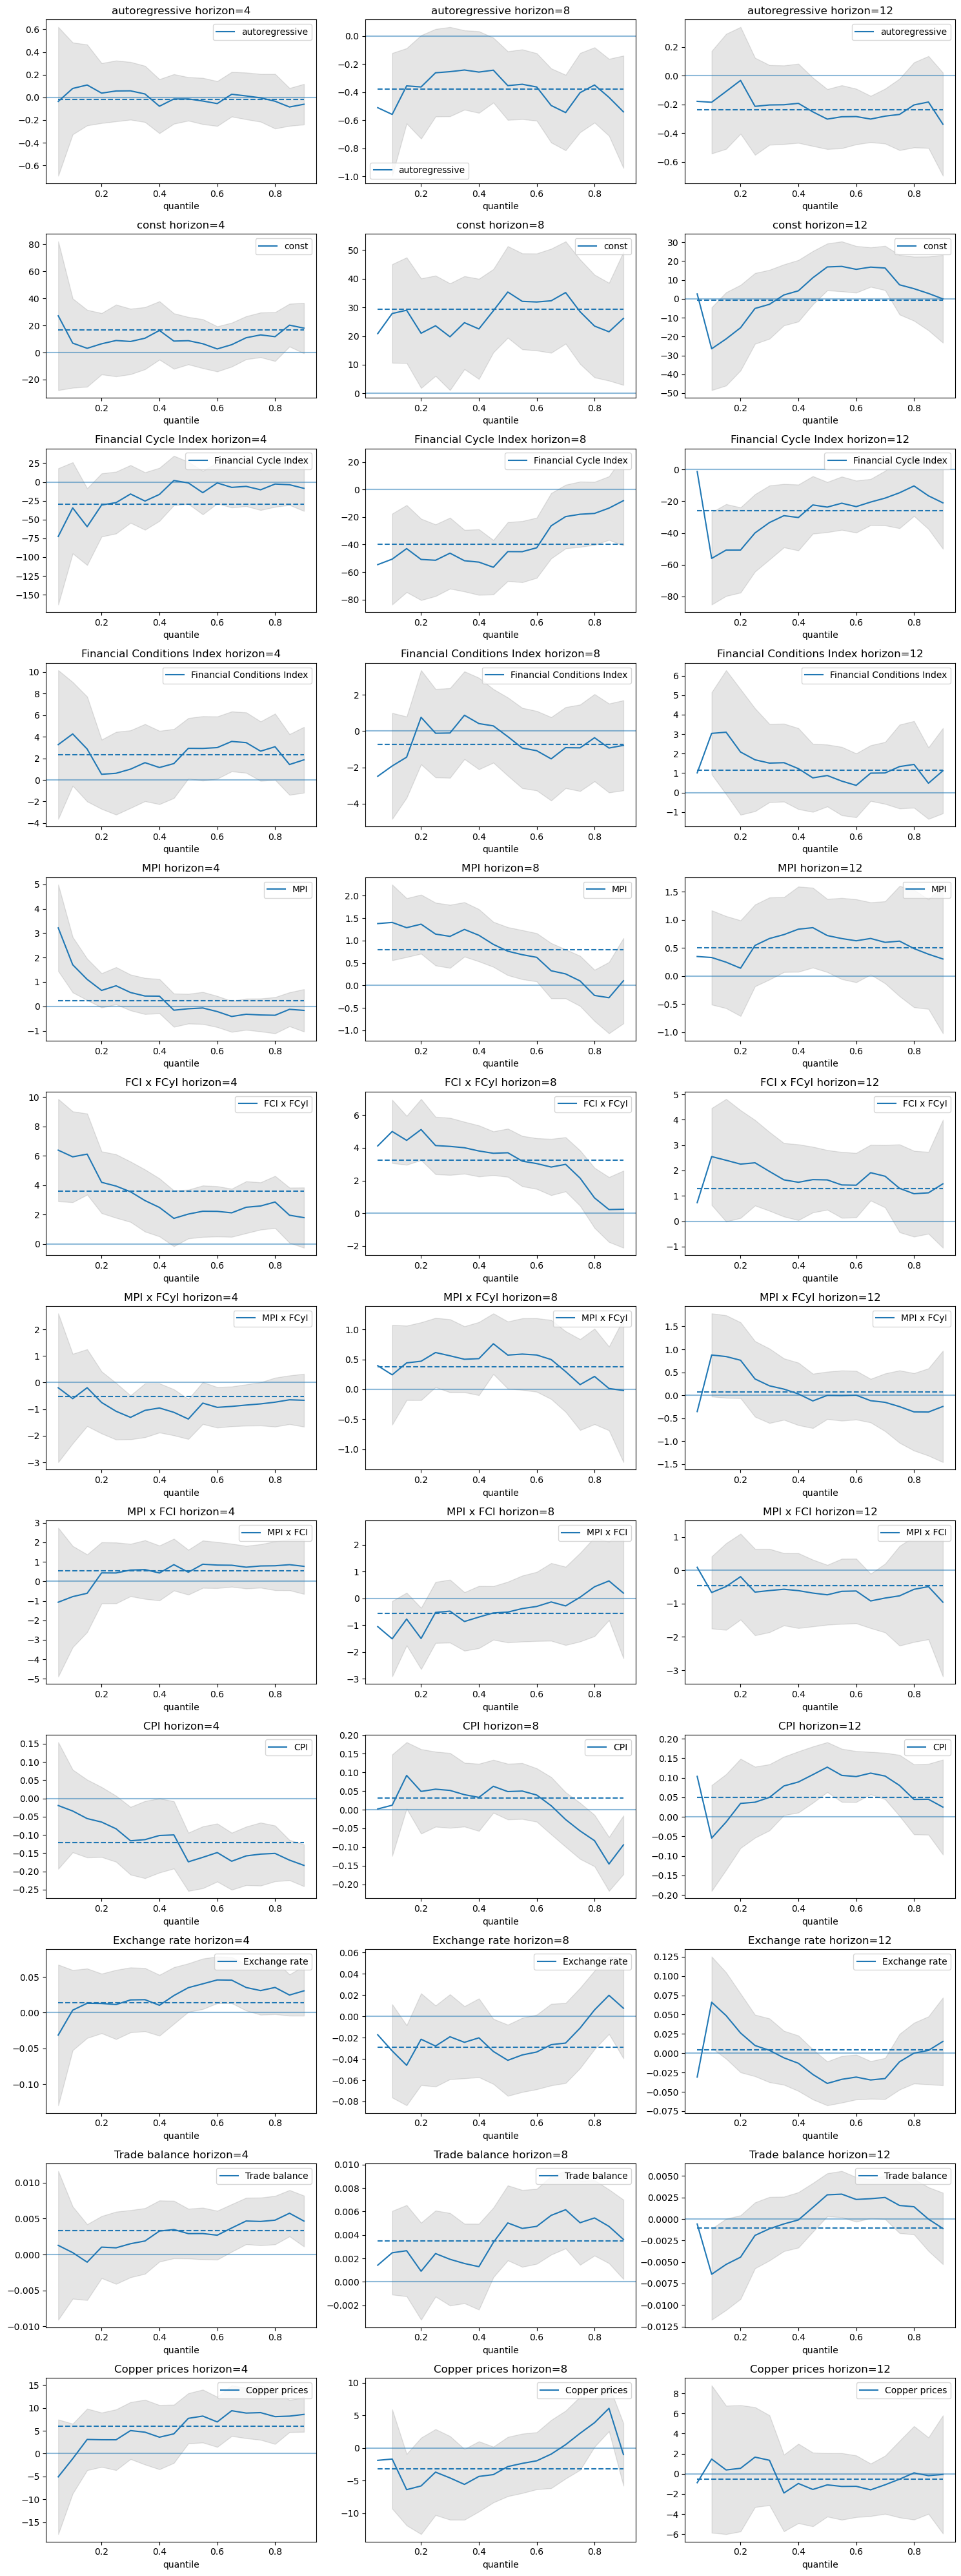

In [73]:
variables = arm_qcoef.index.get_level_values('variable').unique()
variables = [v for v in variables if 'country_' not in v]
fig, axes = plt.subplots(len(variables), len(horizons), figsize=(15, 40))

for v_index, v in enumerate(variables):
    for h_index, h in enumerate(horizons):
        axes[v_index, h_index] = plot_qr_coeff(arm_qcoef.loc['forward'], v, h, axes[v_index, h_index])
plt.tight_layout()
plt.savefig('../results/arm_qr_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

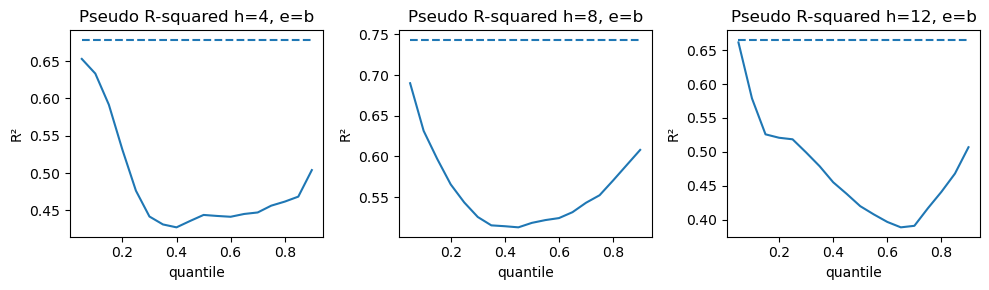

In [74]:
r2s = arm_qcoef.loc['backward']['R2_in_sample'].groupby(['horizon', 'quantile']).mean()
fig, axes = plt.subplots(1, len(horizons), figsize=(10, 3))

for h_index, h in enumerate(horizons):
    r2_h = r2s.loc[h].copy()
    mean = r2_h.pop('mean')
    r2_h.index = r2_h.index.astype(float)
    axes[h_index] = r2_h.plot(ax=axes[h_index], title=f'Pseudo R-squared h={h}, e=b')
    axes[h_index].hlines(mean, r2_h.index.min(), r2_h.index.max(), linestyle='--')
    axes[h_index].set_ylabel('R²')
plt.tight_layout()
plt.savefig('../results/arm_qr_b_r2.png', bbox_inches='tight', dpi=300)
plt.show()

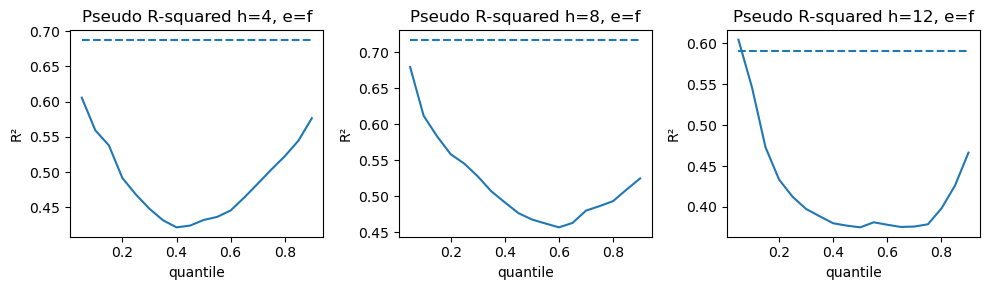

In [75]:
r2s = arm_qcoef.loc['forward']['R2_in_sample'].groupby(['horizon', 'quantile']).mean()
fig, axes = plt.subplots(1, len(horizons), figsize=(10, 3))

for h_index, h in enumerate(horizons):
    r2_h = r2s.loc[h].copy()
    mean = r2_h.pop('mean')
    r2_h.index = r2_h.index.astype(float)
    axes[h_index] = r2_h.plot(ax=axes[h_index], title=f'Pseudo R-squared h={h}, e=f')
    axes[h_index].hlines(mean, r2_h.index.min(), r2_h.index.max(), linestyle='--')
    axes[h_index].set_ylabel('R²')
plt.tight_layout()
plt.savefig('../results/arm_qr_f_r2.png', bbox_inches='tight', dpi=300)
plt.show()

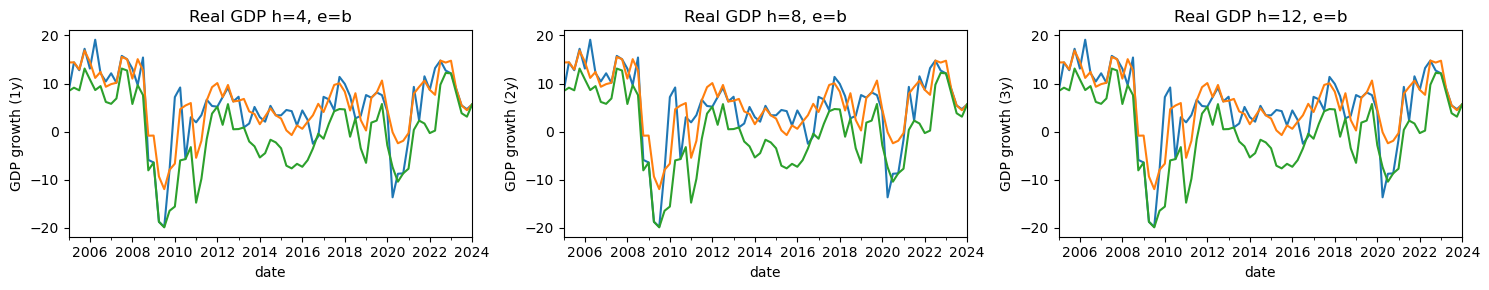

In [76]:
fig, axes = plt.subplots(1, len(horizons), figsize=(15, 3))

for h_index, h in enumerate(horizons):
    ax = axes[h_index]
    c_pred = arm_qr_pred.loc['backward'].loc[4]
    ax = c_pred.loc['mean']['realized_value'].plot(ax=ax, title=f"Real GDP h={h}, e=b")
    ax = c_pred.loc[0.5]['conditional_quantile_mean'].plot(ax=ax)
    ax = c_pred.loc[0.1]['conditional_quantile_mean'].plot(ax=ax)
    ax.set_ylabel(f"GDP growth ({int(h/4)}y)")
plt.tight_layout()
plt.savefig('../results/qr_b_predictions_armenia.png', bbox_inches='tight', dpi=300)
plt.show()

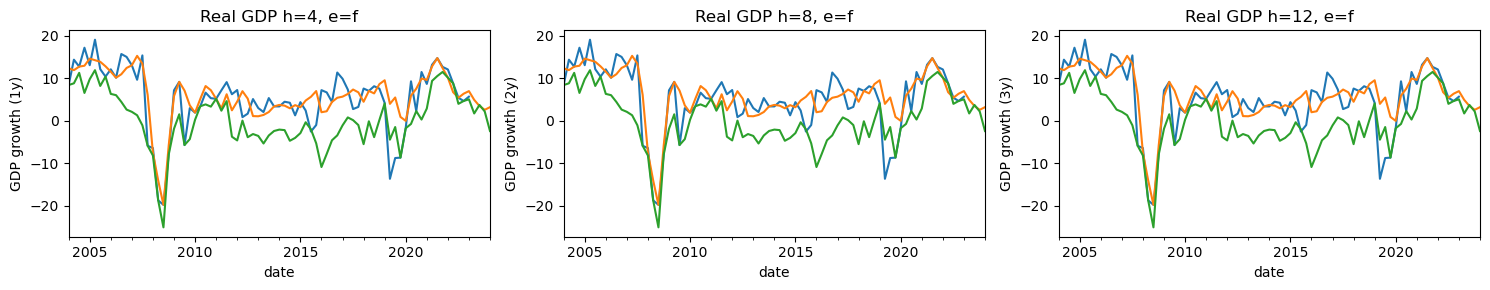

In [77]:
fig, axes = plt.subplots(1, len(horizons), figsize=(15, 3))

for h_index, h in enumerate(horizons):
    ax = axes[h_index]
    c_pred = arm_qr_pred.loc['forward'].loc[4]
    ax = c_pred.loc['mean']['realized_value'].plot(ax=ax, title=f"Real GDP h={h}, e=f")
    ax = c_pred.loc[0.5]['conditional_quantile_mean'].plot(ax=ax)
    ax = c_pred.loc[0.1]['conditional_quantile_mean'].plot(ax=ax)
    ax.set_ylabel(f"GDP growth ({int(h/4)}y)")
plt.tight_layout()
plt.savefig('../results/qr_f_predictions_armenia.png', bbox_inches='tight', dpi=300)
plt.show()

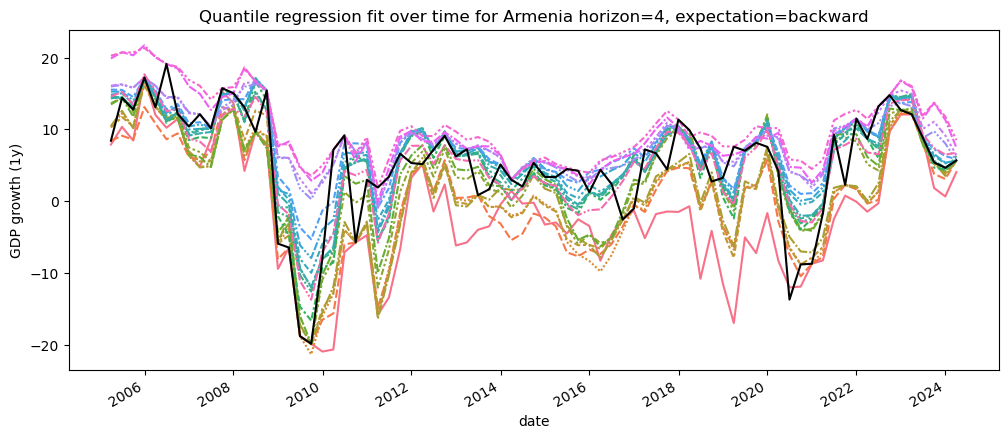

In [78]:
horizon = 4
actual = arm_qr_pred.loc['backward'].loc[horizon].loc['mean']['realized_value']
pred = arm_qr_pred.loc['backward'].pivot_table('conditional_quantile_mean', index=['horizon', 'date'], columns='tau')
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=pred.loc[horizon], ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={horizon}, expectation=backward')
plt.ylabel(f'GDP growth ({int(horizon/4)}y)')
plt.legend([], [], frameon=False)
plt.savefig('../results/arm_qr_b_fits.png', bbox_inches='tight', dpi=300)
plt.show()

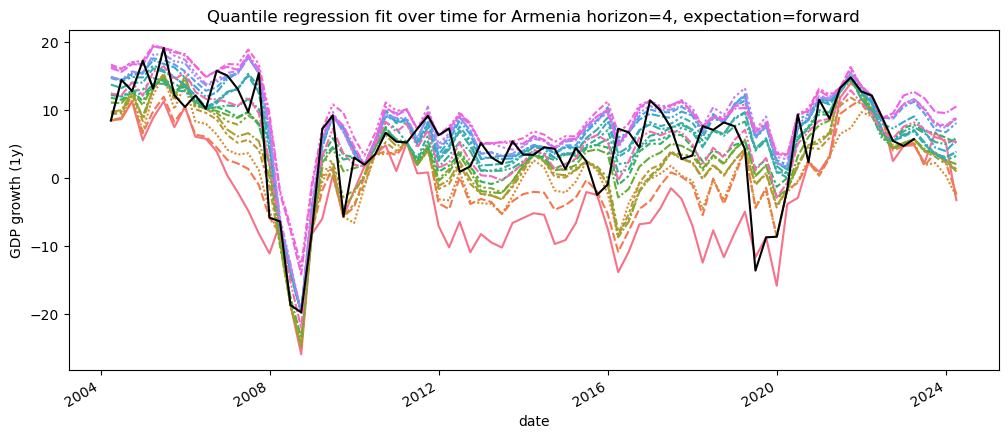

In [79]:
horizon = 4
actual = arm_qr_pred.loc['forward'].loc[horizon].loc['mean']['realized_value']
pred = arm_qr_pred.loc['forward'].pivot_table('conditional_quantile_mean', index=['horizon', 'date'], columns='tau')
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=pred.loc[horizon], ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={horizon}, expectation=forward')
plt.ylabel(f'GDP growth ({int(horizon/4)}y)')
plt.legend([], [], frameon=False)
plt.savefig('../results/arm_qr_f_fits.png', bbox_inches='tight', dpi=300)
plt.show()

In [80]:
# Saving the estimation results
arm_qcoef.to_pickle('../data/working_data/arm_qcoef.pkl')
arm_qcoef_norm.to_pickle('../data/working_data/arm_qcoef_norm.pkl')
arm_qr_pred.to_pickle('../data/working_data/arm_qr_pred.pkl')
macro_dataset.to_pickle('../data/working_data/arm_macro_dataset.pkl')
exog.to_pickle('../data/working_data/arm_exog.pkl')

# Distribution fitting

In [81]:
# theme setup
sns.reset_defaults()

# tsfit input data:
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
fit_methods = ['T-skew', 'Kernel-based']
fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value': None, 'bandwidth': None},
    'qsmooth': None,
    'qsmooth_period': 4,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': True,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

In [82]:
# dist fitting data setup
arm_qcoef = pd.read_pickle('../data/working_data/arm_qcoef.pkl')
arm_qcoef_norm = pd.read_pickle('../data/working_data/arm_qcoef_norm.pkl')
macro_dataset = pd.read_pickle('../data/working_data/arm_macro_dataset.pkl')
exog = pd.read_pickle('../data/working_data/arm_exog.pkl')

# defining exog transformers
ss_fcyi = StandardScalerDF()
fcyi_tf = ss_fcyi.fit_transform(exog['Financial Cycle Index'])
ss_fci = StandardScalerDF()
fci_tf = ss_fci.fit_transform(exog['Financial Conditions Index'])

# exog dataset for making predictions
macro_dataset.columns.name = 'variable'
macro_dataset_stack = macro_dataset.stack()
macro_dataset_stack.name = 'exog'
macro_dataset_stack = macro_dataset_stack.reset_index()

# coeff set
arm_qcoef_values = arm_qcoef['coeff'].reset_index()

# gdp distribution dataset
gdp_dist_details = pd.merge(macro_dataset_stack, arm_qcoef_values, 'outer', ['expectation', 'horizon', 'variable'])
gdp_dist_details['quantile'] = gdp_dist_details['quantile'].fillna('actual')
gdp_dist_details['coeff'] = gdp_dist_details['coeff'].fillna(1)
gdp_dist_details = gdp_dist_details.set_index(['expectation', 'horizon', 'date', 'variable', 'quantile']).sort_index()

# generating shock columns
mpi_shocks = np.arange(-1, 2.5, 0.5)
mpi_rows = gdp_dist_details.index.get_level_values('variable') == 'MPI'
mpi_fcyi_rows = gdp_dist_details.index.get_level_values('variable') == 'MPI x FCyI'
mpi_fci_rows = gdp_dist_details.index.get_level_values('variable') == 'MPI x FCI'
fcyi_rows = gdp_dist_details.index.get_level_values('variable') == 'Financial Cycle Index'
fci_rows = gdp_dist_details.index.get_level_values('variable') == 'Financial Conditions Index'

# deriving direct effects
gdp_det_direct = []
for shock in mpi_shocks:
    gdp_det_i = gdp_dist_details.copy()
    gdp_det_i.loc[mpi_rows, 'exog'] = gdp_det_i.loc[mpi_rows, 'exog'] + shock
    gdp_det_i['MPI_shock'] = shock
    gdp_det_i['policy_effect_type'] = 'direct'
    gdp_det_direct.append(gdp_det_i)

# deriving interaction effects
gdp_det_interaction = []
for shock in mpi_shocks:
    gdp_det_i = gdp_dist_details.copy()
    mpi_init = gdp_det_i.loc[mpi_rows, 'exog'].values.copy()
    fcyi_init = ss_fcyi.transform(gdp_det_i.loc[fcyi_rows, 'exog']).values.copy()
    fci_init = ss_fci.transform(gdp_det_i.loc[fci_rows, 'exog']).values.copy()
    gdp_det_i.loc[mpi_rows, 'exog'] = mpi_init + shock
    gdp_det_i.loc[mpi_fcyi_rows, 'exog'] = fcyi_init * (mpi_init + shock)
    gdp_det_i.loc[mpi_fci_rows, 'exog'] = fci_init * (mpi_init + shock)
    gdp_det_i['MPI_shock'] = shock
    gdp_det_i['policy_effect_type'] = 'interaction'
    gdp_det_interaction.append(gdp_det_i)
shock_dims = ['policy_effect_type', 'MPI_shock']
gdp_dist_details = pd.concat(gdp_det_direct + gdp_det_interaction).set_index(shock_dims, append=True).sort_index()

# predicting effects
gdp_dist_details['pred'] = gdp_dist_details['coeff']*gdp_dist_details['exog']

# making gdp dist predictions
pred_dims = ['expectation', 'horizon', 'date', 'policy_effect_type', 'MPI_shock', 'quantile']
prediction = gdp_dist_details.groupby(pred_dims)['pred'].sum()

In [83]:
# saving the results
gdp_dist_details.to_pickle('../data/working_data/arm_gdp_dist_details.pkl')
prediction.to_pickle('../data/working_data/arm_prediction.pkl')

In [84]:
# loading
prediction = pd.read_pickle('../data/working_data/arm_prediction.pkl')

In [85]:
# fit a distribution for each set of quantile predictions using different methods
prediction_dist_fit = []
pre = prediction.copy()
pred_dist = pre.reset_index(pre.index.names[:-1]).groupby(pre.index.names[:-1])
for method in tqdm(fit_methods):
    fit_params['fittype'] = method
    pred_dist_fit = pred_dist['pred'].apply(lambda x: pd.Series(dist_fit(x.to_dict(), fit_params)))
    pred_dist_fit = pred_dist_fit.unstack(level=-1)
    pred_dist_fit['method'] = method
    pred_dist_fit.set_index('method', append=True, inplace=True)
    prediction_dist_fit.append(pred_dist_fit)
prediction_dist_fit = pd.concat(prediction_dist_fit)
index_order = ['expectation', 'horizon', 'date', 'method', 'policy_effect_type', 'MPI_shock']
prediction_dist_fit = prediction_dist_fit.reorder_levels(index_order).sort_index()

  0%|          | 0/2 [00:00<?, ?it/s]


KeyboardInterrupt



In [ ]:
# saving the results
prediction_dist_fit.to_pickle('../data/working_data/arm_prediction_dist_fit.pkl')

In [ ]:
# loading
prediction_dist_fit = pd.read_pickle('../data/working_data/arm_prediction_dist_fit.pkl')

In [ ]:
# select a fixed set of gdp growth values for which we'll be calculating their respective pdf and cdf values
prediction_dist_fit_subset = prediction_dist_fit.loc['forward'].loc[4].xs(0, level='MPI_shock')
prediction_dist_fit_subset = prediction_dist_fit_subset.xs('direct', level='policy_effect_type')
model_q = prediction_dist_fit_subset.reset_index().apply(lambda x: get_model_quantiles(x['model_fit'], x['method']), axis=1)
model_q = model_q.apply(pd.Series)
model_q.columns = ['v_q15', 'v_q40', 'v_q60', 'v_q85']
model_q['min'] = model_q['v_q15'] - (model_q['v_q15']-model_q['v_q40']).abs()
model_q['max'] = model_q['v_q85'] + (model_q['v_q85']-model_q['v_q60']).abs()
gdp_growth_values = np.array([x for x in np.linspace(model_q['min'].quantile(0.03),
                                                     model_q['max'].quantile(0.9), 500)])

In [ ]:
# calculate the pdf and cdf values
prediction_dfpdf = prediction_dist_fit.apply(lambda x: gen_PDF_and_CDF(x['model_fit'], x.name[-3],
                                                                       gdp_growth_values, x['modx']), axis=1)
prediction_dfpdf = prediction_dfpdf.apply(lambda x: x.stack()).stack().stack().unstack(-2)
prediction_dfpdf.index.names = prediction_dfpdf.index.names[:-1] + ['index']

In [ ]:
# saving the results
prediction_dfpdf.to_pickle('../data/working_data/arm_prediction_dfpdf.pkl')

In [86]:
# loading
prediction = pd.read_pickle('../data/working_data/arm_prediction.pkl')
prediction_dist_fit = pd.read_pickle('../data/working_data/arm_prediction_dist_fit.pkl')
prediction_dfpdf = pd.read_pickle('../data/working_data/arm_prediction_dfpdf.pkl')

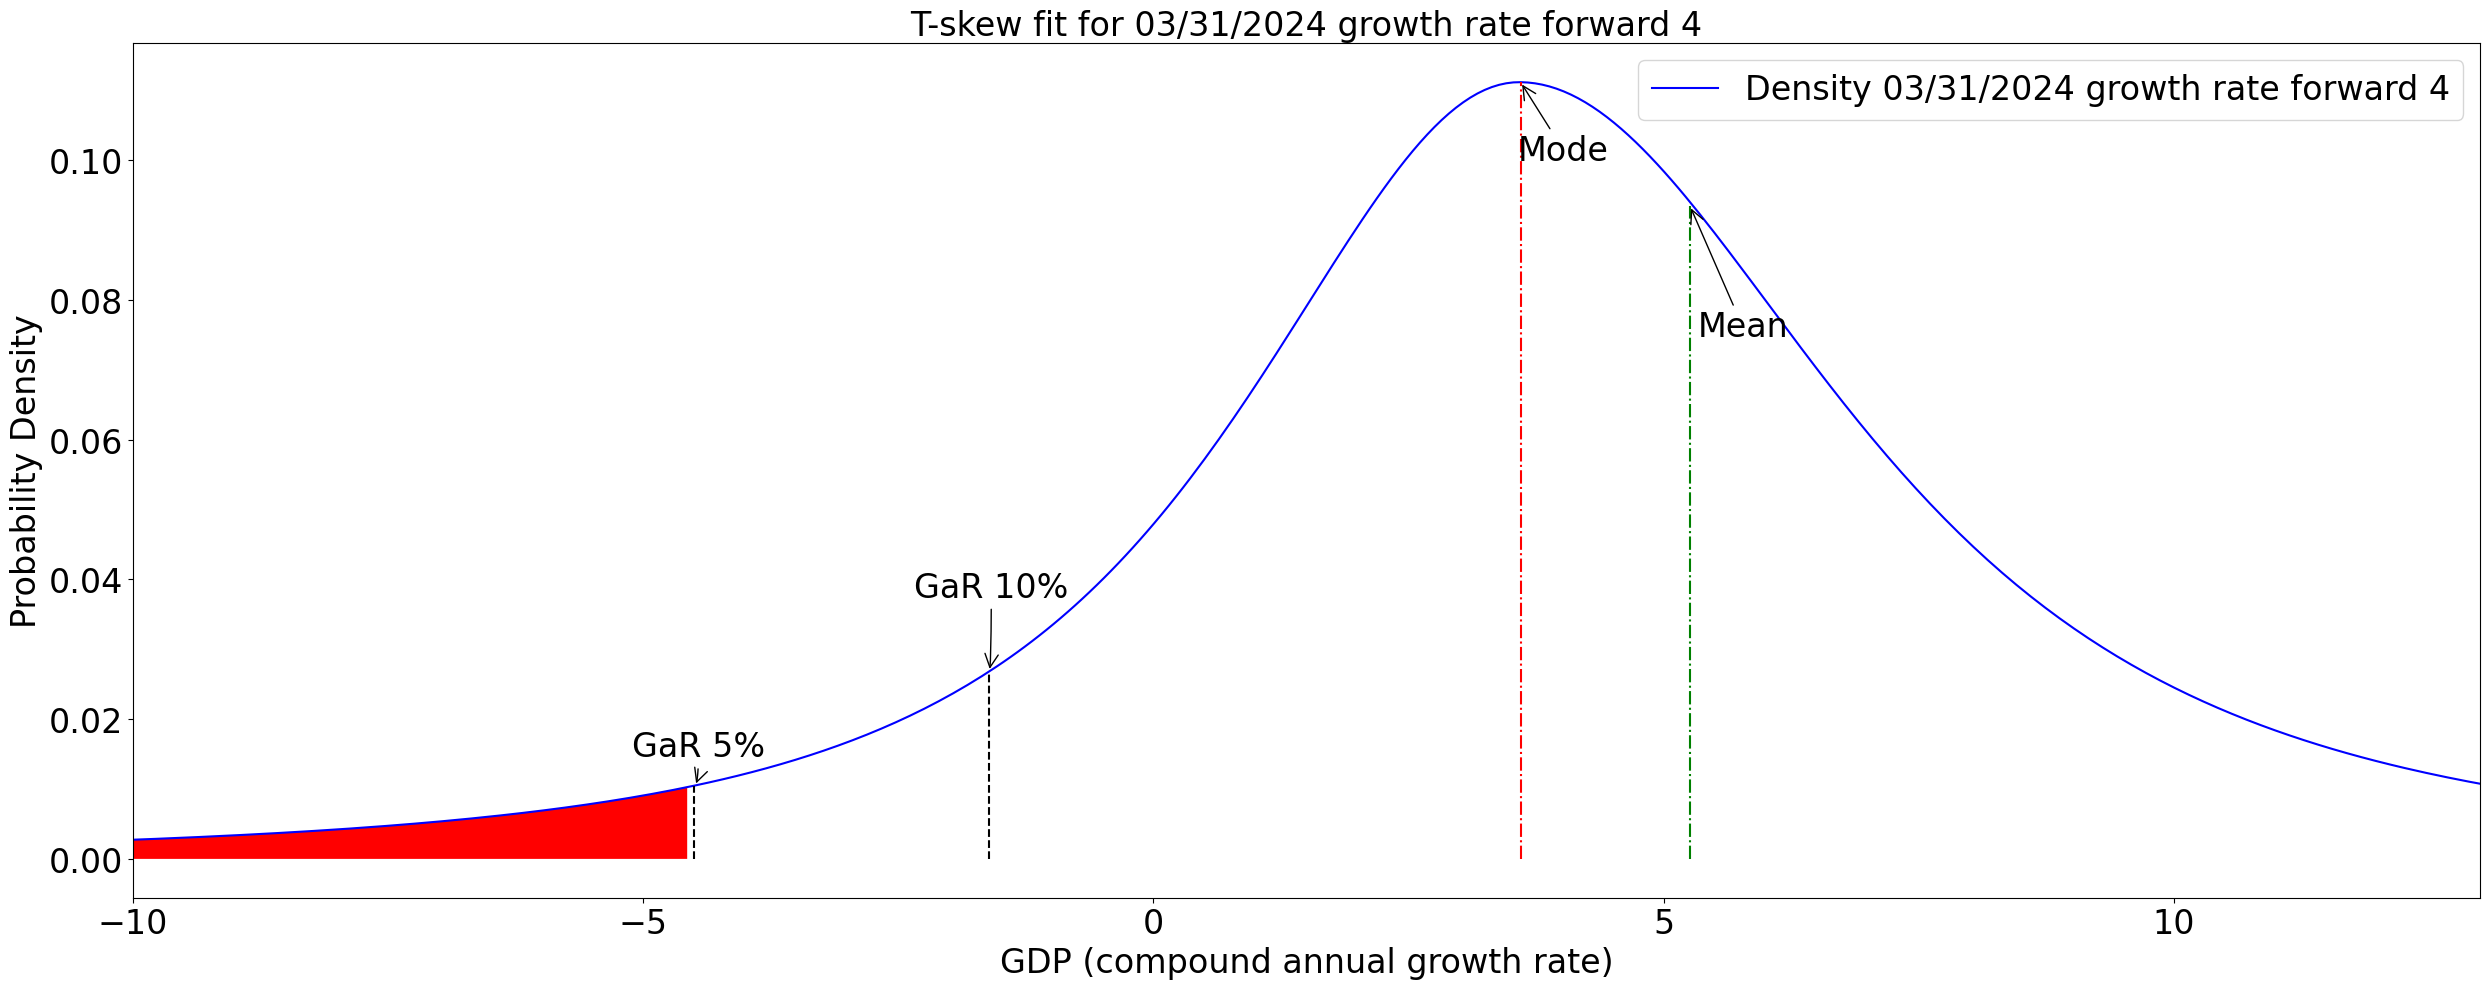

In [87]:
expectation = 'forward'
horizon = 4
plot_date = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock = 0
pred_index = (expectation, horizon, plot_date, policy_effect_type, mpi_shock)
dist_index = (expectation, horizon, plot_date, method, policy_effect_type, mpi_shock)

x_list, yvals, ycdf = prediction_dfpdf.loc[dist_index].values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q10_index = np.argmin(np.abs(ycdf - 0.1))
q40_index = np.argmin(np.abs(ycdf - 0.4))
q50_index = np.argmin(np.abs(ycdf - 0.5))
x_inc = (yvals[q40_index]-yvals[q5_index])/4
xq5 = x_list[q5_index]
yq5 = yvals[q5_index]
xq10 = x_list[q10_index]
yq10 = yvals[q10_index]
xq50 = x_list[q50_index]
yq50 = yvals[q50_index]

fig, ax = plt.subplots(1, 1, figsize=(25, 10))
titlestr = f"{method} fit for "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
lablestr = "Density "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='red', interpolate=True)
ax.plot(x_list, yvals, 'b-', label=lablestr)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
# ax.set_ylim(0, 1.3 * max(yvals))
# ax.set_xlim(xq5-2, xq50+4)
plt.ylabel('Probability Density', fontsize=24)
plt.xlabel('GDP (compound annual growth rate)', fontsize=24)

# plot mod
modx = x_list[np.argmax(yvals)]
mody = yvals.max()
ax.plot([modx, modx], [0, mody], 'r-.')
ax.annotate('Mode', xy=(modx, mody), xycoords='data',
            xytext=(modx-x_inc, mody*0.9), textcoords='data',
            arrowprops=dict(arrowstyle="->",
            connectionstyle="arc3"), fontsize=24)

# plot mean
meanx = prediction.loc[pred_index].loc['mean']
meany = yvals[np.argmin(np.abs(x_list-meanx))]
ax.plot([meanx, meanx], [0, meany], 'g-.')
ax.annotate('Mean', xy=(meanx, meany), xycoords='data',
            xytext=(meanx+x_inc*3, meany*0.8), textcoords='data',
            arrowprops=dict(arrowstyle="->",
            connectionstyle="arc3"), fontsize=24)

# plot tails
ax.plot([xq5, xq5], [0, yq5], 'k--')
ax.annotate('GaR 5%', xy=(xq5, yq5), xycoords='data',
            xytext=(xq5-x_inc*25, yq5*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
ax.plot([xq10, xq10], [0, yq10], 'k--')
ax.annotate('GaR 10%', xy=(xq10, yq10), xycoords='data',
            xytext=(xq10-x_inc*30, yq10*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
plt.xlim((-10, 13))
plt.tight_layout()
plt.savefig('../results/arm_qr_gdp_dist.png', bbox_inches='tight', dpi=300)
plt.show()

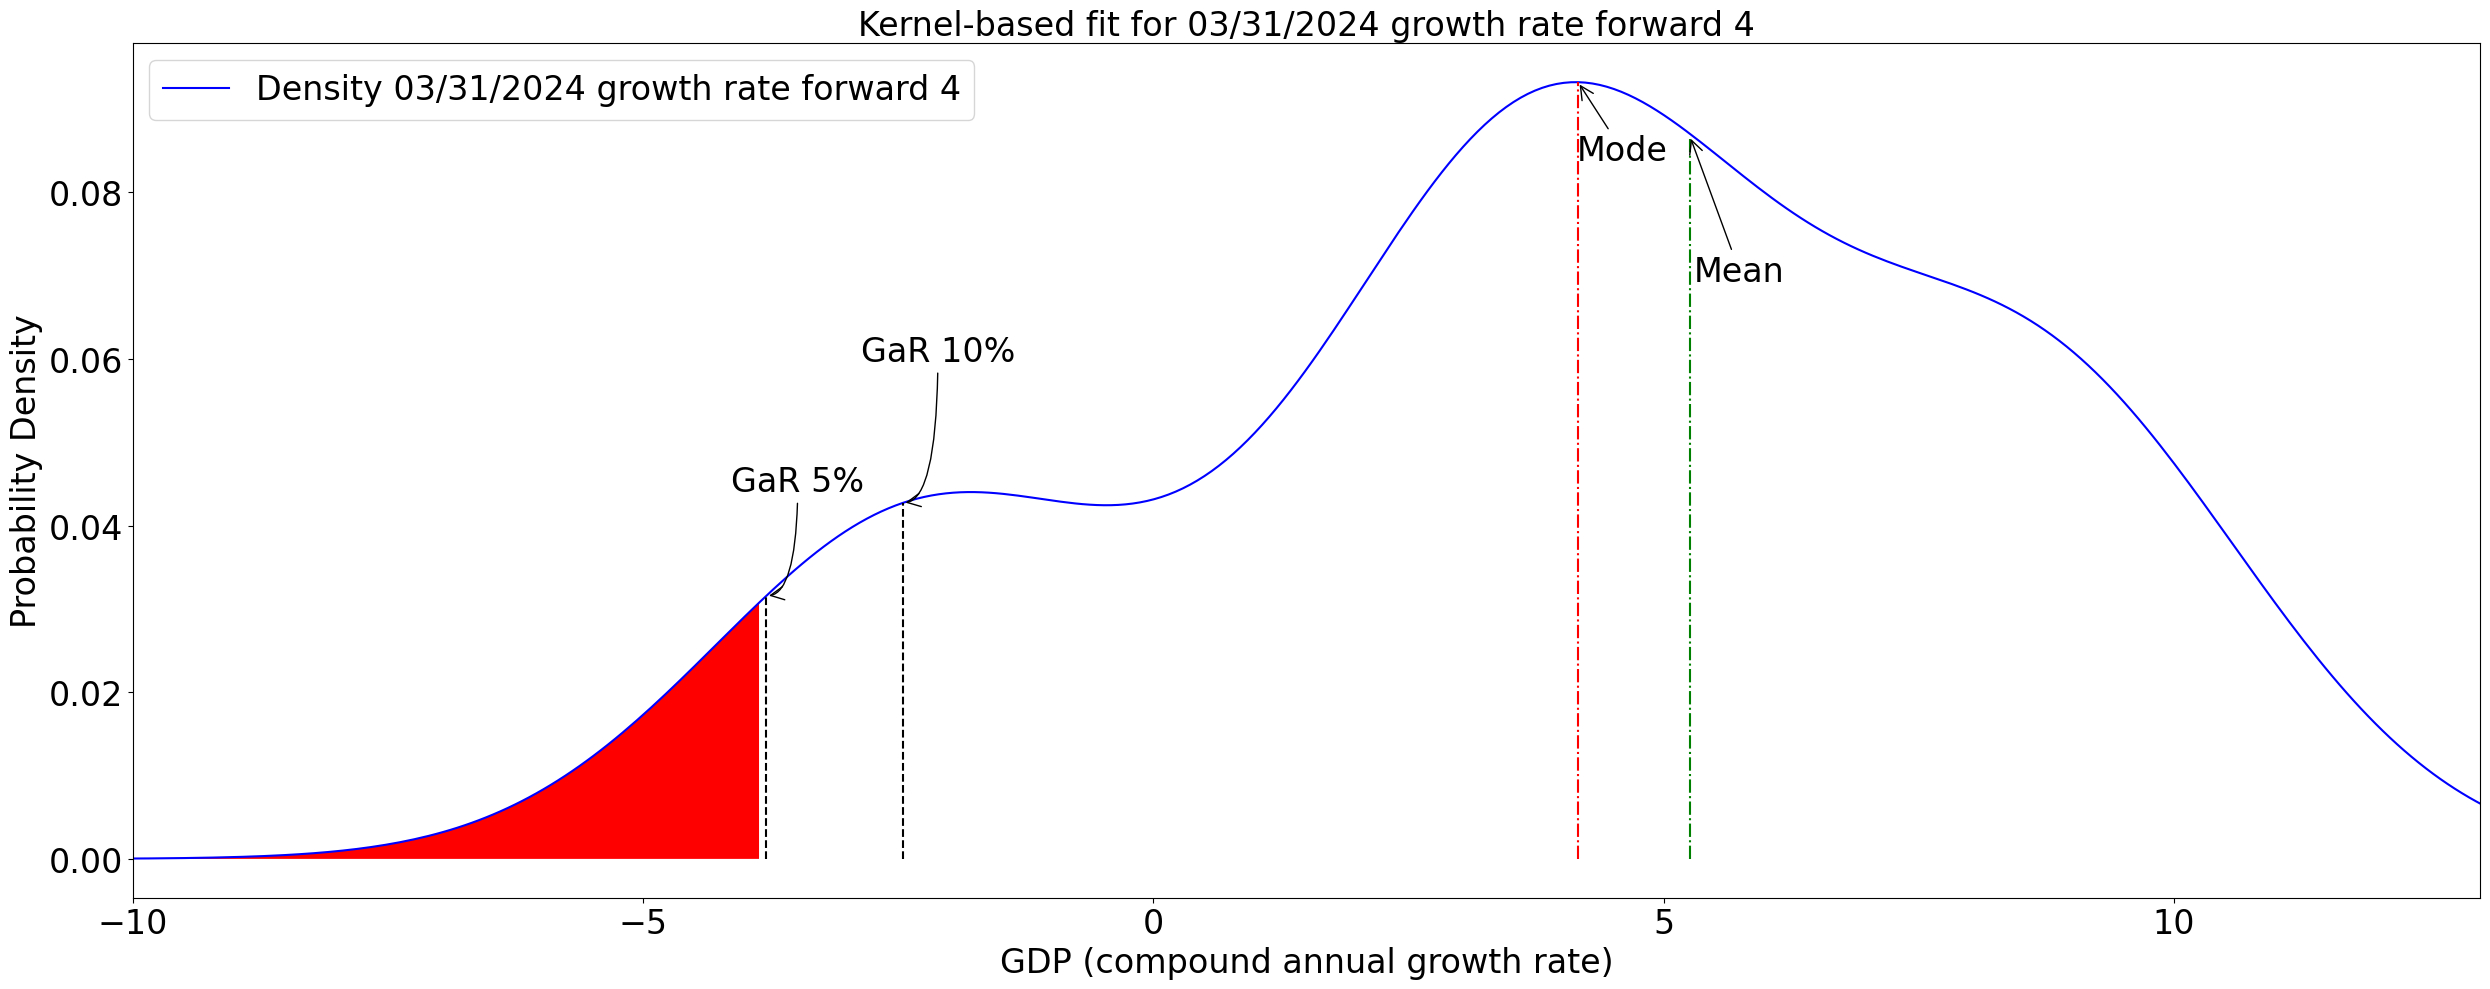

In [88]:
expectation = 'forward'
horizon = 4
plot_date = parser.parse('2024-03-31')
method = 'Kernel-based'
policy_effect_type = 'direct'
mpi_shock = 0
pred_index = (expectation, horizon, plot_date, policy_effect_type, mpi_shock)
dist_index = (expectation, horizon, plot_date, method, policy_effect_type, mpi_shock)

x_list, yvals, ycdf = prediction_dfpdf.loc[dist_index].values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q10_index = np.argmin(np.abs(ycdf - 0.1))
q40_index = np.argmin(np.abs(ycdf - 0.4))
q50_index = np.argmin(np.abs(ycdf - 0.5))
x_inc = (yvals[q40_index]-yvals[q5_index])/4
xq5 = x_list[q5_index]
yq5 = yvals[q5_index]
xq10 = x_list[q10_index]
yq10 = yvals[q10_index]
xq50 = x_list[q50_index]
yq50 = yvals[q50_index]

fig, ax = plt.subplots(1, 1, figsize=(25, 10))
titlestr = f"{method} fit for "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
lablestr = "Density "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='red', interpolate=True)
ax.plot(x_list, yvals, 'b-', label=lablestr)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
# ax.set_ylim(0, 1.3 * max(yvals))
# ax.set_xlim(xq5-2, xq50+4)
plt.ylabel('Probability Density', fontsize=24)
plt.xlabel('GDP (compound annual growth rate)', fontsize=24)

# plot mod
modx = x_list[np.argmax(yvals)]
mody = yvals.max()
ax.plot([modx, modx], [0, mody], 'r-.')
ax.annotate('Mode', xy=(modx, mody), xycoords='data',
            xytext=(modx-x_inc, mody*0.9), textcoords='data',
            arrowprops=dict(arrowstyle="->",
            connectionstyle="arc3"), fontsize=24)

# plot mean
meanx = prediction.loc[pred_index].loc['mean']
meany = yvals[np.argmin(np.abs(x_list-meanx))]
ax.plot([meanx, meanx], [0, meany], 'g-.')
ax.annotate('Mean', xy=(meanx, meany), xycoords='data',
            xytext=(meanx+x_inc*3, meany*0.8), textcoords='data',
            arrowprops=dict(arrowstyle="->",
            connectionstyle="arc3"), fontsize=24)

# plot tails
ax.plot([xq5, xq5], [0, yq5], 'k--')
ax.annotate('GaR 5%', xy=(xq5, yq5), xycoords='data',
            xytext=(xq5-x_inc*25, yq5*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
ax.plot([xq10, xq10], [0, yq10], 'k--')
ax.annotate('GaR 10%', xy=(xq10, yq10), xycoords='data',
            xytext=(xq10-x_inc*30, yq10*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
plt.tight_layout()
plt.xlim((-10, 13))
plt.savefig('../results/arm_qr_gdp_kde_dist.png', bbox_inches='tight', dpi=300)
plt.show()

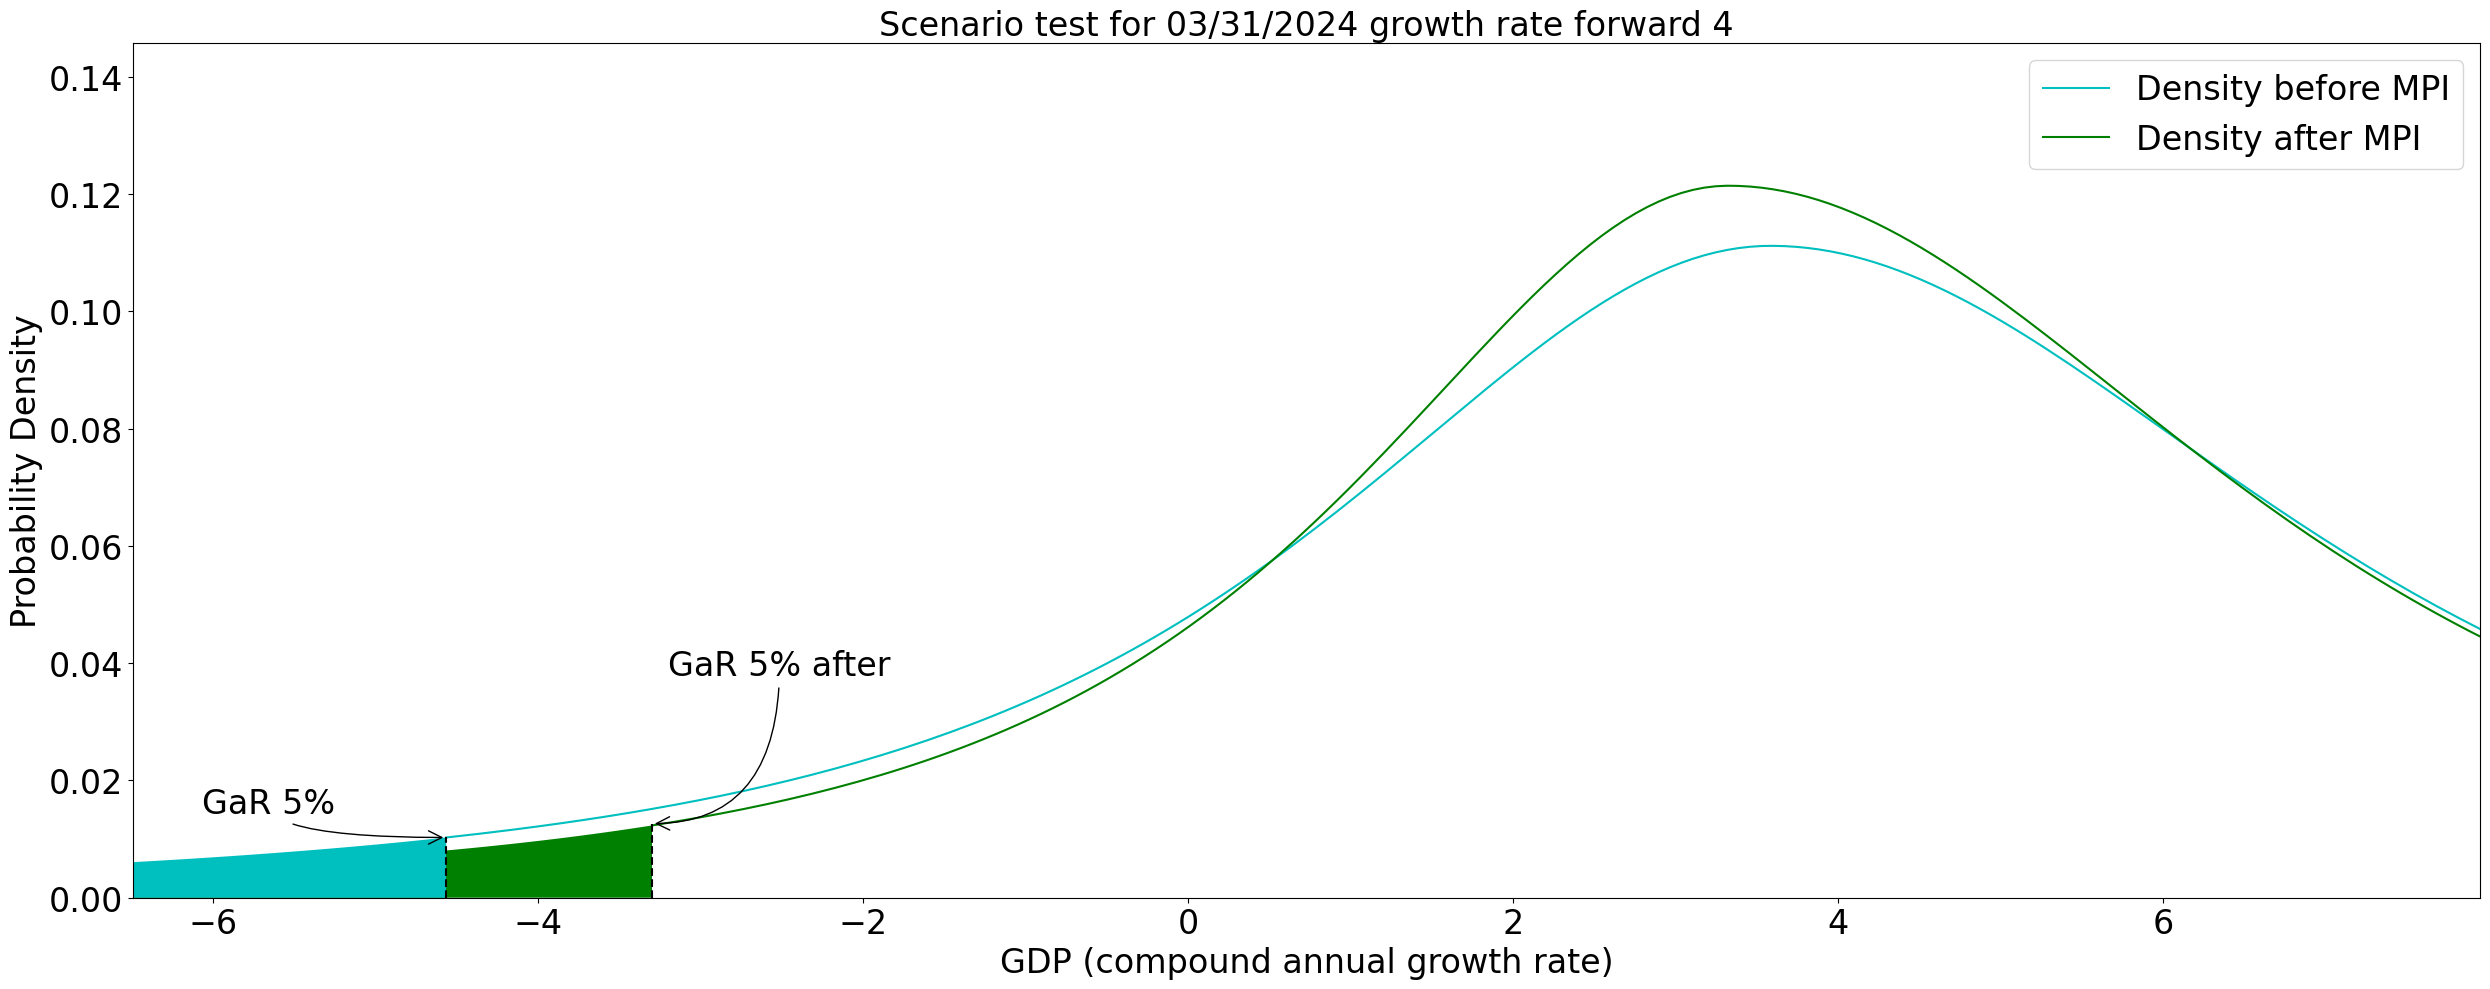

In [89]:
expectation = 'forward'
horizon = 4
plot_date = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock = 0.5
dist_index = (expectation, horizon, plot_date, method, policy_effect_type)

plot_cols = prediction_dfpdf.loc[dist_index].loc[[0, mpi_shock]].unstack(level=0).iloc[:, [0, 2, 3, 4, 5]]
x_list, yvals, yvals_shocked, ycdf, ycdf_shocked = plot_cols.values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q5_index_shock = np.argmin(np.abs(ycdf_shocked - 0.05))
q50_index = np.argmin(np.abs(ycdf - 0.5))
q50_index_shock = np.argmin(np.abs(ycdf_shocked - 0.5))
x_tail = np.min([x_list[q5_index], x_list[q5_index_shock]])
x_front = np.max([x_list[q50_index], x_list[q50_index_shock]])

fig, ax = plt.subplots(1, 1, figsize=(25, 10))
titlestr = "Scenario test for "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
lablestr = "Density before MPI"
lablestr_shocked = "Density after MPI"

ax.plot(x_list[q5_index-1:], yvals[q5_index-1:], 'c-', label=lablestr)
ax.plot(x_list[q5_index_shock-1:], yvals_shocked[q5_index_shock-1:], 'g-', label=lablestr_shocked)
if yvals[q5_index] > yvals_shocked[q5_index_shock]:
    ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='c', interpolate=True)
    ax.fill_between(x_list[:q5_index_shock], 0, yvals_shocked[:q5_index_shock],  facecolor='g', interpolate=True)
else:
    ax.fill_between(x_list[:q5_index_shock], 0, yvals_shocked[:q5_index_shock],  facecolor='g', interpolate=True)
    ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='c', interpolate=True)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(x_tail-2, x_front+4)
ax.set_ylim(0, max(max(yvals), max(yvals_shocked))*1.2)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)

# plot tails
xq5 = x_list[q5_index-1]
yq5 = yvals[q5_index-1]
xq5_shock = x_list[q5_index_shock-1]
yq5_shock = yvals_shocked[q5_index_shock]
ax.plot([xq5, xq5], [0, yq5], 'k--')
ax.annotate('GaR 5%', xy=(xq5, yq5), xycoords='data',
            xytext=(xq5-1.5, yq5*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
ax.plot([xq5_shock, xq5_shock], [0, yq5_shock], 'k--')
ax.annotate('GaR 5% after', xy=(xq5_shock, yq5_shock), xycoords='data',
            xytext=(xq5_shock+0.1, yq5_shock*3), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
# ax.legend([])
plt.tight_layout()
plt.savefig('../results/arm_qr_gdp_dist_MPI_direct_shock.png', bbox_inches='tight', dpi=300)
plt.show()

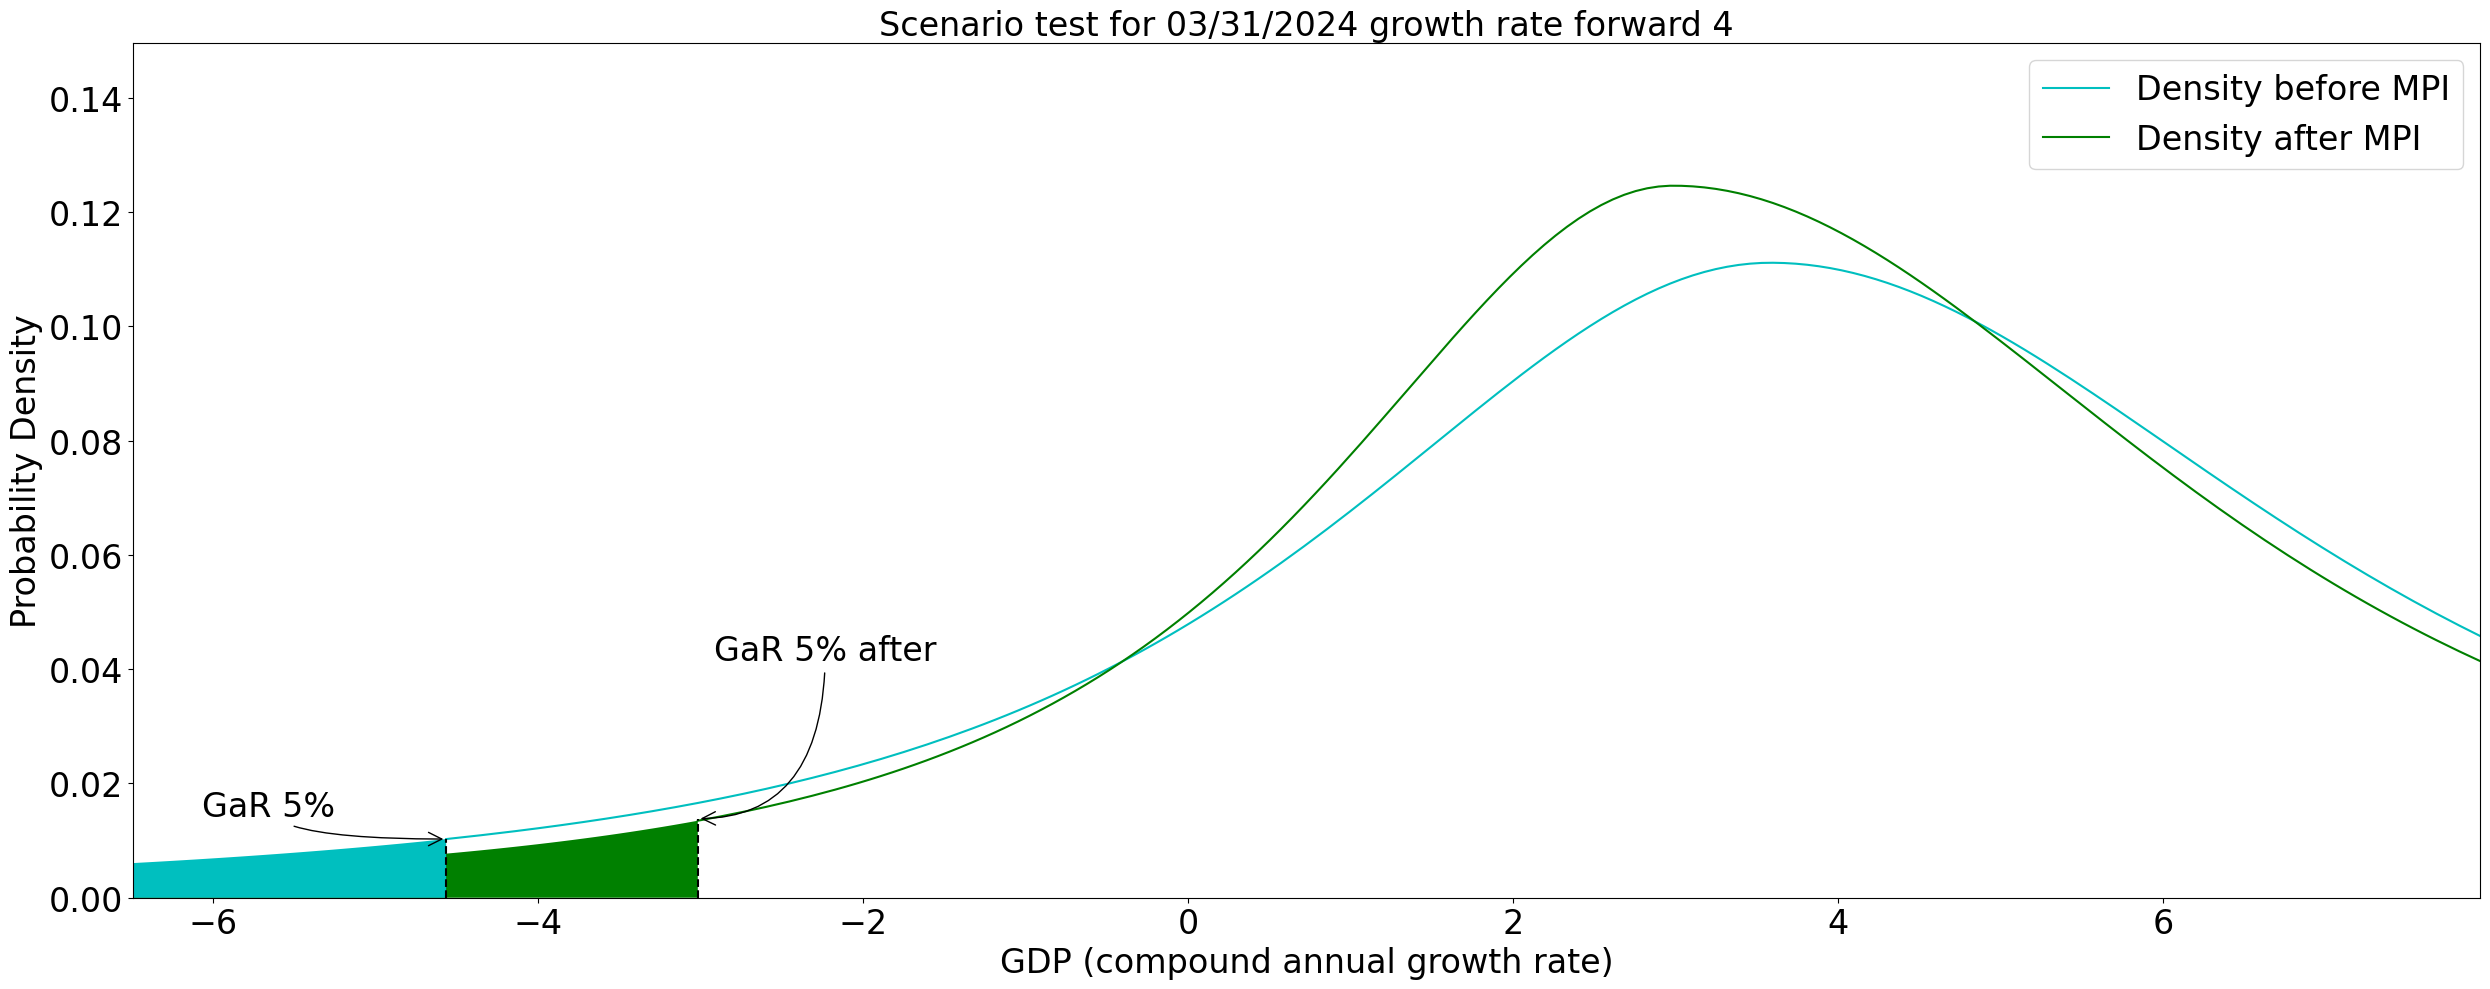

In [90]:
expectation = 'forward'
horizon = 4
plot_date = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'interaction'
mpi_shock = 0.5
dist_index = (expectation, horizon, plot_date, method, policy_effect_type)

plot_cols = prediction_dfpdf.loc[dist_index].loc[[0, mpi_shock]].unstack(level=0).iloc[:, [0, 2, 3, 4, 5]]
x_list, yvals, yvals_shocked, ycdf, ycdf_shocked = plot_cols.values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q5_index_shock = np.argmin(np.abs(ycdf_shocked - 0.05))
q50_index = np.argmin(np.abs(ycdf - 0.5))
q50_index_shock = np.argmin(np.abs(ycdf_shocked - 0.5))
x_tail = np.min([x_list[q5_index], x_list[q5_index_shock]])
x_front = np.max([x_list[q50_index], x_list[q50_index_shock]])

fig, ax = plt.subplots(1, 1, figsize=(25, 10))
titlestr = "Scenario test for "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate"+" forward "+str(horizon)
lablestr = "Density before MPI"
lablestr_shocked = "Density after MPI"

ax.plot(x_list[q5_index-1:], yvals[q5_index-1:], 'c-', label=lablestr)
ax.plot(x_list[q5_index_shock-1:], yvals_shocked[q5_index_shock-1:], 'g-', label=lablestr_shocked)
if yvals[q5_index] > yvals_shocked[q5_index_shock]:
    ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='c', interpolate=True)
    ax.fill_between(x_list[:q5_index_shock], 0, yvals_shocked[:q5_index_shock],  facecolor='g', interpolate=True)
else:
    ax.fill_between(x_list[:q5_index_shock], 0, yvals_shocked[:q5_index_shock],  facecolor='g', interpolate=True)
    ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='c', interpolate=True)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(x_tail-2, x_front+4)
ax.set_ylim(0, max(max(yvals), max(yvals_shocked))*1.2)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)

# plot tails
xq5 = x_list[q5_index-1]
yq5 = yvals[q5_index-1]
xq5_shock = x_list[q5_index_shock-1]
yq5_shock = yvals_shocked[q5_index_shock]
ax.plot([xq5, xq5], [0, yq5], 'k--')
ax.annotate('GaR 5%', xy=(xq5, yq5), xycoords='data',
            xytext=(xq5-1.5, yq5*1.4), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
ax.plot([xq5_shock, xq5_shock], [0, yq5_shock], 'k--')
ax.annotate('GaR 5% after', xy=(xq5_shock, yq5_shock), xycoords='data',
            xytext=(xq5_shock+0.1, yq5_shock*3), textcoords='data',
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="angle3,angleA=90,angleB=0"), fontsize=24)
# ax.legend([])
plt.tight_layout()
plt.savefig('../results/arm_qr_gdp_dist_MPI_interaction_shock.png', bbox_inches='tight', dpi=300)
plt.show()

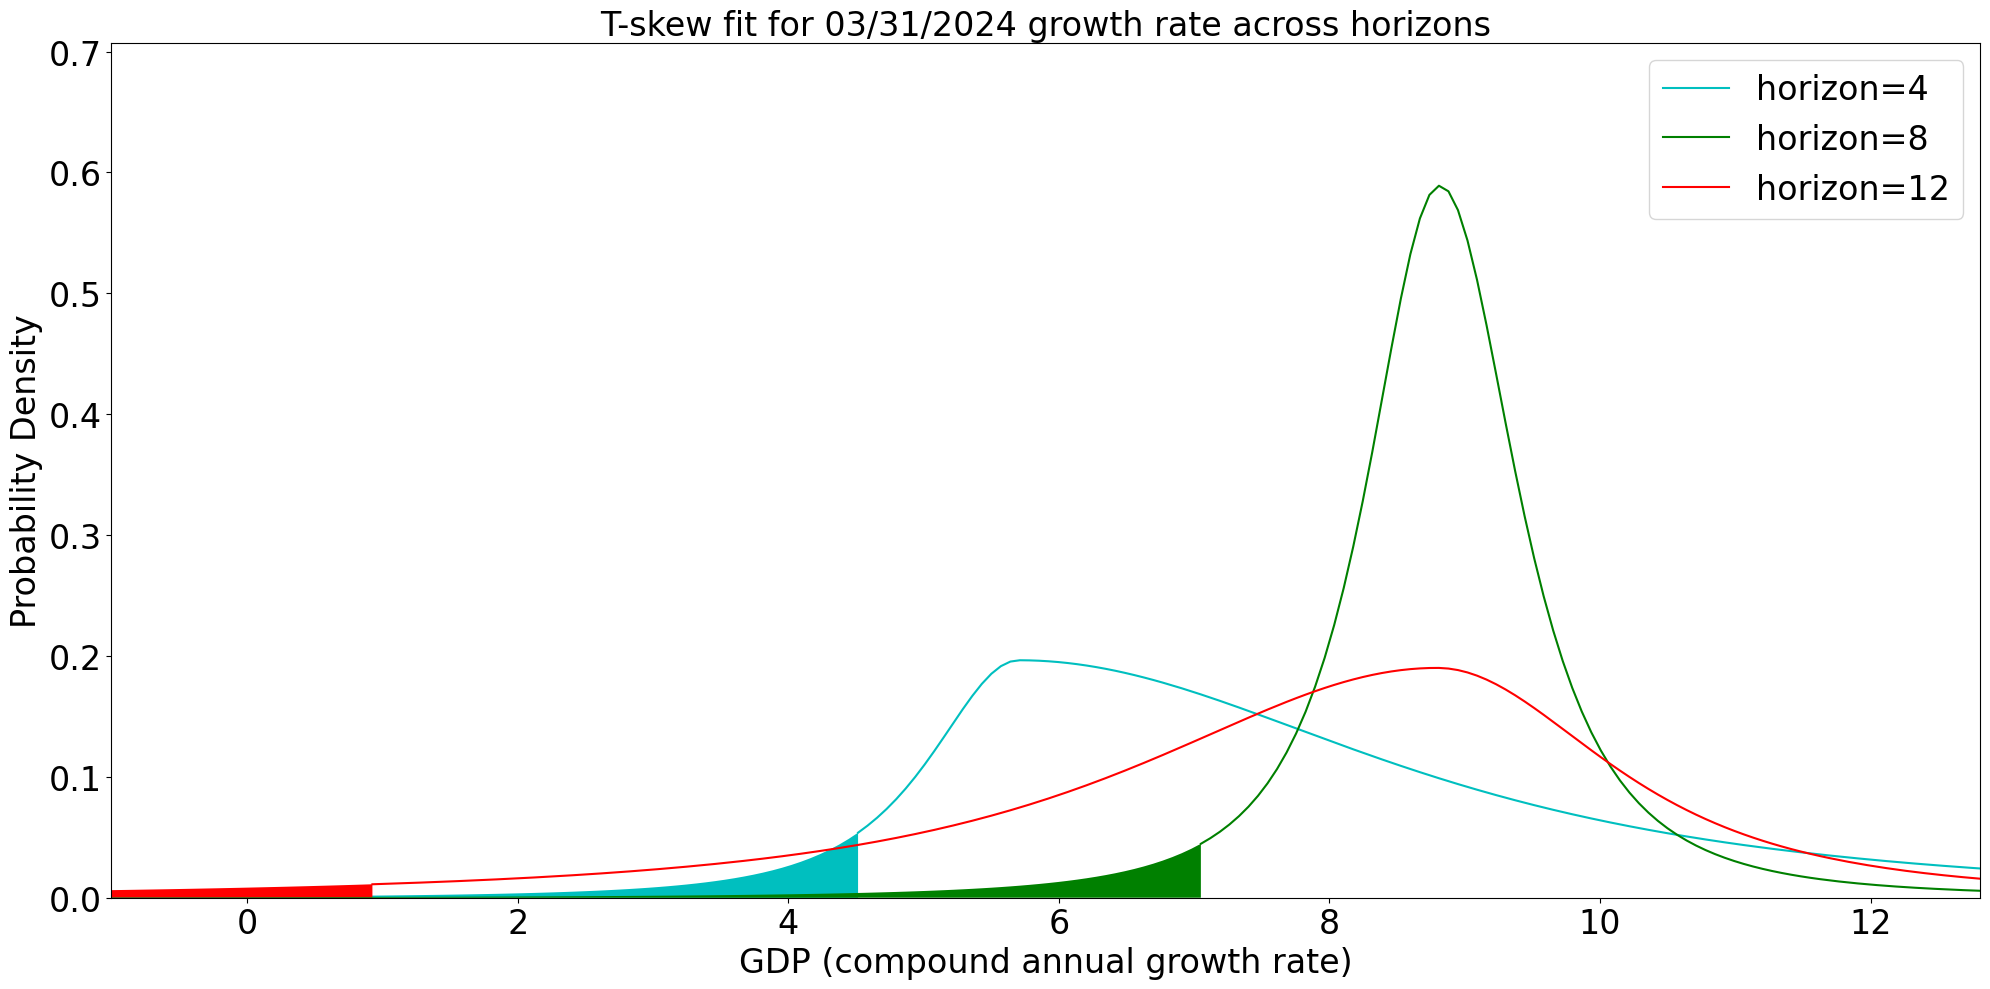

In [91]:
expectation = 'forward'
plot_date = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shocked = 0

dist_index_h4 = (expectation, 4, plot_date - pd.DateOffset(years=1), method, policy_effect_type, mpi_shocked)
dist_index_h8 = (expectation, 8, plot_date - pd.DateOffset(years=2), method, policy_effect_type, mpi_shocked)
dist_index_h12 = (expectation, 12, plot_date - pd.DateOffset(years=3), method, policy_effect_type, mpi_shocked)

x_list, yvals_h4, ycdf_h4 = prediction_dfpdf.loc[dist_index_h4].values.T
x_list, yvals_h8, ycdf_h8 = prediction_dfpdf.loc[dist_index_h8].values.T
x_list, yvals_h12, ycdf_h12 = prediction_dfpdf.loc[dist_index_h12].values.T

q5h4_index = np.argmin(np.abs(ycdf_h4 - 0.05))
q5h8_index = np.argmin(np.abs(ycdf_h8 - 0.05))
q5h12_index = np.argmin(np.abs(ycdf_h12 - 0.05))
q50h4_index = np.argmin(np.abs(ycdf_h4 - 0.5))
q50h8_index = np.argmin(np.abs(ycdf_h8 - 0.5))
q50h12_index = np.argmin(np.abs(ycdf_h12 - 0.5))
x_tail = np.min([x_list[q5h4_index], x_list[q5h8_index], x_list[q5h12_index]])
x_front = np.max([x_list[q50h4_index], x_list[q50h8_index], x_list[q50h12_index]])

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = f"{method} fit for "+plot_date.strftime('%m/%d/%Y')+" "+"growth rate across horizons"
hz = "horizon={h}".format

ax.plot(x_list[q5h4_index-1:], yvals_h4[q5h4_index-1:], 'c-', label=hz(h=4))
ax.plot(x_list[q5h8_index-1:], yvals_h8[q5h8_index-1:], 'g-', label=hz(h=8))
ax.plot(x_list[q5h12_index-1:], yvals_h12[q5h12_index-1:], 'r-', label=hz(h=12))

ax.fill_between(x_list[:q5h4_index], 0, yvals_h4[:q5h4_index],  facecolor='c', interpolate=True)
ax.fill_between(x_list[:q5h12_index], 0, yvals_h12[:q5h12_index],  facecolor='r', interpolate=True)
ax.fill_between(x_list[:q5h8_index], 0, yvals_h8[:q5h8_index],  facecolor='g', interpolate=True)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(x_tail-2, x_front+4)
ax.set_ylim(0, max(max(yvals_h4), max(yvals_h8), max(yvals_h12))*1.2)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)

plt.tight_layout()
plt.savefig('../results/arm_qr_pred_dist_horizons.png', bbox_inches='tight', dpi=300)
plt.show()

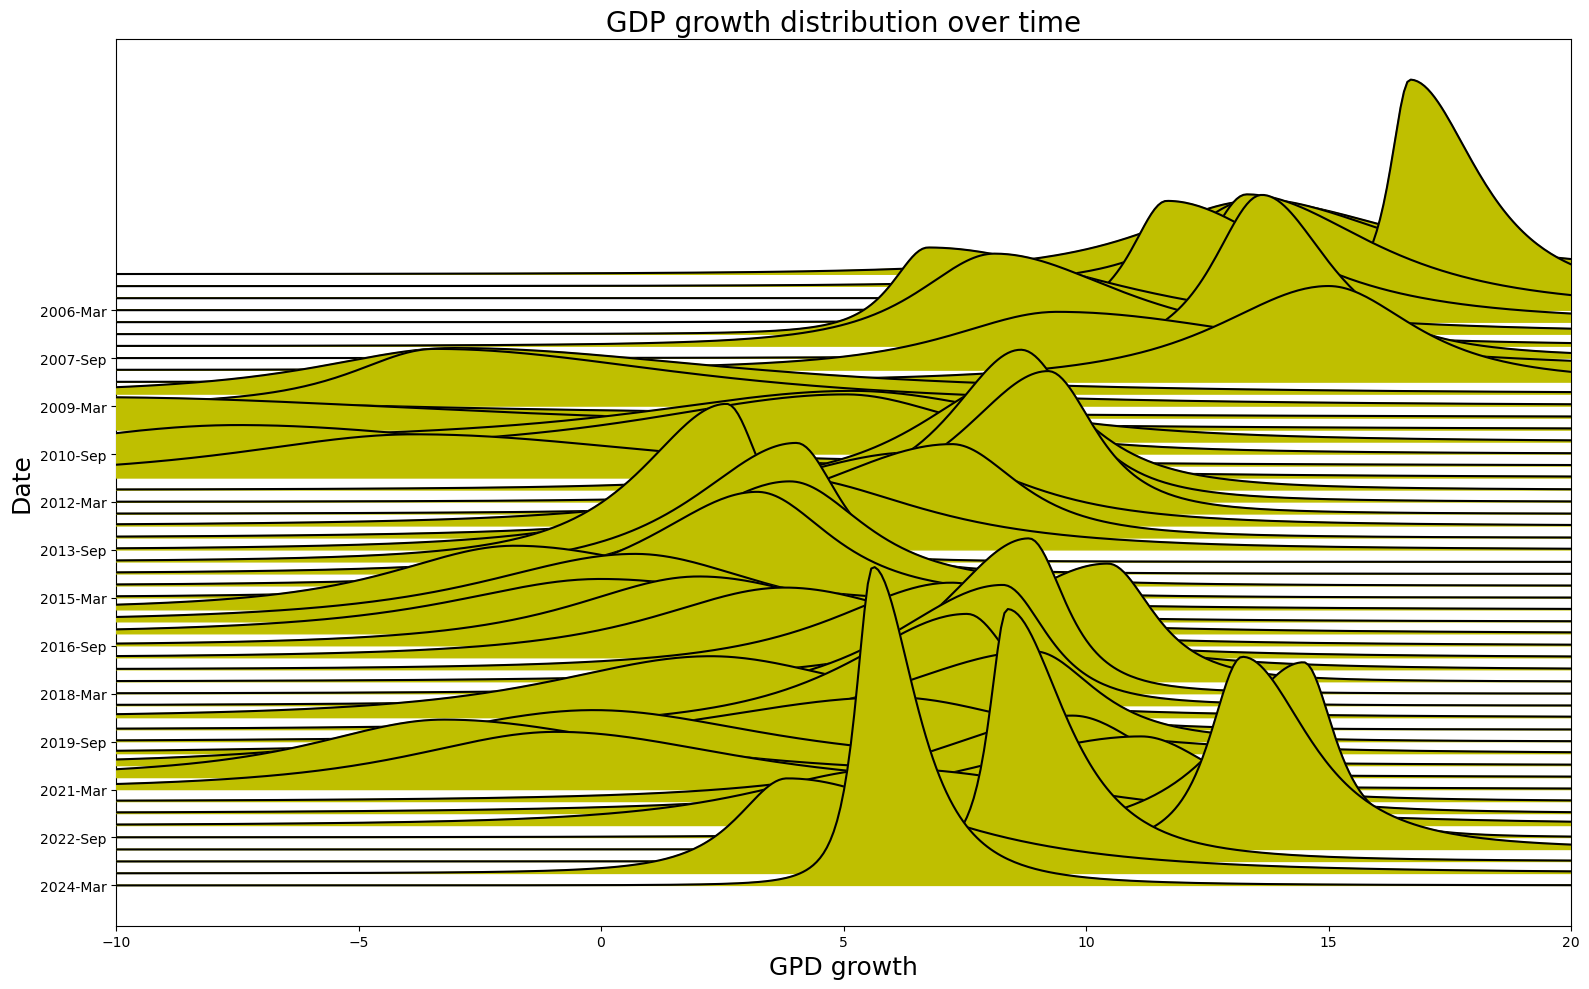

In [92]:
# data setup
expectation = 'backward'
horizon = 4
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock = 0
dist_index = (expectation, horizon, method, policy_effect_type, mpi_shock)

plot_data = prediction_dfpdf.reorder_levels([0, 1, 3, 4, 5, 2, 6]).sort_index().loc[dist_index]
plot_data = plot_data.reset_index('index', drop=True)

# plotting
plt.figure(figsize=(16, 10))
ridgeline_custom(plot_data['PDF_x'], plot_data['PDF_y'], overlap=0.98, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4,
                 dist_density=3, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.xlim(-10, 20)
plt.tight_layout()
plt.savefig('../results/arm_qr_gdp_dist_ridge.png', bbox_inches='tight', dpi=300)
plt.show()

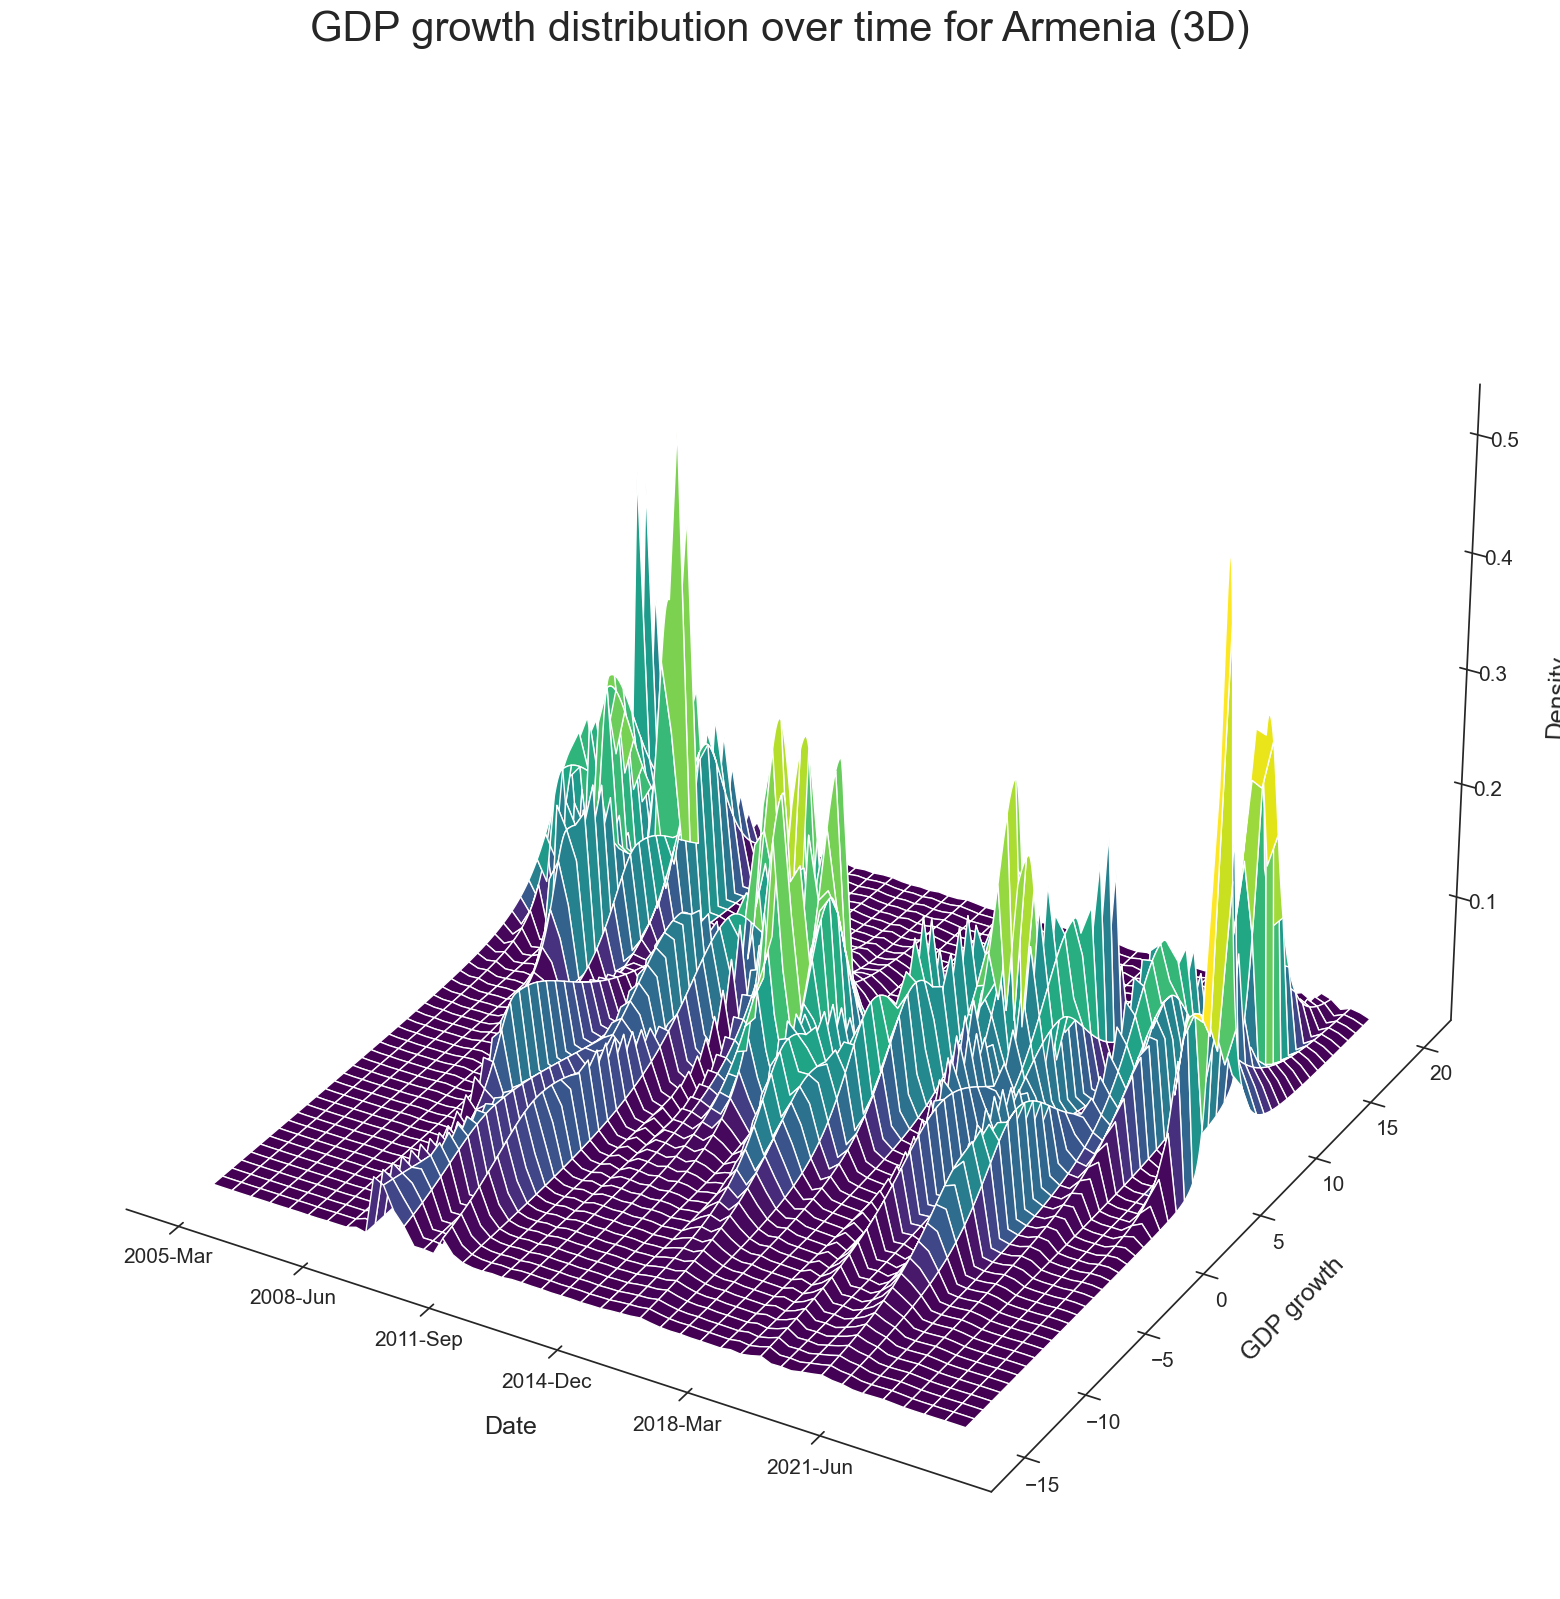

In [93]:
# custom outline
sns.set_theme(style="white", palette='viridis')

# Data preparation
gdp_growth = plot_data['PDF_x'].groupby('date').apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = plot_data['PDF_y'].groupby('date').apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis,
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'))
ax.set_xlabel('Date', fontsize=18, labelpad=20)
ax.set_ylabel('GDP growth', fontsize=18, labelpad=20)
ax.set_zlabel('Density', fontsize=18, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('GDP growth distribution over time for Armenia (3D)', fontsize=30)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
ax.yaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
ax.zaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
plt.savefig('../results/GDP_growth_dist_3D_for_Armenia.png', bbox_inches='tight', dpi=300)
plt.show()

# Possibility curve

In [20]:
def suarez_utility(m, g, w):
    u = m - 0.5*w*(g**2)
    u.name = 'Utility'
    return u


def suarez_indifference_curve(g, w, u):
    return u.squeeze()+w*g**2/2

In [21]:
# loading data
prediction = pd.read_pickle('../data/working_data/arm_prediction.pkl')

In [22]:
# setup
suarez_weights = np.linspace(0.01, 0.2, 50).round(4)
q_names = {0.1: 'GaR', 0.5: 'GDPq50'}
w_fixed = suarez_weights[2]

# estimation
growth_possibilities = prediction.unstack('quantile').rename(columns=q_names)[q_names.values()]
growth_possibilities['Gap'] = (growth_possibilities['GDPq50'] - growth_possibilities['GaR']).clip(0)
growth_possibilities = growth_possibilities.drop(columns='GaR')
growth_possibilities_today = growth_possibilities.loc['forward', 4, '2024-03-31']

# calculating utility
growth_options = []
for w in suarez_weights:
    gp = growth_possibilities.copy()
    gp['Utility'] = suarez_utility(gp['GDPq50'], gp['Gap'], w)
    gp['w'] = w
    gp.set_index('w', append=True, inplace=True)
    growth_options.append(gp)
growth_options = pd.concat(growth_options)
growth_options = growth_options.reorder_levels(growth_options.index.names[:-2] + growth_options.index.names[:-3:-1])
growth_options = growth_options.sort_index()

# utility choice set
growth_welfare = growth_options['Utility'].unstack(['expectation', 'horizon']).copy()

# possibility line comparison
possibility_line = growth_possibilities.unstack('horizon')
possibility_line_bd = possibility_line.loc['backward', '2024-03-31', 'direct']
possibility_line_fd = possibility_line.loc['forward', '2024-03-31', 'direct']
possibility_line_bi = possibility_line.loc['backward', '2024-03-31', 'interaction']
possibility_line_fi = possibility_line.loc['forward', '2024-03-31', 'interaction']

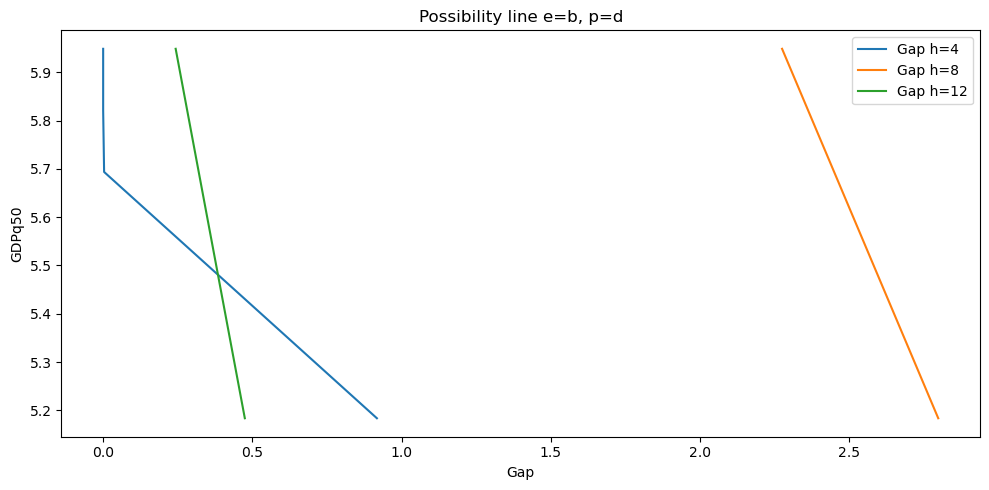

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
possibility_line_bd.loc[:, [('GDPq50', 4), ('Gap', 4)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_bd.loc[:, [('GDPq50', 4), ('Gap', 8)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_bd.loc[:, [('GDPq50', 4), ('Gap', 12)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
ax.set_ylabel('GDPq50')
ax.legend(['Gap h=4', 'Gap h=8', 'Gap h=12'])
ax.set_title('Possibility line e=b, p=d')
plt.tight_layout()
plt.show()

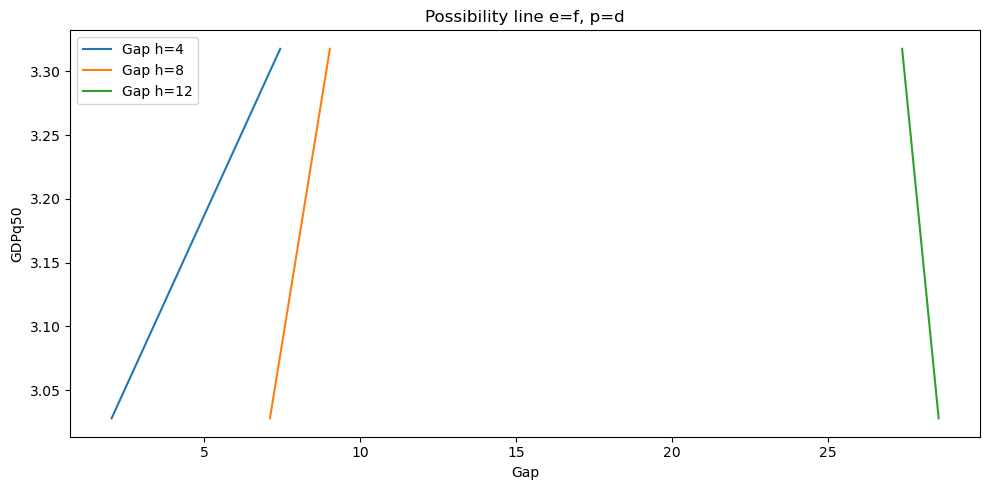

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
possibility_line_fd.loc[:, [('GDPq50', 4), ('Gap', 4)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_fd.loc[:, [('GDPq50', 4), ('Gap', 8)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_fd.loc[:, [('GDPq50', 4), ('Gap', 12)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
ax.set_ylabel('GDPq50')
ax.legend(['Gap h=4', 'Gap h=8', 'Gap h=12'])
ax.set_title('Possibility line e=f, p=d')
plt.tight_layout()
plt.show()

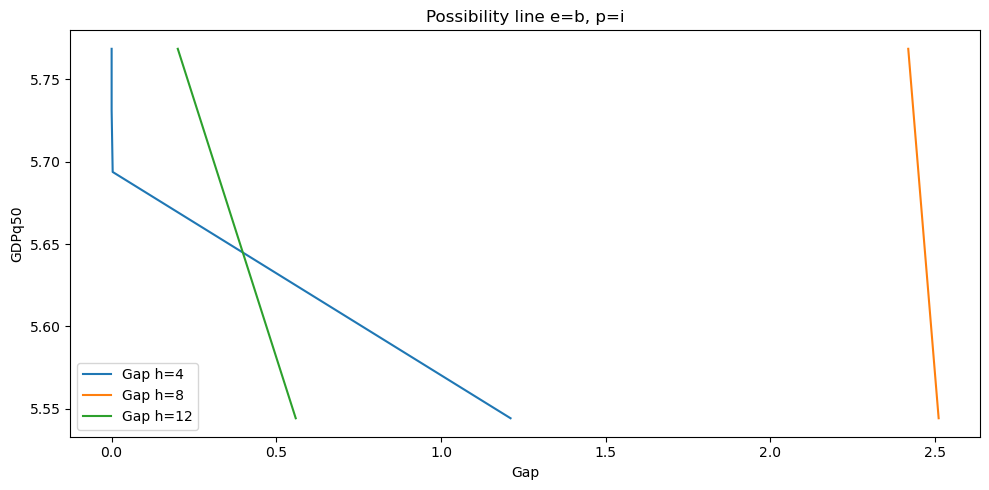

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
possibility_line_bi.loc[:, [('GDPq50', 4), ('Gap', 4)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_bi.loc[:, [('GDPq50', 4), ('Gap', 8)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_bi.loc[:, [('GDPq50', 4), ('Gap', 12)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
ax.set_ylabel('GDPq50')
ax.legend(['Gap h=4', 'Gap h=8', 'Gap h=12'])
ax.set_title('Possibility line e=b, p=i')
plt.tight_layout()
plt.show()

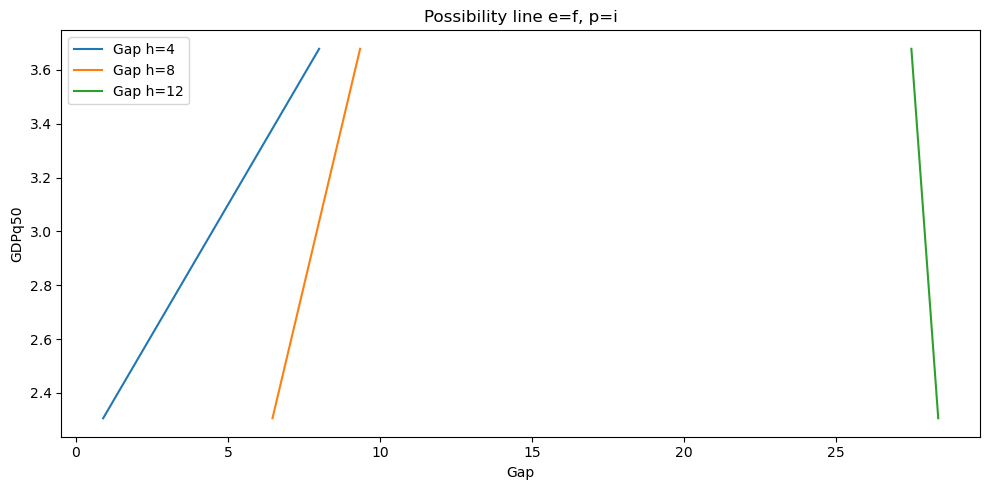

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
possibility_line_fi.loc[:, [('GDPq50', 4), ('Gap', 4)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_fi.loc[:, [('GDPq50', 4), ('Gap', 8)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
possibility_line_fi.loc[:, [('GDPq50', 4), ('Gap', 12)]].droplevel('horizon', axis=1).set_index('Gap').plot(ax=ax)
ax.set_ylabel('GDPq50')
ax.legend(['Gap h=4', 'Gap h=8', 'Gap h=12'])
ax.set_title('Possibility line e=f, p=i')
plt.tight_layout()
plt.show()

# Optimal policy

In [27]:
# theme setup and data loading
sns.set_theme(style='white')
arm_qcoef_norm = pd.read_pickle('../data/working_data/arm_qcoef_norm.pkl')
gdp_dist_details = pd.read_pickle('../data/working_data/arm_gdp_dist_details.pkl')
prediction_dfpdf = pd.read_pickle('../data/working_data/arm_prediction_dfpdf.pkl')
exog = pd.read_pickle('../data/working_data/arm_exog.pkl')

In [28]:
# deriving mpi choices
# u_cols = [('backward', 4), ('backward', 8), ('backward', 12), 
#           ('forward', 4), ('forward', 8), ('forward', 12)]
# u_cols = [('backward', 4), ('forward', 4), ('forward', 8), ('forward', 12)]
u_cols = [('forward', 4)]
mpi_choices = growth_welfare[u_cols].mean(axis=1)
mpi_choices.name = 'Utility'
u_opt = mpi_choices.reset_index(mpi_choices.index.names[:-1]).groupby(mpi_choices.index.names[:-1]).max()
u_opt_today = u_opt.loc['2024-03-31'].xs(w_fixed, level='w')
mpi_choices.name = 'MPI'
mpi_choices = mpi_choices.reset_index(mpi_choices.index.names[:-1]).groupby(mpi_choices.index.names[:-1]).idxmax()
mpi_choice_today = mpi_choices.loc['2024-03-31'].squeeze()

In [29]:
# deriving indifference curve
w_fixed = suarez_weights[2]
gpt = growth_possibilities_today.copy().groupby('policy_effect_type', group_keys=False)
ic_values = gpt.apply(lambda x: suarez_indifference_curve(x['Gap'], w_fixed, u_opt_today.loc[x.index[0][0]])).values
growth_possibilities_today.loc[:, 'GDPq50_IC'] = ic_values

# estimating other indifference curves
u_range = 0.3
indifference_curves = growth_possibilities_today[['Gap']].copy()
visible_Us = np.linspace(u_opt_today.loc['direct'].item()-u_range, u_opt_today.loc['direct'].item()+u_range, 5).round(2)
for u in visible_Us:
    indifference_curves[f'GDPq50_{u}'] = gpt.apply(lambda x: suarez_indifference_curve(x['Gap'], w_fixed, u)).values

/var/folders/7z/4b2s0xm51xqdf1pg3f_vwj180000gp/T/ipykernel_1586/1692593257.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  growth_possibilities_today.loc[:, 'GDPq50_IC'] = ic_values


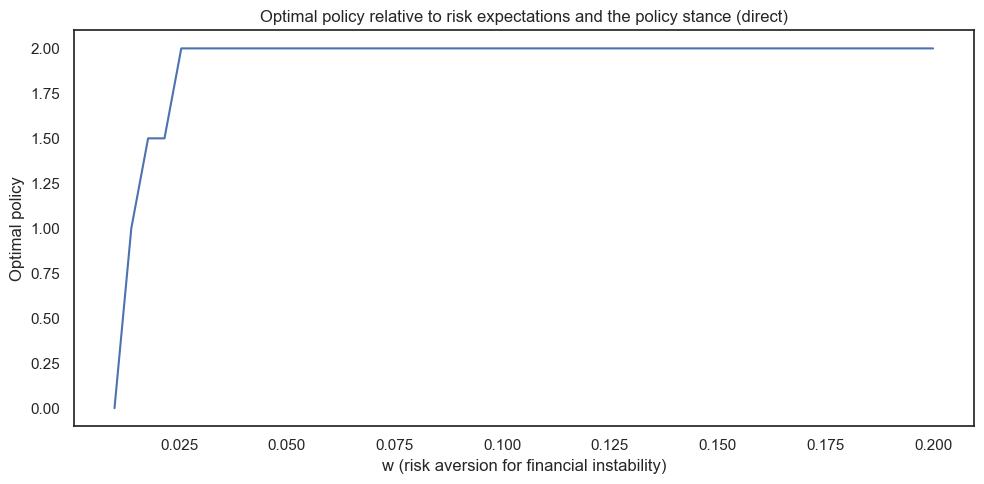

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mpi_choice_today.loc['direct'].plot(ax=ax)
ax.set_title('Optimal policy relative to risk expectations and the policy stance (direct)')
ax.set_ylabel('Optimal policy')
ax.set_xlabel('w (risk aversion for financial instability)')
plt.tight_layout()
plt.savefig('../results/arm_risk_aversion_direct.png', bbox_inches='tight', dpi=300)
plt.show()

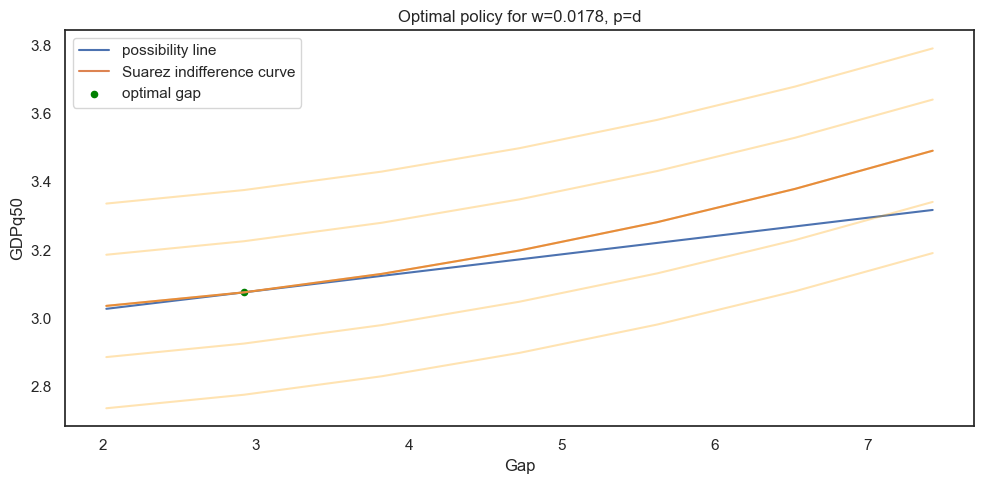

In [31]:
s_opt_today = mpi_choice_today.loc['direct', w_fixed]
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
growth_possibilities_today.loc['direct'].plot(x='Gap', y='GDPq50', ax=ax)
growth_possibilities_today.loc['direct'].plot(x='Gap', y='GDPq50_IC', ax=ax)
growth_possibilities_today.loc[[('direct', s_opt_today)]].plot(x='Gap', y='GDPq50', kind='scatter', color='green', ax=ax)
indifference_curves.loc['direct'].set_index('Gap').plot(ax=ax, alpha=0.3, color='orange')
ax.set_ylabel('GDPq50')
ax.legend(['possibility line', 'Suarez indifference curve', 'optimal gap'])
ax.set_title(f'Optimal policy for w={w_fixed}, p=d')
plt.tight_layout()
plt.savefig('../results/arm_possibility_line_direct.png', bbox_inches='tight', dpi=300)
plt.show()

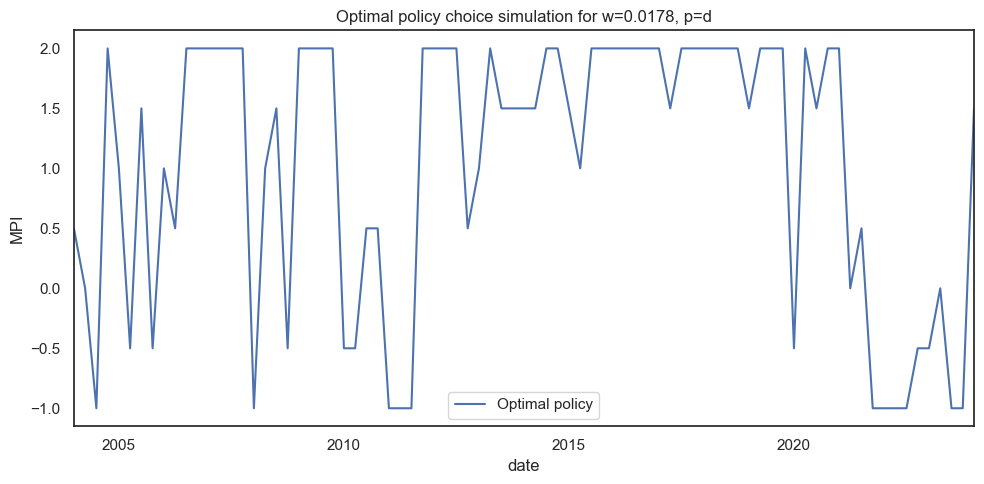

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mpi_choices.xs('direct', level='policy_effect_type').xs(w_fixed, level='w').plot(ax=ax)
ax.set_ylabel('MPI')
ax.legend(['Optimal policy'])
ax.set_title(f'Optimal policy choice simulation for w={w_fixed}, p=d')
plt.tight_layout()
plt.savefig('../results/arm_policy_simulation_direct.png', bbox_inches='tight', dpi=300)
plt.show()

In [33]:
# # deriving indifference curve
# w_fixed = suarez_weights[10]
# eff_type = 'interaction'

# gpt = growth_possibilities_today.copy().groupby('policy_effect_type', group_keys=False)
# ic_values = gpt.apply(lambda x: suarez_indifference_curve(x['Gap'], w_fixed, u_opt_today.loc[x.index[0][0]])).values
# growth_possibilities_today.loc[:, 'GDPq50_IC'] = ic_values

# # estimating other indifference curves
# u_range = 0.3
# indifference_curves = growth_possibilities_today[['Gap']].copy()
# visible_Us = np.linspace(u_opt_today.loc[eff_type].item()-u_range, u_opt_today.loc[eff_type].item()+u_range, 5).round(2)
# for u in visible_Us:
#     indifference_curves[f'GDPq50_{u}'] = gpt.apply(lambda x: suarez_indifference_curve(x['Gap'], w_fixed, u)).values

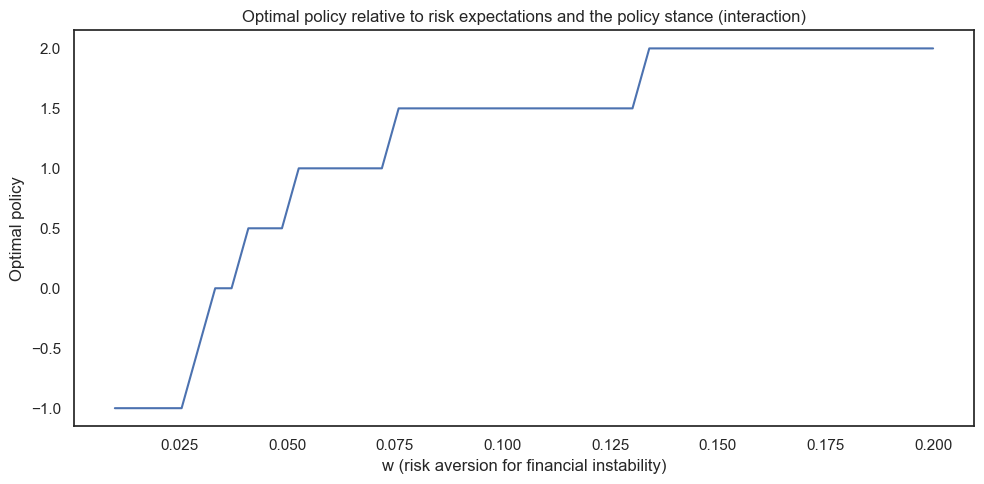

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mpi_choice_today.loc['interaction'].plot(ax=ax)
ax.set_title('Optimal policy relative to risk expectations and the policy stance (interaction)')
ax.set_ylabel('Optimal policy')
ax.set_xlabel('w (risk aversion for financial instability)')
plt.tight_layout()
plt.savefig('../results/arm_risk_aversion_interaction.png', bbox_inches='tight', dpi=300)
plt.show()

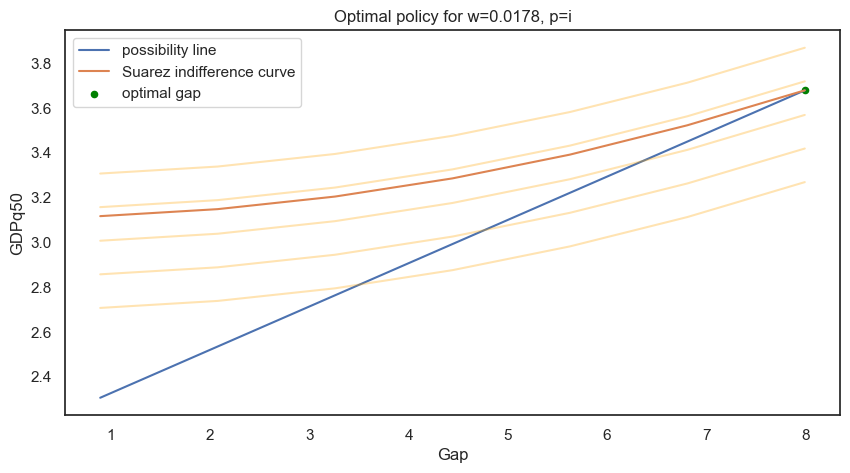

In [35]:
s_opt_today = mpi_choice_today.loc['interaction', w_fixed]
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
growth_possibilities_today.loc['interaction'].plot(x='Gap', y='GDPq50', ax=ax)
growth_possibilities_today.loc['interaction'].plot(x='Gap', y='GDPq50_IC', ax=ax)
growth_possibilities_today.loc[[('interaction', s_opt_today)]].plot(x='Gap', y='GDPq50', kind='scatter', color='green', ax=ax)
indifference_curves.loc['interaction'].set_index('Gap').plot(ax=ax, alpha=0.3, color='orange')
ax.set_ylabel('GDPq50')
ax.legend(['possibility line', 'Suarez indifference curve', 'optimal gap'])
ax.set_title(f'Optimal policy for w={w_fixed}, p=i')
plt.tight_layout
plt.savefig('../results/arm_possibility_line_interaction.png', bbox_inches='tight', dpi=300)
plt.show()

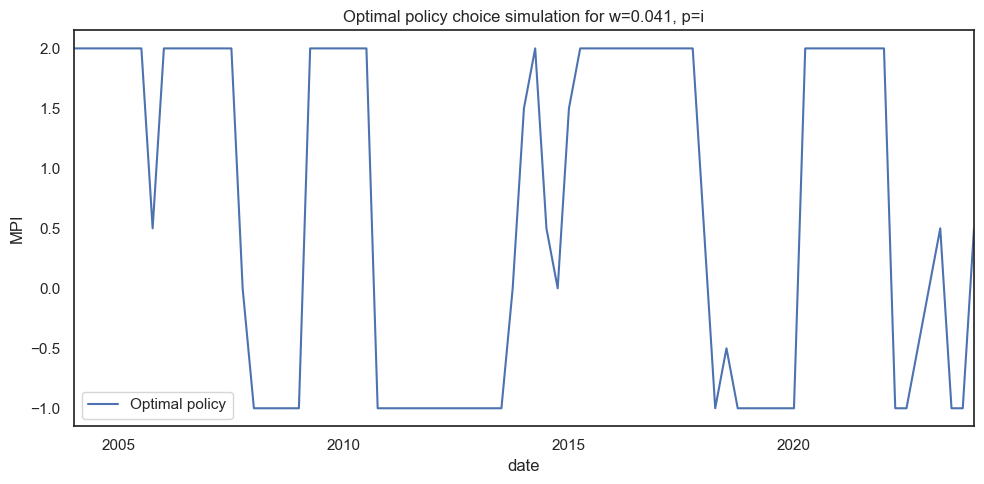

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
w_fixed = suarez_weights[8]
mpi_choices.xs('interaction', level='policy_effect_type').xs(w_fixed, level='w').plot(ax=ax)
ax.set_ylabel('MPI')
ax.legend(['Optimal policy'])
ax.set_title(f'Optimal policy choice simulation for w={w_fixed}, p=i')
plt.tight_layout()
plt.savefig('../results/arm_policy_simulation_interaction.png', bbox_inches='tight', dpi=300)
plt.show()

In [37]:
variable_effects = gdp_dist_details.xs('direct', level='policy_effect_type').xs(0, level='MPI_shock')
variable_effects = variable_effects.reorder_levels(variable_effects.index.names[:-2] + variable_effects.index.names[:-3:-1])
variable_effects = variable_effects.sort_index()
variable_effects_older = variable_effects.xs('2022-03-31', level='date')
variable_effects_old = variable_effects.xs('2023-03-31', level='date')
variable_effects_today = variable_effects.xs('2024-03-31', level='date')
variable_effects_dold = variable_effects_old - variable_effects_older
variable_effects_dold.sort_index()
variable_effects_diff = variable_effects_today - variable_effects_old
variable_effects_diff = variable_effects_diff.sort_index()

In [38]:
fin_vars = [
    'FCI x FCyI', 'Financial Conditions Index', 'Financial Cycle Index',
    'MPI', 'MPI x FCI', 'MPI x FCyI'
]
variable_effects_dold['agg_by_sector'] = variable_effects_dold.index.get_level_values('variable').isin(fin_vars)
variable_effects_dold['agg_by_sector'] = variable_effects_dold['agg_by_sector'].replace({False: 'Macro', True: 'Financial'})
autoreg = variable_effects_dold.index.get_level_values('variable') == 'autoregressive'
variable_effects_dold.loc[autoreg, 'agg_by_sector'] = 'autoregressive'
variable_effects_dold = variable_effects_dold.sort_index()
variable_effects_dold_agg = variable_effects_dold.groupby(['expectation', 'horizon', 'quantile', 'agg_by_sector'])['pred'].sum()

In [39]:
variable_effects_diff['agg_by_sector'] = variable_effects_diff.index.get_level_values('variable').isin(fin_vars)
variable_effects_diff['agg_by_sector'] = variable_effects_diff['agg_by_sector'].replace({False: 'Macro', True: 'Financial'})
autoreg = variable_effects_diff.index.get_level_values('variable') == 'autoregressive'
variable_effects_diff.loc[autoreg, 'agg_by_sector'] = 'autoregressive'
variable_effects_diff = variable_effects_diff.sort_index()
variable_effects_diff_agg = variable_effects_diff.groupby(['expectation', 'horizon', 'quantile', 'agg_by_sector'])['pred'].sum()

In [40]:
# actual column names
# 'Financial Cycle Index'
# 'Financial Conditions Index':
# 'MPI'

# 'CPI'
# 'Exchange rate_lag_4'
# 'Trade balance'
# 'Copper prices_lag_4_log'
# 'Real estate prices_lag_1_log'

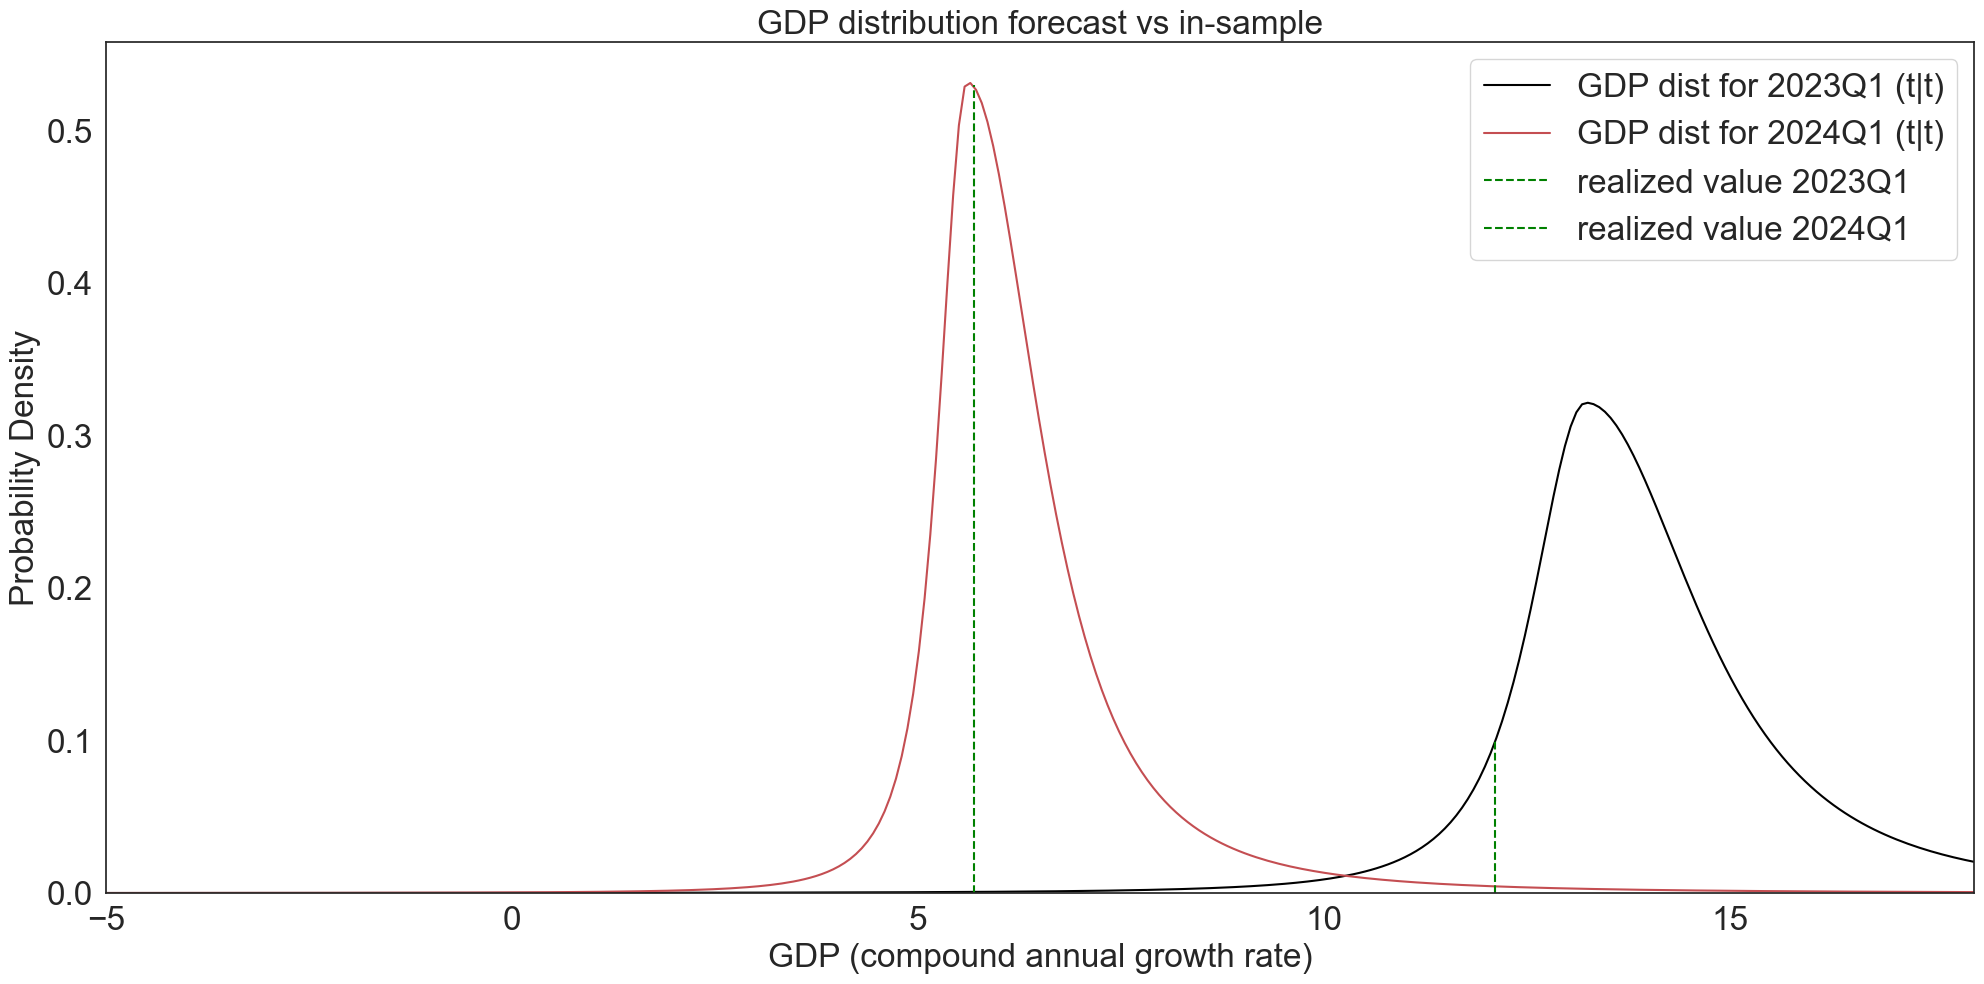

In [41]:
expectation = 'forward'
horizon = 4
plot_date_today = parser.parse('2023-03-31')
plot_date_tomorrow = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock_passive = 0
actual_old = prediction.loc['backward', 4, plot_date_today, 'direct', 0, 'actual']
actual_today = prediction.loc['backward', 4, plot_date_tomorrow, 'direct', 0, 'actual']

dist_index_today_b_old = ('backward', horizon, plot_date_today, method, policy_effect_type, mpi_shock_passive)
dist_index_today_b = ('backward', horizon, plot_date_tomorrow, method, policy_effect_type, mpi_shock_passive)

x_list_today_f, yvals_today_f, ycdf_today_f = prediction_dfpdf.loc[dist_index_today_b_old].values.T
x_list_today_b, yvals_today_b, ycdf_today_b = prediction_dfpdf.loc[dist_index_today_b].values.T

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = "GDP distribution forecast vs in-sample"
lablestr_today_f = "GDP dist for 2023Q1 (t|t)"
lablestr_today_b = "GDP dist for 2024Q1 (t|t)"

ax.plot(x_list_today_f, yvals_today_f, 'black', label=lablestr_today_f)
ax.plot(x_list_today_b, yvals_today_b, 'r-', label=lablestr_today_b)
ax.axvline(x=actual_old, ymax=0.18, color='green', linestyle='--', label='realized value 2023Q1')
ax.axvline(x=actual_today, ymax=0.95, color='green', linestyle='--', label='realized value 2024Q1')

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(-5, 18)
ax.set_ylim(0, max(max(yvals_today_f), max(yvals_today_b))*1.05)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)
plt.tight_layout()
plt.savefig('../results/arm_dist_changes_2024Q1.png', bbox_inches='tight', dpi=300)
plt.show()

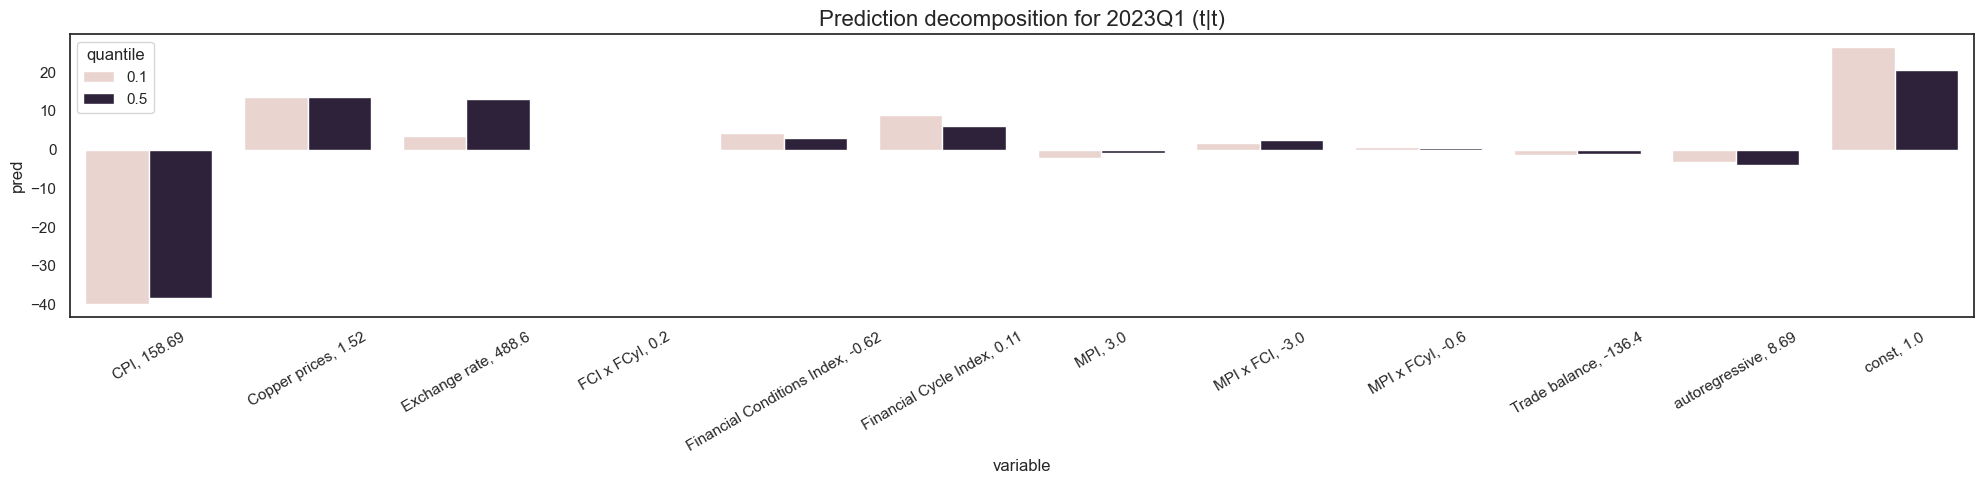

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
titlestr = "Prediction decomposition for 2023Q1 (t|t)"
plot_data = variable_effects_old.loc['backward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_2023Q1(t|t).png', bbox_inches='tight', dpi=300)
plt.show()

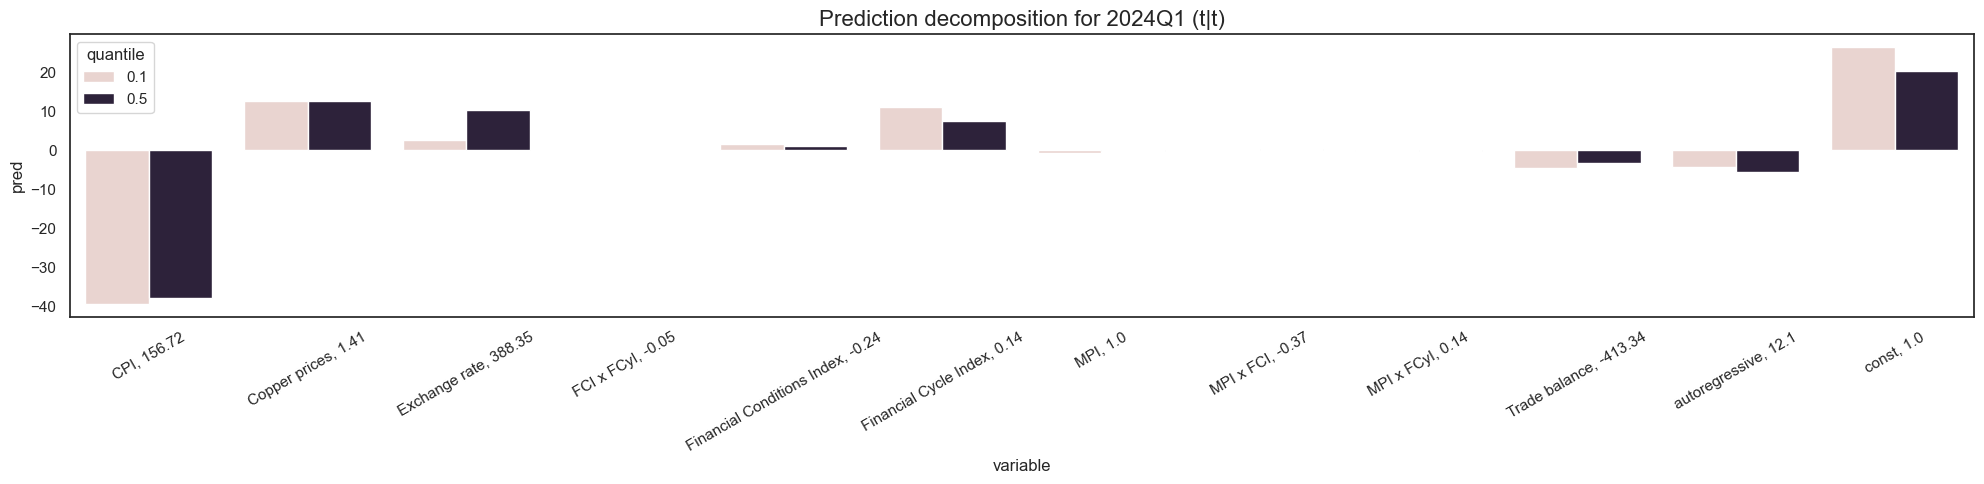

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
titlestr = "Prediction decomposition for 2024Q1 (t|t)"
plot_data = variable_effects_today.loc['backward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_2024Q1(t|t).png', bbox_inches='tight', dpi=300)
plt.show()

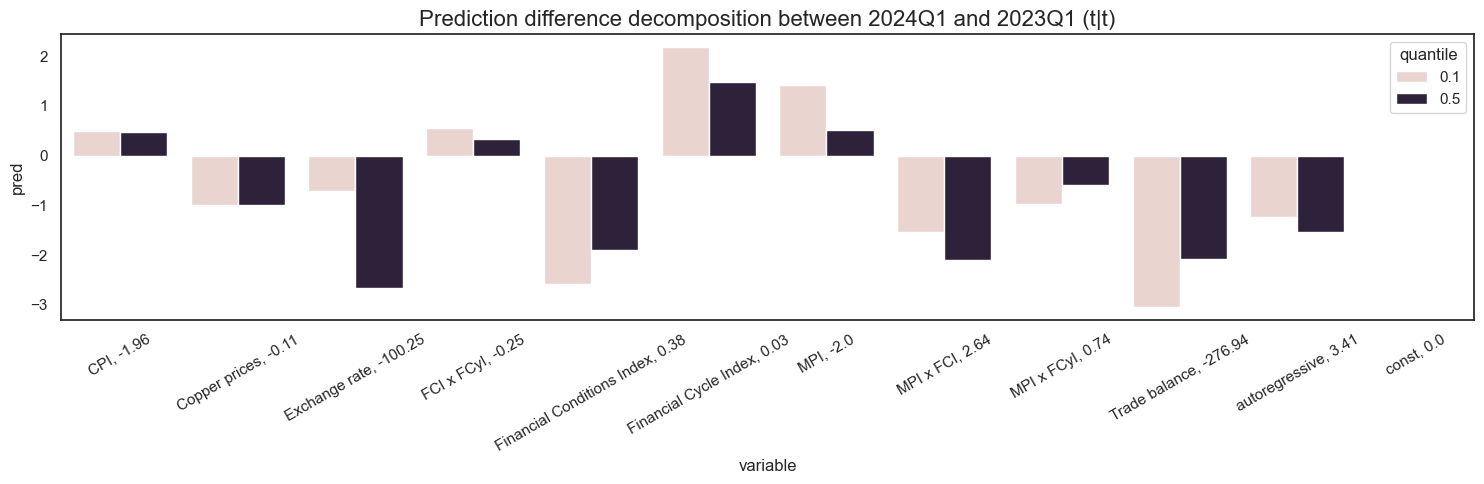

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
titlestr = "Prediction difference decomposition between 2024Q1 and 2023Q1 (t|t)"
plot_data = variable_effects_diff.loc['backward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_diff_2024Q1(t|t).png', bbox_inches='tight', dpi=300)
plt.show()

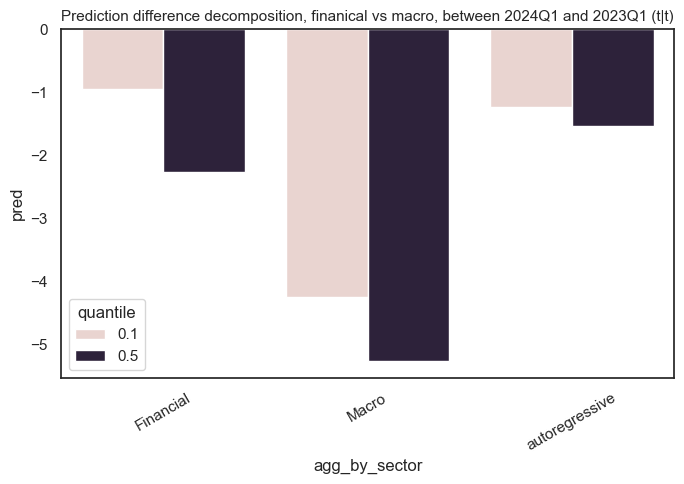

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
titlestr = "Prediction difference decomposition, finanical vs macro, between 2024Q1 and 2023Q1 (t|t)"
plot_data = variable_effects_diff_agg.loc['backward', 4].loc[[0.1, 0.5]].copy()
plot_data = plot_data.reset_index()
ax.set_title(titlestr, fontsize=11)
sns.barplot(plot_data, x="agg_by_sector", y="pred", hue='quantile', errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_diff_agg_2024Q1(t|t).png', bbox_inches='tight', dpi=300)
plt.show()

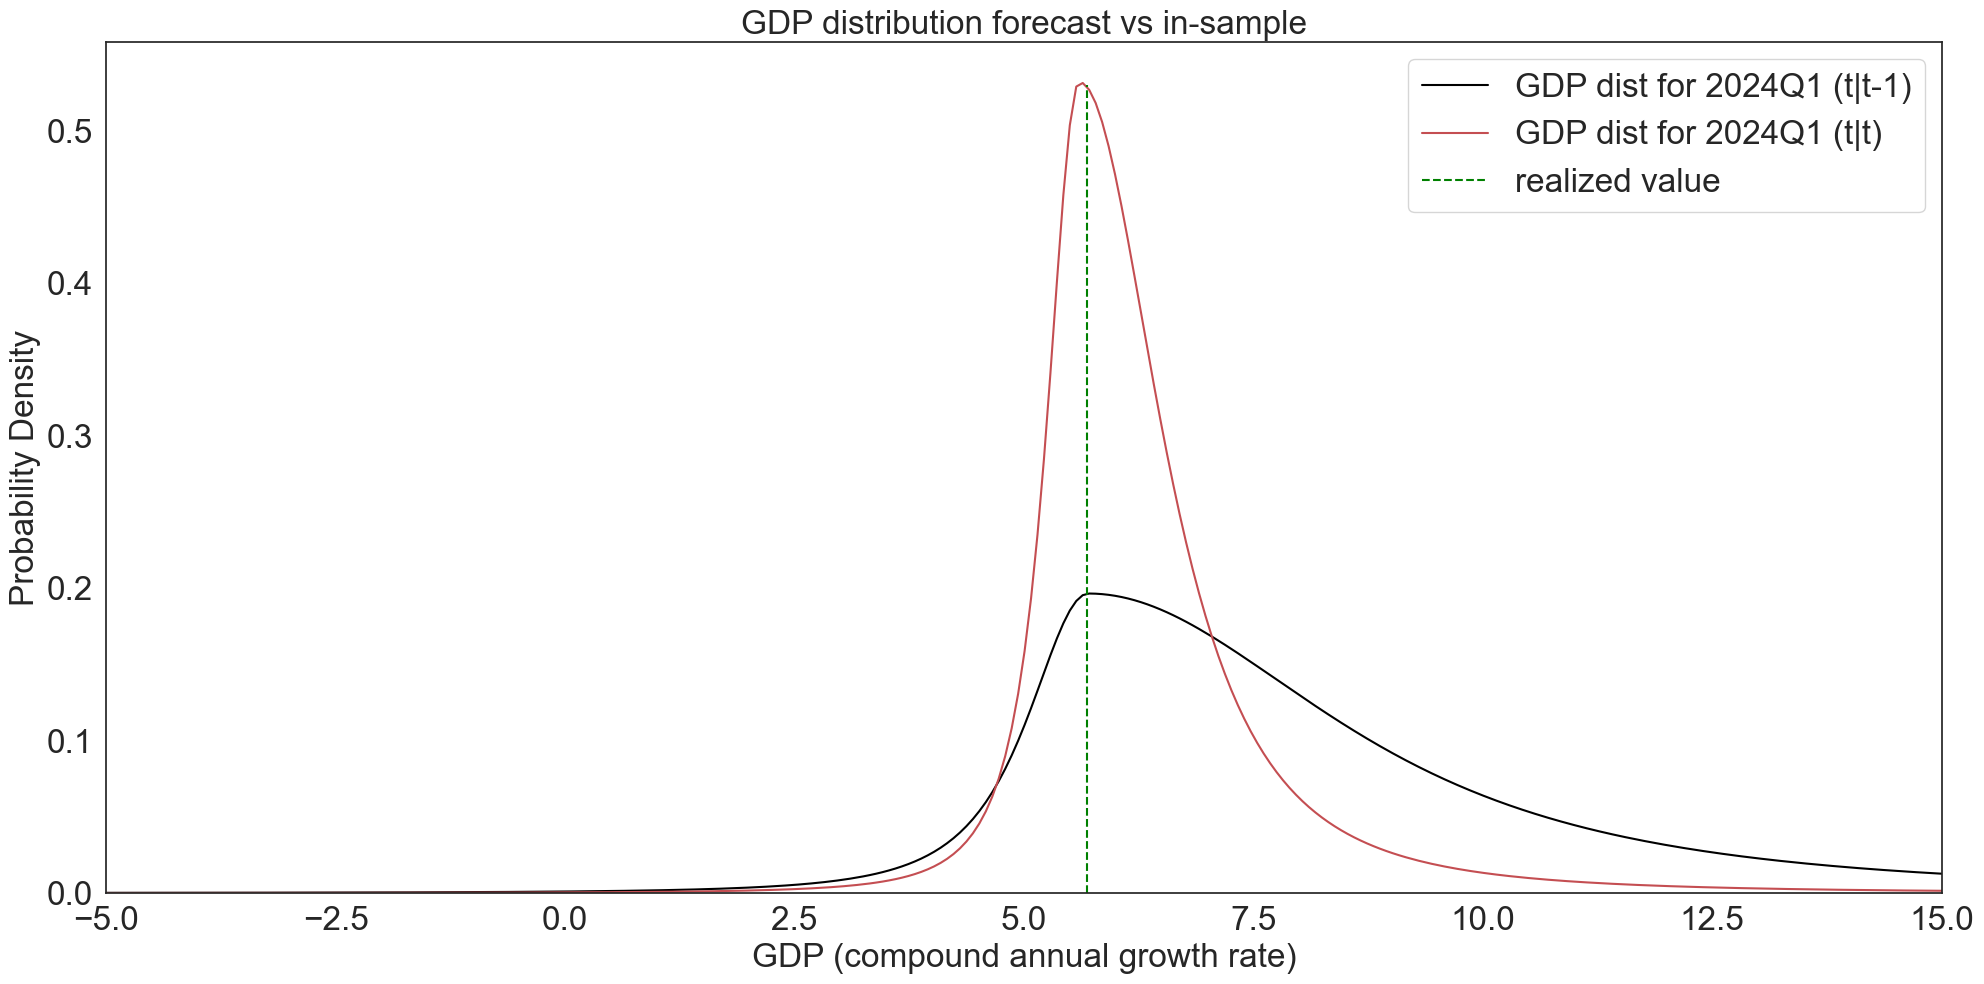

In [46]:
expectation = 'forward'
horizon = 4
plot_date_today = parser.parse('2023-03-31')
plot_date_tomorrow = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock_passive = 0
actual_today = prediction.loc['backward', 4, '2024-03-31', 'direct', 0, 'actual']

dist_index_today_f = ('forward', horizon, plot_date_today, method, policy_effect_type, mpi_shock_passive)
dist_index_today_b = ('backward', horizon, plot_date_tomorrow, method, policy_effect_type, mpi_shock_passive)

x_list_today_f, yvals_today_f, ycdf_today_f = prediction_dfpdf.loc[dist_index_today_f].values.T
x_list_today_b, yvals_today_b, ycdf_today_b = prediction_dfpdf.loc[dist_index_today_b].values.T

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = "GDP distribution forecast vs in-sample"
lablestr_today_f = "GDP dist for 2024Q1 (t|t-1)"
lablestr_today_b = "GDP dist for 2024Q1 (t|t)"

ax.plot(x_list_today_f, yvals_today_f, 'black', label=lablestr_today_f)
ax.plot(x_list_today_b, yvals_today_b, 'r-', label=lablestr_today_b)
ax.axvline(x=actual_today, ymax=0.95, color='green', linestyle='--', label='realized value')

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(-5, 15)
ax.set_ylim(0, max(max(yvals_today_f), max(yvals_today_b))*1.05)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)
plt.tight_layout()
plt.savefig('../results/arm_dist_insample_vs_forecast_2024Q1.png', bbox_inches='tight', dpi=300)
plt.show()

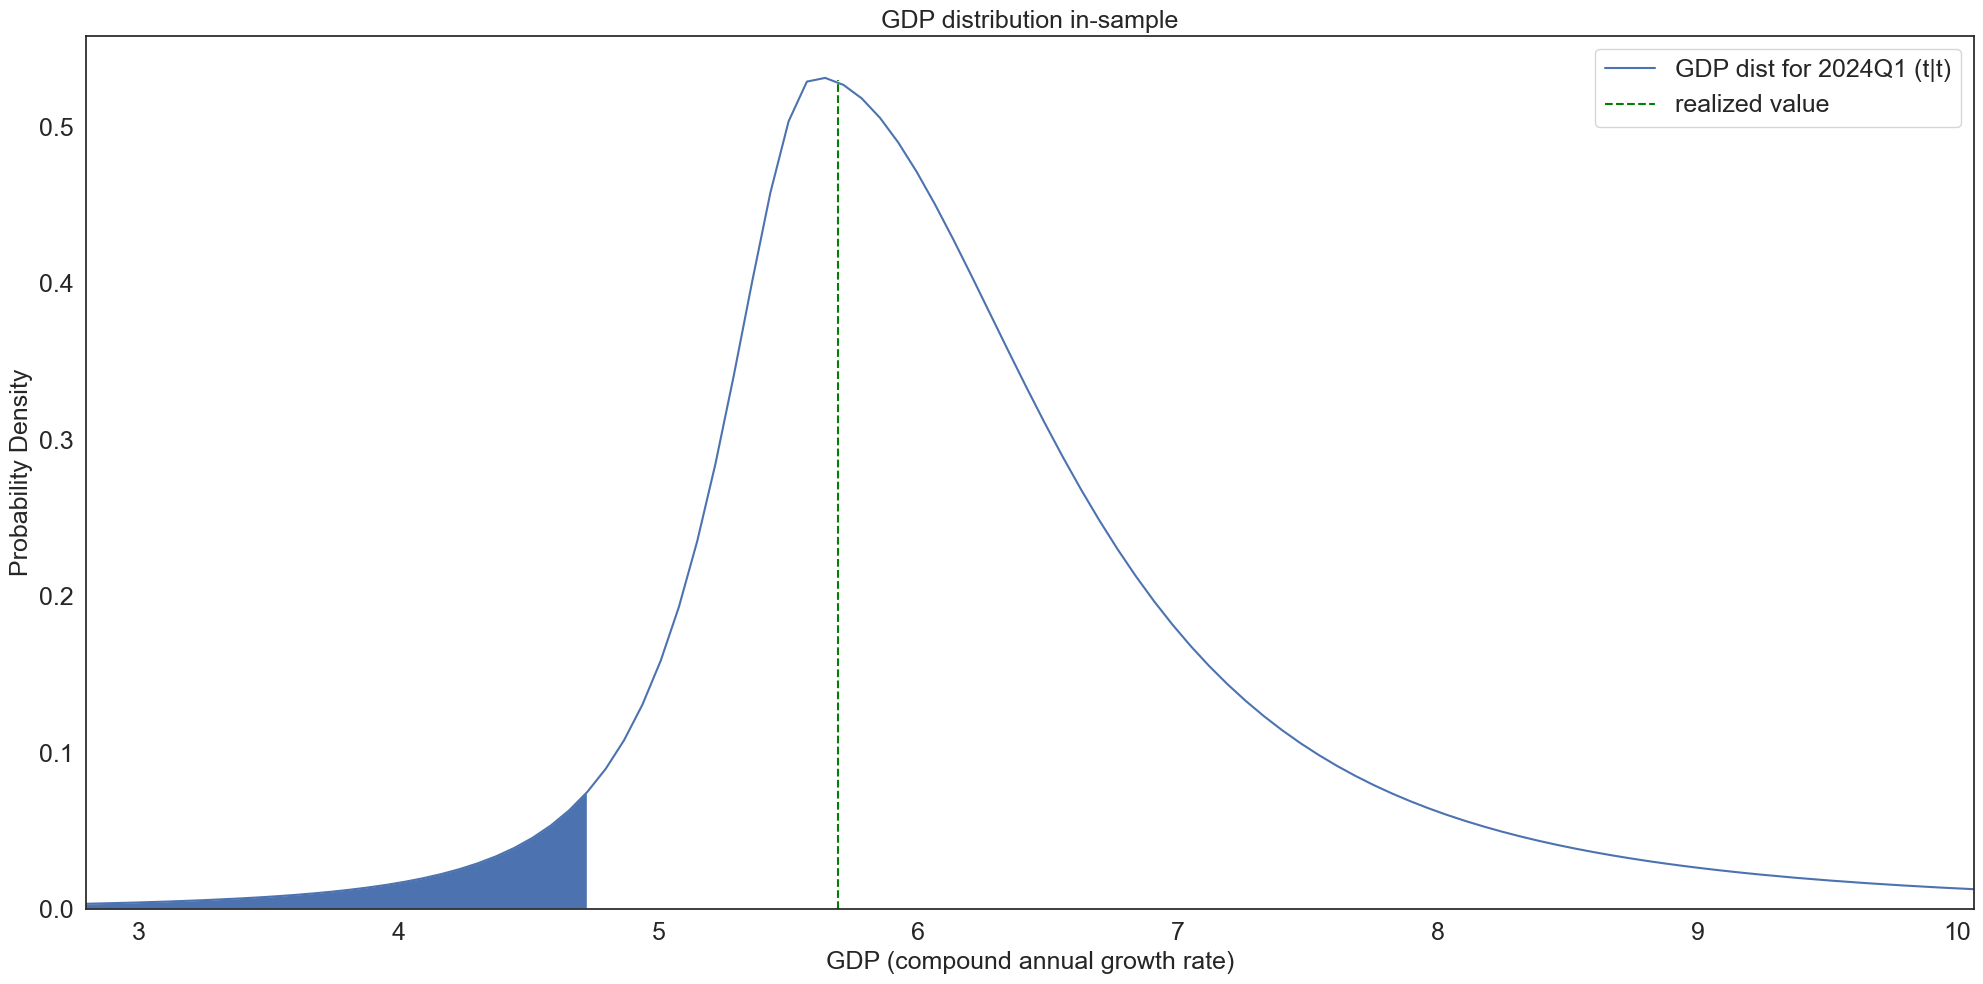

In [47]:
expectation = 'backward'
horizon = 4
plot_date = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock = 0
dist_index = (expectation, horizon, plot_date, method, policy_effect_type, mpi_shock)
actual_today = prediction.loc['backward', 4, '2024-03-31', 'direct', 0, 'actual']

x_list, yvals, ycdf = prediction_dfpdf.loc[dist_index].values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q50_index = np.argmin(np.abs(ycdf - 0.5))
x_tail = x_list[q5_index]
x_front = x_list[q50_index]

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = "GDP distribution in-sample"
lablestr_today_b = "GDP dist for 2024Q1 (t|t)"

ax.plot(x_list[q5_index-40:], yvals[q5_index-40:], 'b-', label=lablestr_today_b)
ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='b', interpolate=True)
ax.axvline(x=actual_today, ymax=0.95, color='green', linestyle='--', label='realized value')

# plot design
ax.set_title(titlestr, fontsize=18)
ax.legend(fontsize=18)
ax.tick_params(labelsize=18)
ax.set_xlim(x_tail-2, x_front+4)
ax.set_ylim(0, max(yvals)*1.05)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=18)
plt.tight_layout()
plt.savefig('../results/arm_dist_insample_2024Q1.png', bbox_inches='tight', dpi=300)
plt.show()

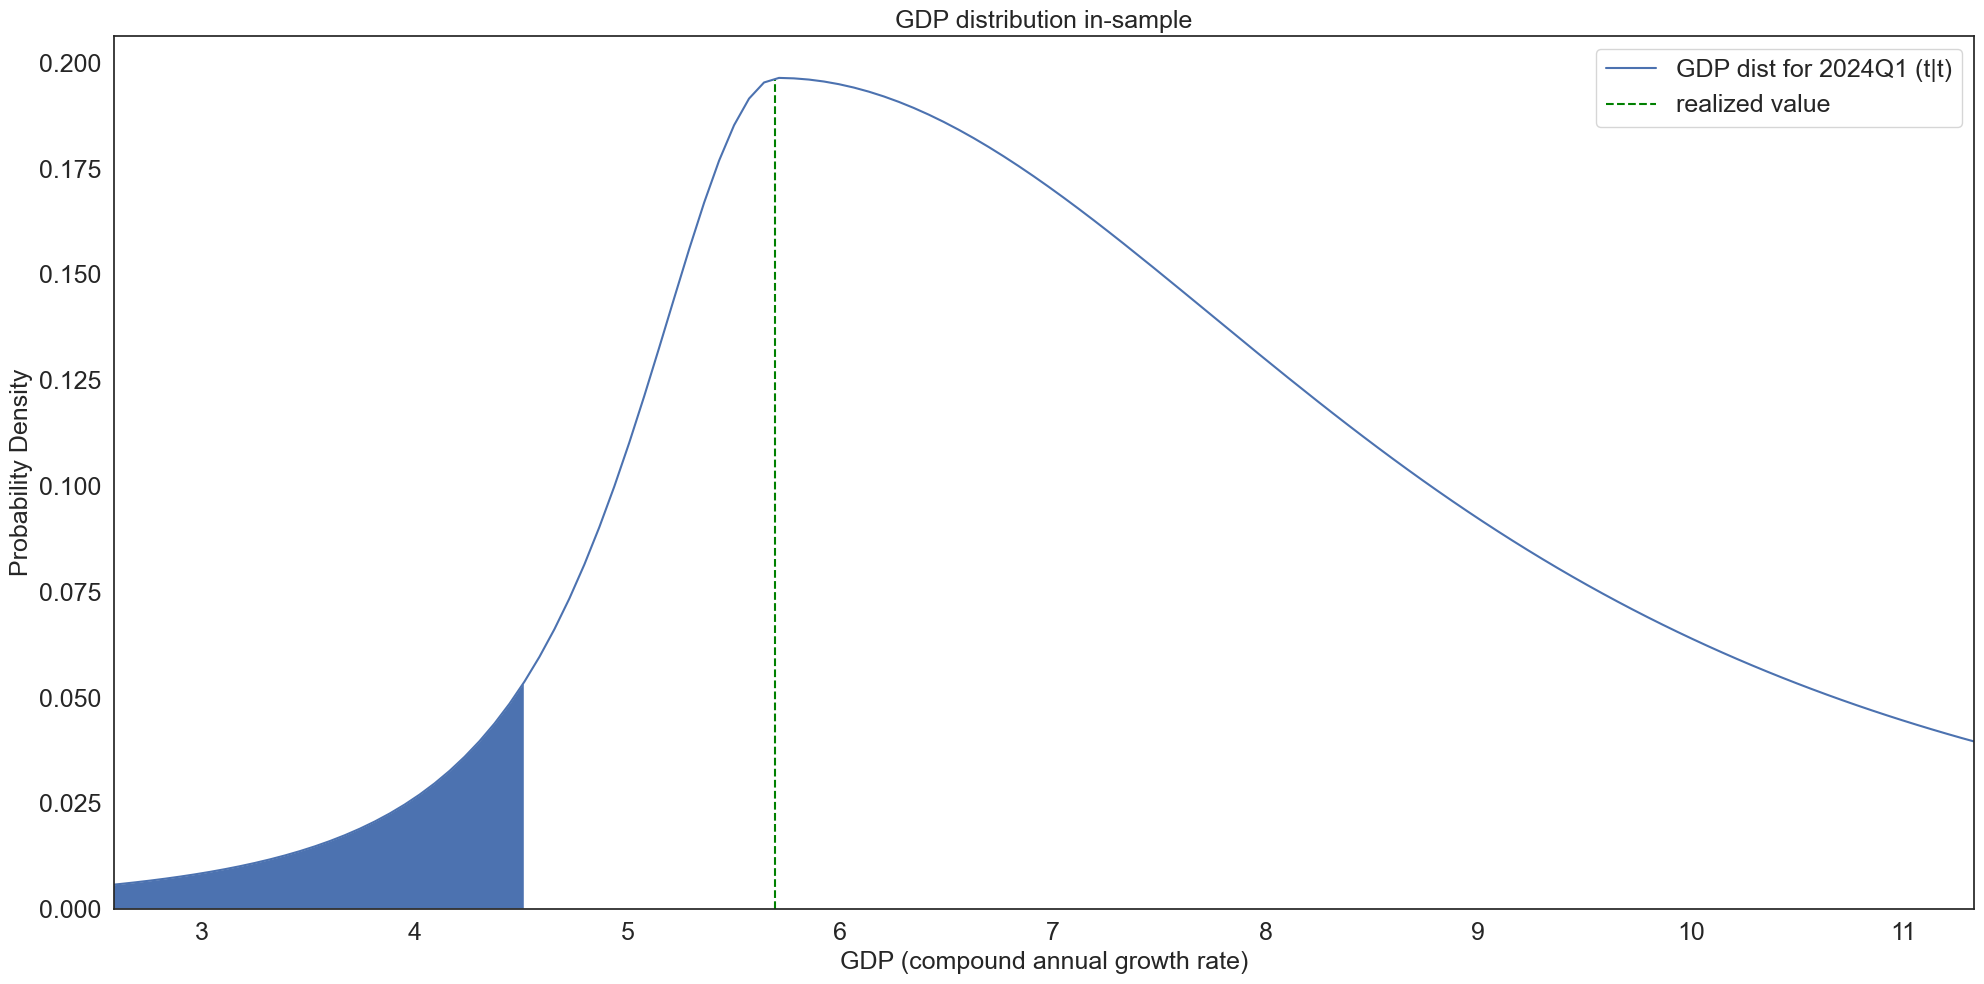

In [48]:
expectation = 'forward'
horizon = 4
plot_date = parser.parse('2023-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock = 0
dist_index = (expectation, horizon, plot_date, method, policy_effect_type, mpi_shock)
actual_today = prediction.loc['backward', 4, '2024-03-31', 'direct', 0, 'actual']

x_list, yvals, ycdf = prediction_dfpdf.loc[dist_index].values.T
q5_index = np.argmin(np.abs(ycdf - 0.05))
q50_index = np.argmin(np.abs(ycdf - 0.5))
x_tail = x_list[q5_index]
x_front = x_list[q50_index]

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = "GDP distribution in-sample"
lablestr_today_b = "GDP dist for 2024Q1 (t|t)"

ax.plot(x_list[q5_index-40:], yvals[q5_index-40:], 'b-', label=lablestr_today_b)
ax.fill_between(x_list[:q5_index], 0, yvals[:q5_index],  facecolor='b', interpolate=True)
ax.axvline(x=actual_today, ymax=0.95, color='green', linestyle='--', label='realized value')

# plot design
ax.set_title(titlestr, fontsize=18)
ax.legend(fontsize=18)
ax.tick_params(labelsize=18)
ax.set_xlim(x_tail-2, x_front+4)
ax.set_ylim(0, max(yvals)*1.05)
ax.set_ylabel('Probability Density', fontsize=18)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=18)
plt.tight_layout()
plt.savefig('../results/arm_dist_forecast_2024Q1.png', bbox_inches='tight', dpi=300)
plt.show()

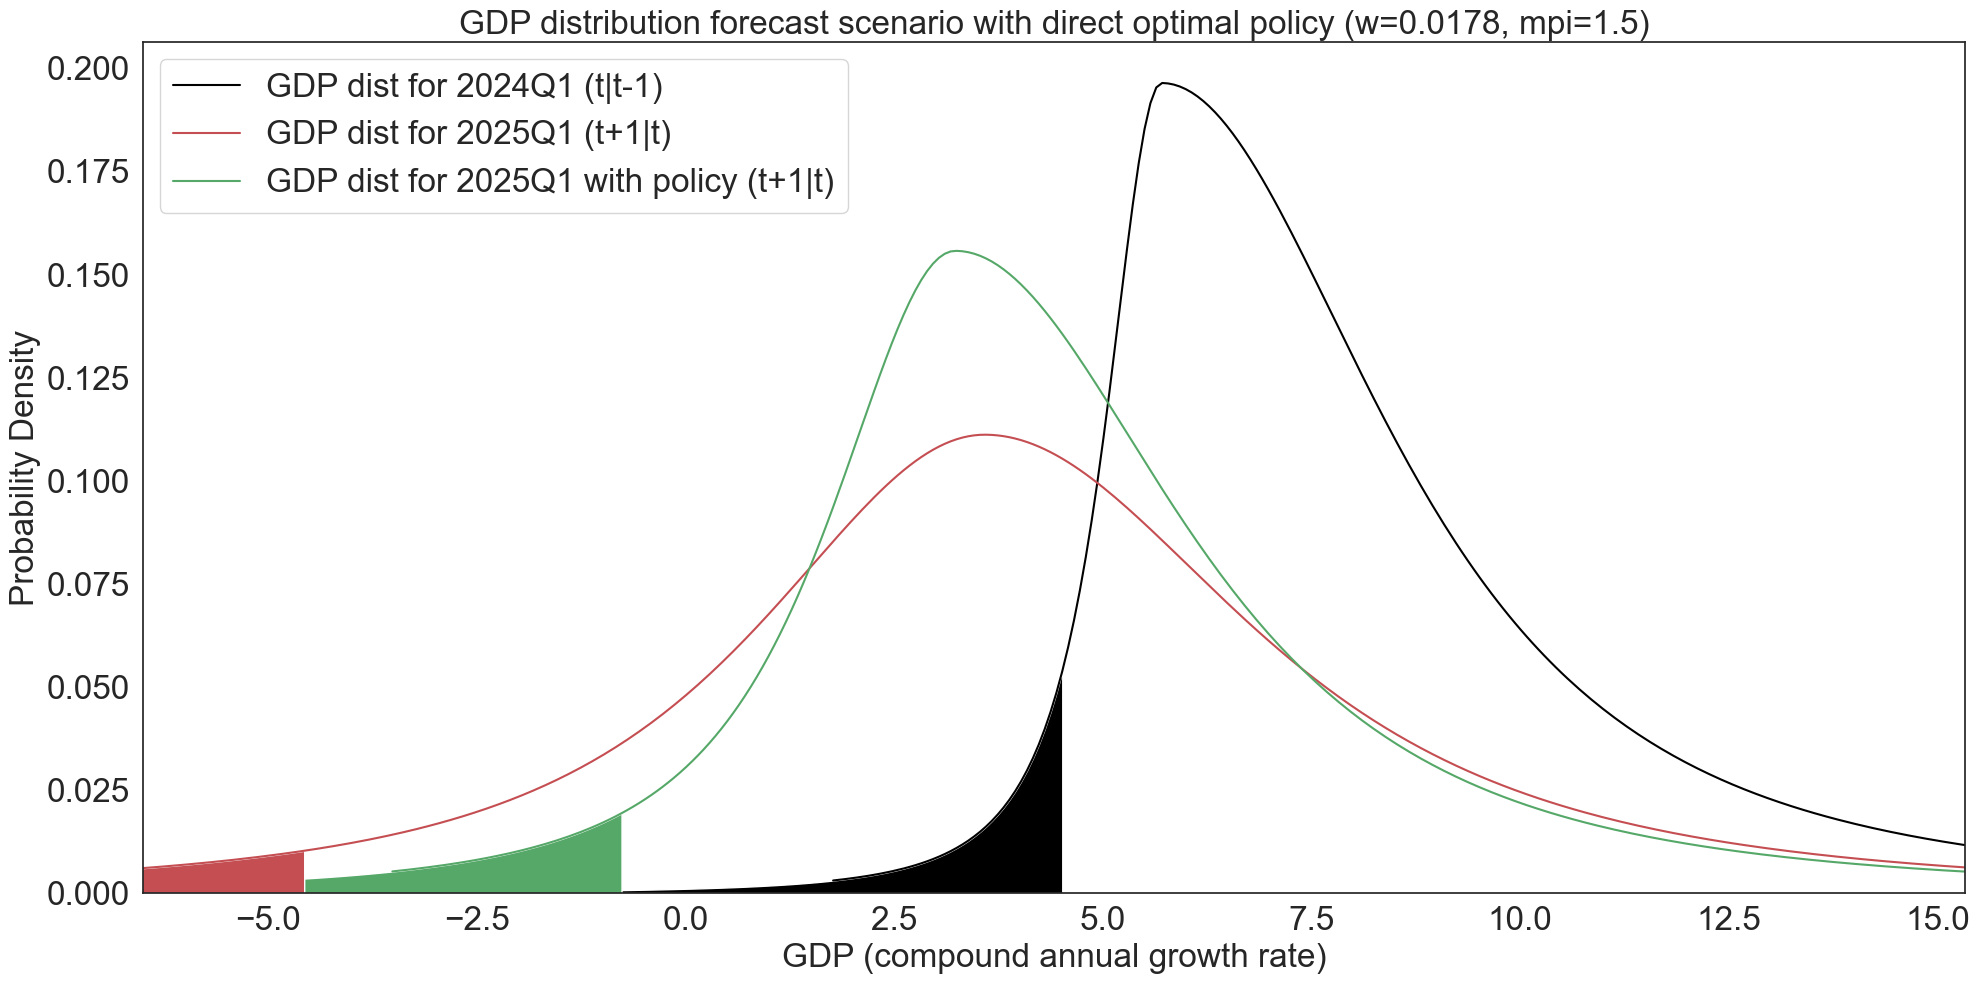

In [48]:
expectation = 'forward'
horizon = 4
plot_date_today = parser.parse('2023-03-31')
plot_date_tomorrow = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'direct'
mpi_shock_passive = 0

# estimating optimal policy given our forecast and weight
w_fixed = suarez_weights[2]
optimal_policy = mpi_choice_today.loc[policy_effect_type, w_fixed]

dist_index_today = (expectation, horizon, plot_date_today, method, policy_effect_type, mpi_shock_passive)
dist_index_tomorrow = (expectation, horizon, plot_date_tomorrow, method, policy_effect_type, mpi_shock_passive)
dist_index_tomorrow_policy = (expectation, horizon, plot_date_tomorrow, method, policy_effect_type, optimal_policy)

x_list_today, yvals_today, ycdf_today = prediction_dfpdf.loc[dist_index_today].values.T
x_list_tomorrow, yvals_tomorrow, ycdf_tomorrow = prediction_dfpdf.loc[dist_index_tomorrow].values.T
x_list_tp, yvals_tp, ycdf_tp = prediction_dfpdf.loc[dist_index_tomorrow_policy].values.T

q5_index_today = np.argmin(np.abs(ycdf_today - 0.05))
q5_index_tomorrow = np.argmin(np.abs(ycdf_tomorrow - 0.05))
q5_index_tp = np.argmin(np.abs(ycdf_tp - 0.05))
q50_index_today = np.argmin(np.abs(ycdf_today - 0.5))
q50_index_tomorrow = np.argmin(np.abs(ycdf_tomorrow - 0.5))
q50_index_tp = np.argmin(np.abs(ycdf_tp - 0.5))
x_tail = np.min([x_list_today[q5_index_today], x_list_today[q5_index_tomorrow], x_list_today[q5_index_tp]])
x_front = np.max([x_list_today[q50_index_today], x_list_today[q50_index_tomorrow], x_list_today[q50_index_tp]])

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = f"GDP distribution forecast scenario with direct optimal policy (w={w_fixed}, mpi={optimal_policy})"
lablestr_today = "GDP dist for 2024Q1 (t|t-1)"
lablestr_tomorrow = "GDP dist for 2025Q1 (t+1|t)"
lablestr_tp = "GDP dist for 2025Q1 with policy (t+1|t)"

ax.plot(x_list_today[q5_index_today-40:], yvals_today[q5_index_today-40:], 'black', label=lablestr_today)
ax.plot(x_list_today[q5_index_tomorrow-40:], yvals_tomorrow[q5_index_tomorrow-40:], 'r-', label=lablestr_tomorrow)
ax.plot(x_list_today[q5_index_tp-40:], yvals_tp[q5_index_tp-40:], 'g-', label=lablestr_tp)

if yvals_today[q5_index_today] > yvals_tomorrow[q5_index_tomorrow]:
    ax.fill_between(x_list_today[:q5_index_today], 0, yvals_today[:q5_index_today],  facecolor='black', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tp], 0, yvals_tp[:q5_index_tp],  facecolor='g', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tomorrow], 0, yvals_tomorrow[:q5_index_tomorrow],  facecolor='r', interpolate=True)
else:
    ax.fill_between(x_list_today[:q5_index_tomorrow], 0, yvals_tomorrow[:q5_index_tomorrow],  facecolor='r', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tp], 0, yvals_tp[:q5_index_tp],  facecolor='g', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_today], 0, yvals_today[:q5_index_today],  facecolor='black', interpolate=True)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(x_tail-2, x_front+8)
ax.set_ylim(0, max(max(yvals_today), max(yvals_tomorrow), max(yvals_tp))*1.05)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)
plt.tight_layout()
plt.savefig('../results/arm_dist_optimal_policy_direct.png', bbox_inches='tight', dpi=300)
plt.show()

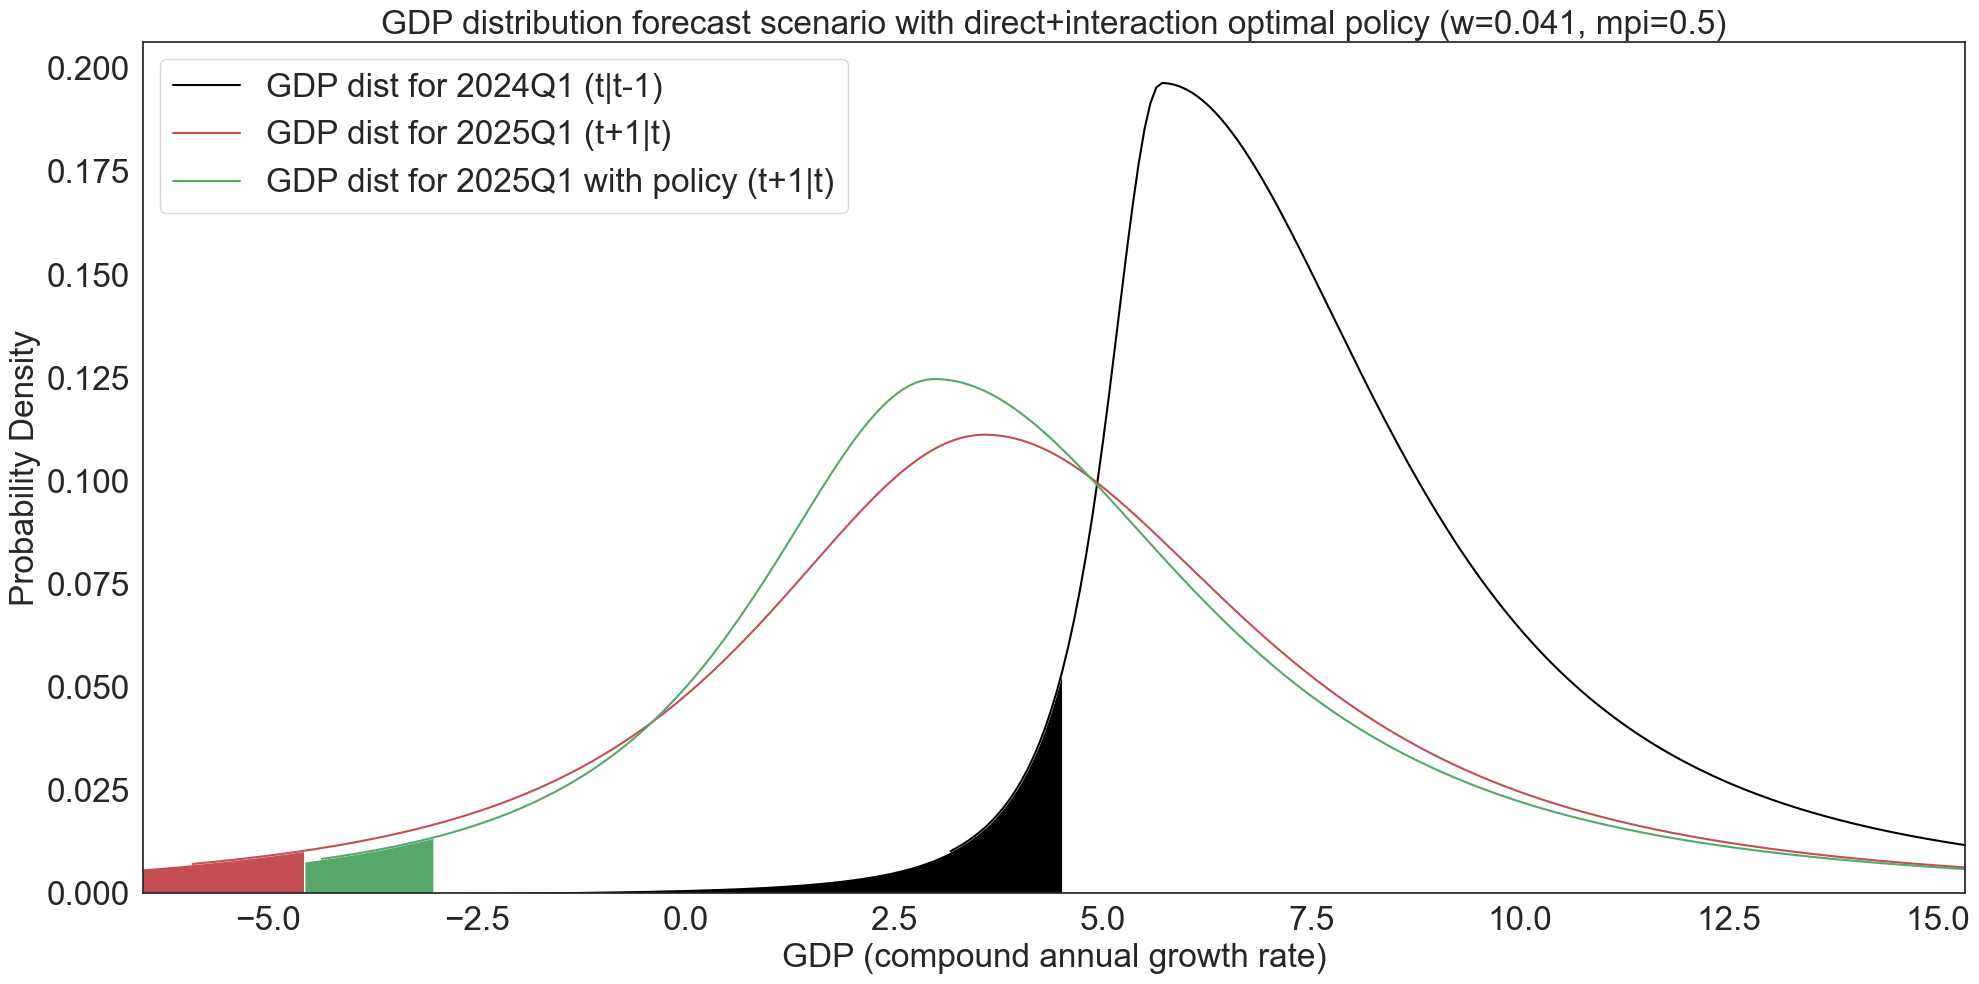

In [49]:
expectation = 'forward'
horizon = 4
plot_date_today = parser.parse('2023-03-31')
plot_date_tomorrow = parser.parse('2024-03-31')
method = 'T-skew'
policy_effect_type = 'interaction'
mpi_shock_passive = 0

# estimating optimal policy given our forecast and weight
w_fixed = suarez_weights[8]
optimal_policy = mpi_choice_today.loc[policy_effect_type, w_fixed]

dist_index_today = (expectation, horizon, plot_date_today, method, policy_effect_type, mpi_shock_passive)
dist_index_tomorrow = (expectation, horizon, plot_date_tomorrow, method, policy_effect_type, mpi_shock_passive)
dist_index_tomorrow_policy = (expectation, horizon, plot_date_tomorrow, method, policy_effect_type, optimal_policy)

x_list_today, yvals_today, ycdf_today = prediction_dfpdf.loc[dist_index_today].values.T
x_list_tomorrow, yvals_tomorrow, ycdf_tomorrow = prediction_dfpdf.loc[dist_index_tomorrow].values.T
x_list_tp, yvals_tp, ycdf_tp = prediction_dfpdf.loc[dist_index_tomorrow_policy].values.T

q5_index_today = np.argmin(np.abs(ycdf_today - 0.05))
q5_index_tomorrow = np.argmin(np.abs(ycdf_tomorrow - 0.05))
q5_index_tp = np.argmin(np.abs(ycdf_tp - 0.05))
q50_index_today = np.argmin(np.abs(ycdf_today - 0.5))
q50_index_tomorrow = np.argmin(np.abs(ycdf_tomorrow - 0.5))
q50_index_tp = np.argmin(np.abs(ycdf_tp - 0.5))
x_tail = np.min([x_list_today[q5_index_today], x_list_today[q5_index_tomorrow], x_list_today[q5_index_tp]])
x_front = np.max([x_list_today[q50_index_today], x_list_today[q50_index_tomorrow], x_list_today[q50_index_tp]])

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
titlestr = f"GDP distribution forecast scenario with direct+interaction optimal policy (w={w_fixed}, mpi={optimal_policy})"
lablestr_today = "GDP dist for 2024Q1 (t|t-1)"
lablestr_tomorrow = "GDP dist for 2025Q1 (t+1|t)"
lablestr_tp = "GDP dist for 2025Q1 with policy (t+1|t)"

ax.plot(x_list_today[q5_index_today-20:], yvals_today[q5_index_today-20:], 'black', label=lablestr_today)
ax.plot(x_list_today[q5_index_tomorrow-20:], yvals_tomorrow[q5_index_tomorrow-20:], 'r-', label=lablestr_tomorrow)
ax.plot(x_list_today[q5_index_tp-20:], yvals_tp[q5_index_tp-20:], 'g-', label=lablestr_tp)

if yvals_today[q5_index_today] > yvals_tomorrow[q5_index_tomorrow]:
    ax.fill_between(x_list_today[:q5_index_today], 0, yvals_today[:q5_index_today],  facecolor='black', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tp], 0, yvals_tp[:q5_index_tp],  facecolor='g', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tomorrow], 0, yvals_tomorrow[:q5_index_tomorrow],  facecolor='r', interpolate=True)
else:
    ax.fill_between(x_list_today[:q5_index_tomorrow], 0, yvals_tomorrow[:q5_index_tomorrow],  facecolor='r', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_tp], 0, yvals_tp[:q5_index_tp],  facecolor='g', interpolate=True)
    ax.fill_between(x_list_today[:q5_index_today], 0, yvals_today[:q5_index_today],  facecolor='black', interpolate=True)

# plot design
ax.set_title(titlestr, fontsize=24)
ax.legend(fontsize=24)
ax.tick_params(labelsize=24)
ax.set_xlim(x_tail-2, x_front+8)
ax.set_ylim(0, max(max(yvals_today), max(yvals_tomorrow), max(yvals_tp))*1.05)
ax.set_ylabel('Probability Density', fontsize=24)
ax.set_xlabel('GDP (compound annual growth rate)', fontsize=24)
plt.tight_layout()
plt.savefig('../results/arm_dist_optimal_policy_interaction.png', bbox_inches='tight', dpi=300)
plt.show()

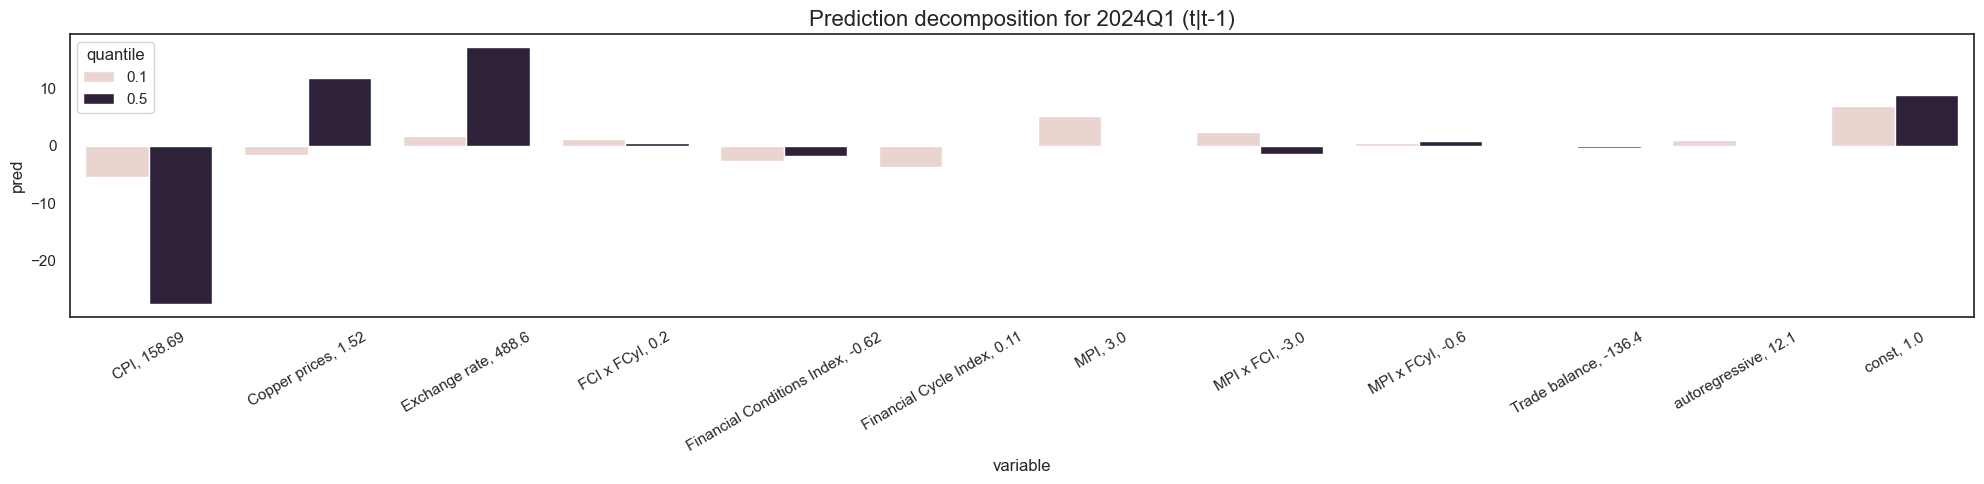

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
titlestr = "Prediction decomposition for 2024Q1 (t|t-1)"
plot_data = variable_effects_old.loc['forward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_2024Q1(t|t-1).png', bbox_inches='tight', dpi=300)
plt.show()

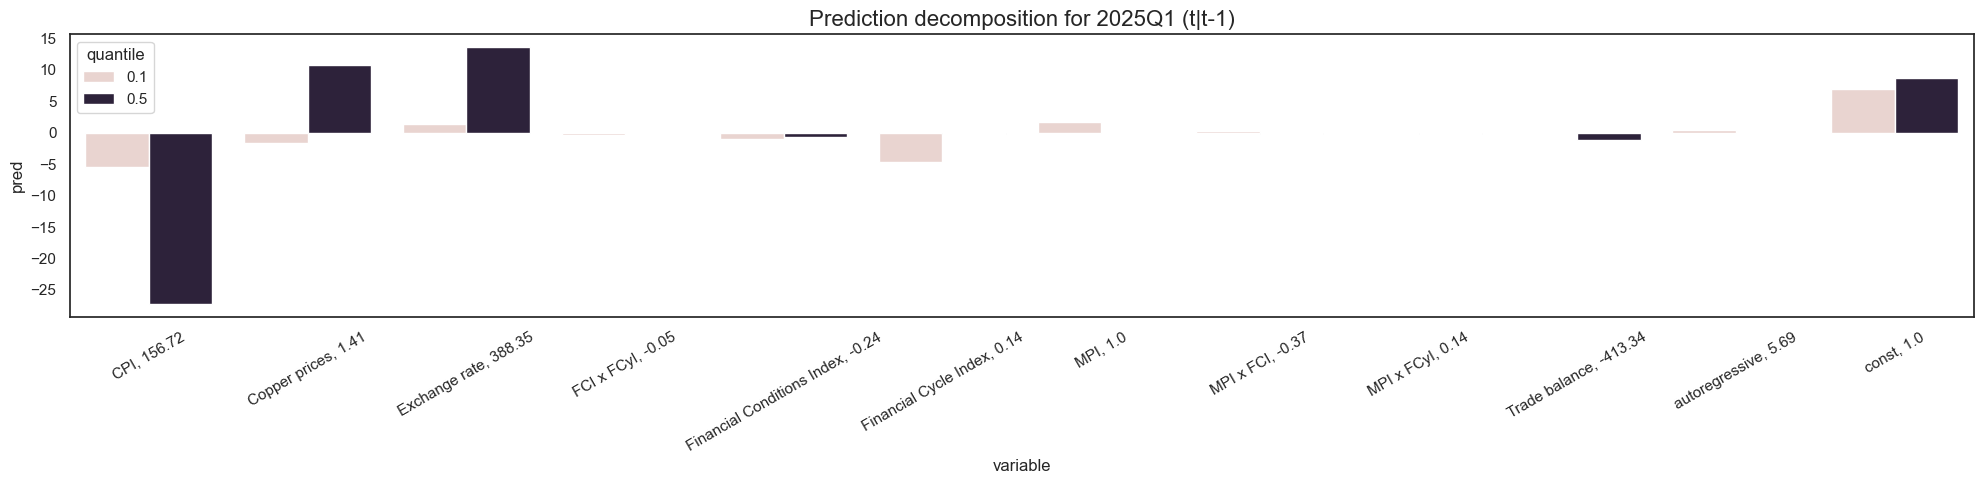

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
titlestr = "Prediction decomposition for 2025Q1 (t|t-1)"
plot_data = variable_effects_today.loc['forward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_2025Q1(t|t-1).png', bbox_inches='tight', dpi=300)
plt.show()

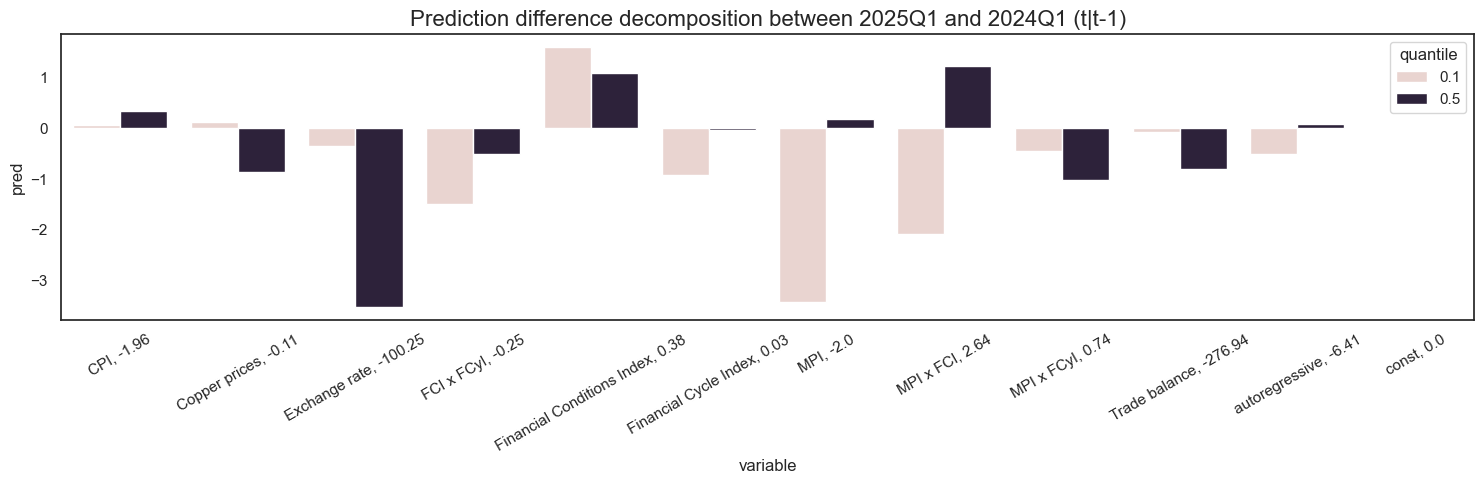

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
titlestr = "Prediction difference decomposition between 2025Q1 and 2024Q1 (t|t-1)"
plot_data = variable_effects_diff.loc['forward', 4].loc[[0.1, 0.5]]
exog_values = plot_data.loc[0.1, 'exog'].values.round(2)
var_values = plot_data.loc[0.1].index.get_level_values('variable')
x_values = {n: f"{n}, {v}" for n, v in zip(var_values, exog_values)}
plot_data = plot_data.reset_index()
plot_data['variable'] = plot_data['variable'].replace(x_values)
ax.set_title(titlestr, fontsize=16)
sns.barplot(plot_data, x="variable", y="pred", hue='quantile', order=x_values.values(), errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_diff_2025Q1(t|t-1).png', bbox_inches='tight', dpi=300)
plt.show()

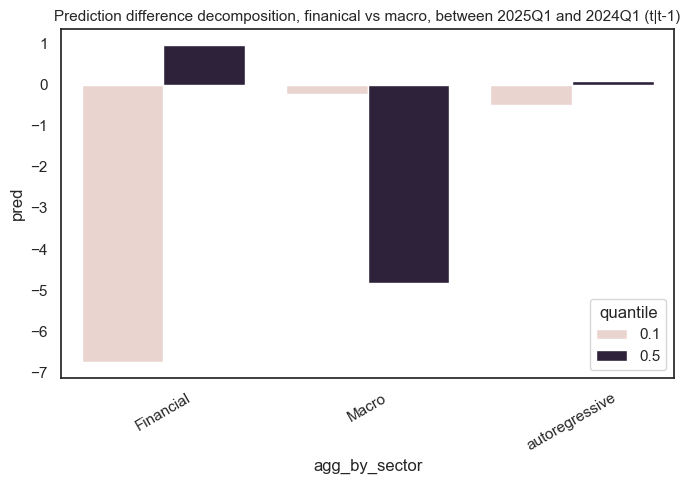

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
titlestr = "Prediction difference decomposition, finanical vs macro, between 2025Q1 and 2024Q1 (t|t-1)"
plot_data = variable_effects_diff_agg.loc['forward', 4].loc[[0.1, 0.5]].copy()
plot_data = plot_data.reset_index()
ax.set_title(titlestr, fontsize=11)
sns.barplot(plot_data, x="agg_by_sector", y="pred", hue='quantile', errorbar=None, ax=ax)
for item in ax.get_xticklabels():
    item.set_rotation(30)
plt.tight_layout()
plt.savefig('../results/arm_dist_decomp_diff_agg_2025Q1(t|t-1).png', bbox_inches='tight', dpi=300)
plt.show()